# Furrow indentation and invagination

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, scipy, skimage, os
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,

    'svg.fonttype':'none',
    'pdf.fonttype': 42,

    'axes.linewidth': 0.5,

    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,

    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.major.pad': 1,
    'ytick.major.pad': 1,

    'axes.labelpad': 1
})

In [2]:
# speed calculator
def speed_calculator(time, movement, time_interval = 1, pixel_size = 1, method = 'displacement'):
    if method == 'linreg':
        res = scipy.stats.linregress(time, movement)
        speed = res.slope*pixel_size/time_interval
    elif method == 'displacement':
        speed = (movement[-1] - movement[0]) / (time[-1] - time[0])
    return speed


def swarmplot_pair_lines(swarmplot_axes, ax, color = 'black', alpha=0.5, ls='--', lw=0.5, **kwargs):
    colls = swarmplot_axes.collections

    colls_points = []
    for coll in colls:
        a = coll.get_offsets()
        colls_points.append(a)

    colls_points = np.array(colls_points)
    colls_points = np.swapaxes(colls_points, 0,1)
    for i in range(colls_points.shape[0]):
        ax.plot(colls_points[i, :, 0], colls_points[i, :, 1], zorder=-100, color=color, alpha=alpha, ls=ls, lw=lw, **kwargs)


# Write a function to create new folder
def create_folder(path):
    isExist = os.path.exists(path) 
    if not isExist:
        os.makedirs(path)


def fit_circle(points):
    from scipy.optimize import leastsq
    # Compute the initial guess for the center
    x_m, y_m = np.mean(points, axis=0)
    
    def calc_R(xc, yc):
        """Calculate distance of each point from the center (xc, yc)."""
        return np.sqrt((points[:, 0] - xc)**2 + (points[:, 1] - yc)**2)
    
    def f_2(c):
        """Calculate algebraic distance between data points and mean circle."""
        Ri = calc_R(*c)
        return Ri - Ri.mean()
    
    # Initial guess for the center
    center_estimate = (x_m, y_m)
    center, _ = leastsq(f_2, center_estimate)
    xc, yc = center
    
    # Compute the radius as the mean distance to the center
    R = calc_R(xc, yc)
    r = R.mean()
    
    return xc, yc, r

In [3]:
data_info = pd.read_excel('B:\\archive\\xtong\\xin home drive\\data_meroblastic\\majority_data_info.xlsx')
staging_cols = ["m1", "i2", "ck1", "pfa1", "m2", 'septum1', "i3"]
data_info = data_info[data_info['furrow_indentation'].isin(['wt', 'cafree', 'iaa', 'carhoa', 'wtdmso'])]
data_info[staging_cols] = data_info[staging_cols].apply(pd.to_numeric, errors="coerce").astype("Int64")

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Characterize cell cycle (developmental timing)

## Strategy 1: align with 2i and m2

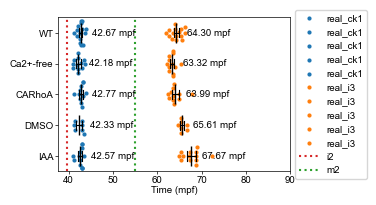

In [5]:
data_info['real_i2'] = 39.5
data_info['real_m2'] = 55

data_info['real_time_interval'] = (data_info['real_m2'] - data_info['real_i2']) / (data_info['m2'] - data_info['i2']) 

data_info['real_ck1'] = data_info['real_i2'] + data_info['real_time_interval'] * (data_info['ck1'] - data_info['i2'])
data_info['real_i3'] = data_info['real_i2'] + data_info['real_time_interval'] * (data_info['i3'] - data_info['i2'])

order = ['wt', 'cafree', 'carhoa', 'wtdmso', 'iaa']

fig, ax = plt.subplots(figsize=[3,2])
for i in ['real_ck1', 'real_i3']:
    sns.swarmplot(data = data_info, x = i, y ='furrow_indentation', order=['wt', 'cafree', 'carhoa', 'wtdmso', 'iaa'], ax=ax, zorder=1, s=3, label=i)
    
    mean_vals = data_info.groupby('furrow_indentation')[i].mean()
    for j, group in enumerate(order):
        ax.text(mean_vals[group] + 2.5, j, f"{mean_vals[group]:.2f} mpf", va="center", ha="left", color="black")

for i in ['real_ck1', 'real_i3']:
    sns.pointplot(data = data_info, x = i, y ='furrow_indentation', order=['wt', 'cafree', 'carhoa', 'wtdmso', 'iaa'], ax=ax,
                  orient = 'h', color='black',
                  estimator='mean', errorbar=('ci', 95), linestyle='none', marker='|', markersize=15, markeredgewidth=1, capsize=0.3, err_kws={'linewidth': 0.8}, zorder=2)
    # sns.boxplot(data = data_info, x = i, y ='furrow_indentation', order=['wt', 'cafree', 'carhoa', 'wtdmso', 'iaa'], ax=ax, zorder=1, width=0.3)

ax.axvline(x = 39.5, color='tab:red', ls=':', label='i2')
ax.axvline(x = 55, color='tab:green', ls=':', label='m2')

ax.set_yticklabels(['WT', 'Ca2+-free', 'CARhoA', 'DMSO', 'IAA'])
ax.set_ylabel('')
ax.set_xlabel('Time (mpf)')
ax.set_xlim(37.5, 90)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('dev_time_comparison.svg')


### stats test: real_ck1

In [6]:
df = data_info.copy()
from scipy import stats

groups = [df['real_ck1'].dropna().values for _, df in df.groupby('furrow_indentation')]

# 1. Normality (Shapiro-Wilk on each group)
p_norms = [stats.shapiro(g).pvalue for g in groups]
normal = all(p > 0.05 for p in p_norms)
print(f"Shapiro p-values: {[f'{p:.3f}' for p in p_norms]} → {'normal' if normal else 'not normal'}")

# 2. Equal variance (Levene)
_, p_var = stats.levene(*groups)
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal and equal_var:
    stat, p = stats.f_oneway(*groups)
    test_name = "One-way ANOVA"
elif normal and not equal_var:
    stat, p = stats.alexandergovern(*groups)  # Welch-style ANOVA for unequal variances
    test_name = "Alexander-Govern (Welch ANOVA)"
else:
    stat, p = stats.kruskal(*groups)
    test_name = "Kruskal-Wallis"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.4f}")

Shapiro p-values: ['0.454', '0.365', '0.003', '0.692', '0.042'] → not normal
Levene p-value: 0.722 → equal variance

Kruskal-Wallis: stat=3.371, p=0.4978


In [7]:
from itertools import combinations

group_names = [name for name, _ in df.groupby('furrow_indentation')]

# Post-hoc pairwise tests
rows = []
print("Using:", "t-test" if normal else "Mann-Whitney U")

for (n1, g1), (n2, g2) in combinations(zip(group_names, groups), 2):
    if normal:
        stat, p = stats.ttest_ind(g1, g2, equal_var=equal_var)
        test = "Student's t-test" if equal_var else "Welch's t-test"
    else:
        stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        test = "Mann-Whitney"
    rows.append({'group1': n1, 'group2': n2, 'stat': stat, 'p': p, 'test':test})

posthoc = pd.DataFrame(rows)

# Multiple testing correction (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
reject, p_corrected, _, _ = multipletests(posthoc['p'], method='fdr_bh')
posthoc['p_corrected'] = np.round(p_corrected, 4)
posthoc['significant'] = reject

print(posthoc)

Using: Mann-Whitney U
   group1  group2   stat         p          test  p_corrected  significant
0  cafree  carhoa   36.5  0.073288  Mann-Whitney       0.7212        False
1  cafree     iaa   55.0  0.216361  Mann-Whitney       0.7212        False
2  cafree      wt   61.0  0.162263  Mann-Whitney       0.7212        False
3  cafree  wtdmso   38.0  0.765575  Mann-Whitney       1.0000        False
4  carhoa     iaa   81.5  0.576183  Mann-Whitney       1.0000        False
5  carhoa      wt   92.5  0.619755  Mann-Whitney       1.0000        False
6  carhoa  wtdmso   45.0  0.584125  Mann-Whitney       1.0000        False
7     iaa      wt  100.0  0.925320  Mann-Whitney       1.0000        False
8     iaa  wtdmso   46.0  1.000000  Mann-Whitney       1.0000        False
9      wt  wtdmso   56.5  0.803489  Mann-Whitney       1.0000        False


In [8]:
# check individually
g1 = data_info.loc[data_info['furrow_indentation']=='wt', 'real_i3'].values
g2 = data_info.loc[data_info['furrow_indentation']=='cafree', 'real_i3'].values

scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(133.0), pvalue=np.float64(0.036781678548889876))

### stats test: real_i3

In [9]:
df = data_info.copy()

groups = [df['real_i3'].dropna().values for _, df in df.groupby('furrow_indentation')]

# 1. Normality (Shapiro-Wilk on each group)
p_norms = [stats.shapiro(g).pvalue for g in groups]
normal = all(p > 0.05 for p in p_norms)
print(f"Shapiro p-values: {[f'{p:.3f}' for p in p_norms]} → {'normal' if normal else 'not normal'}")

# 2. Equal variance (Levene)
_, p_var = stats.levene(*groups)
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal and equal_var:
    stat, p = stats.f_oneway(*groups)
    test_name = "One-way ANOVA"
elif normal and not equal_var:
    stat, p = stats.alexandergovern(*groups)  # Welch-style ANOVA for unequal variances
    test_name = "Alexander-Govern (Welch ANOVA)"
else:
    stat, p = stats.kruskal(*groups)
    test_name = "Kruskal-Wallis"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.4f}")

Shapiro p-values: ['0.071', '0.015', '0.158', '0.746', '0.036'] → not normal
Levene p-value: 0.052 → equal variance

Kruskal-Wallis: stat=32.672, p=0.0000


In [10]:
from itertools import combinations

group_names = [name for name, _ in df.groupby('furrow_indentation')]

# Post-hoc pairwise tests
rows = []
print("Using:", "t-test" if normal else "Mann-Whitney U")

for (n1, g1), (n2, g2) in combinations(zip(group_names, groups), 2):
    if normal:
        stat, p = stats.ttest_ind(g1, g2, equal_var=equal_var)
        test = "Student's t-test" if equal_var else "Welch's t-test"
    else:
        stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        test = "Mann-Whitney"
    rows.append({'group1': n1, 'group2': n2, 'stat': stat, 'p': p, 'test':test})

posthoc = pd.DataFrame(rows)

# Multiple testing correction (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
reject, p_corrected, _, _ = multipletests(posthoc['p'], method='fdr_bh')
posthoc['p_corrected'] = np.round(p_corrected, 4)
posthoc['significant'] = reject

print(posthoc)

Using: Mann-Whitney U
   group1  group2   stat         p          test  p_corrected  significant
0  cafree  carhoa   42.0  0.144768  Mann-Whitney       0.1609        False
1  cafree     iaa    2.0  0.000036  Mann-Whitney       0.0004         True
2  cafree      wt   47.0  0.036782  Mann-Whitney       0.0460         True
3  cafree  wtdmso    3.0  0.000950  Mann-Whitney       0.0024         True
4  carhoa     iaa    7.0  0.000200  Mann-Whitney       0.0007         True
5  carhoa      wt   62.5  0.310437  Mann-Whitney       0.3104        False
6  carhoa  wtdmso    9.0  0.008188  Mann-Whitney       0.0164         True
7     iaa      wt  180.0  0.000151  Mann-Whitney       0.0007         True
8     iaa  wtdmso   75.0  0.019296  Mann-Whitney       0.0322         True
9      wt  wtdmso   22.0  0.032484  Mann-Whitney       0.0460         True


In [11]:
# check individually
g1 = data_info.loc[data_info['furrow_indentation']=='wt', 'real_i3'].values
g2 = data_info.loc[data_info['furrow_indentation']=='cafree', 'real_i3'].values
print(scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided'))

g1 = data_info.loc[data_info['furrow_indentation']=='wt', 'real_i3'].values
g2 = data_info.loc[data_info['furrow_indentation']=='carhoa', 'real_i3'].values
print(scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided'))

g1 = data_info.loc[data_info['furrow_indentation']=='wtdmso', 'real_i3'].values
g2 = data_info.loc[data_info['furrow_indentation']=='iaa', 'real_i3'].values
print(scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided'))

MannwhitneyuResult(statistic=np.float64(133.0), pvalue=np.float64(0.036781678548889876))
MannwhitneyuResult(statistic=np.float64(102.5), pvalue=np.float64(0.3104371679284522))
MannwhitneyuResult(statistic=np.float64(16.0), pvalue=np.float64(0.019296286296527132))


## Strategy 2: align with m1/i2 and m2

furrow_indentation
cafree    63.284688
carhoa    64.303163
iaa        67.42218
wt        64.348358
wtdmso    65.406855
Name: real_i3, dtype: Float64

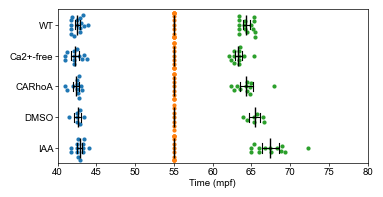

In [12]:
data_info.loc[data_info['m1'].notna(), 'real_m1'] = 30
data_info.loc[data_info['m1'].isna(), 'real_i2'] = 39.5
data_info.loc[:, 'real_m2'] = 55

data_info.loc[data_info['m1'].notna(), 'real_time_interval'] = (data_info.loc[data_info['m1'].notna(), 'real_m2'] - data_info.loc[data_info['m1'].notna(), 'real_m1'])/(data_info.loc[data_info['m1'].notna(), 'm2'] - data_info.loc[data_info['m1'].notna(), 'm1'])
data_info.loc[data_info['m1'].isna(), 'real_time_interval'] = (data_info.loc[data_info['m1'].isna(), 'real_m2'] - data_info.loc[data_info['m1'].isna(), 'real_i2'])/(data_info.loc[data_info['m1'].isna(), 'm2'] - data_info.loc[data_info['m1'].isna(), 'i2'])

data_info.loc[data_info['m1'].notna(), 'real_i2'] = data_info.loc[data_info['m1'].notna(), 'real_m1'] + data_info.loc[data_info['m1'].notna(), 'real_time_interval'] * (data_info.loc[data_info['m1'].notna(), 'i2'] - data_info.loc[data_info['m1'].notna(), 'm1'])
# data_info.loc[data_info['m1'].isna(), 'real_m1'] = 30


data_info['real_ck1'] = data_info['real_m2'] - data_info['real_time_interval'] * (data_info['m2'] - data_info['ck1'])
data_info['real_i3'] = data_info['real_m2'] - data_info['real_time_interval'] * (data_info['m2'] - data_info['i3'])

fig, ax = plt.subplots(figsize=[4,2])
# for i in ['real_m1', 'real_i2', 'real_ck1', 'real_m2', 'real_i3']:
for i in ['real_ck1', 'real_m2', 'real_i3']:
    sns.swarmplot(data = data_info, x = i, y ='furrow_indentation', order=['wt', 'cafree', 'carhoa', 'wtdmso', 'iaa'], ax=ax, zorder=1, s=3)
    sns.pointplot(data = data_info, x = i, y ='furrow_indentation', order=['wt', 'cafree', 'carhoa', 'wtdmso', 'iaa'], ax=ax,
                  orient = 'h', color='black',
                  estimator='mean', errorbar=('ci', 95), linestyle='none', marker='|', markersize=15, markeredgewidth=1, capsize=0.3, err_kws={'linewidth': 0.8}, zorder=2)
    # sns.boxplot(data = data_info, x = i, y ='furrow_indentation', order=['wt', 'cafree', 'carhoa', 'wtdmso', 'iaa'], ax=ax, zorder=1, width=0.3)

ax.set_yticklabels(['WT', 'Ca2+-free', 'CARhoA', 'DMSO', 'IAA'])
ax.set_ylabel('')
ax.set_xlabel('Time (mpf)')

ax.set_xlim(40, 80)

display(data_info.groupby('furrow_indentation')['real_i3'].mean())

In [13]:
# in conclusion
real_ck1 = 42.5
real_septum1 = 57
real_i3 = 64

# Wild-type

##### process the raw data

In [14]:
wt_replicates_info = data_info[data_info['furrow_indentation']=='wt'].reset_index()
display(wt_replicates_info)

,index,rep,experiment,replicate,embryo,type,Unnamed: 5,time_interval,pixel_size,voxel_depth,...,cortical_actin_intensity_quanti1,cortical_actin_intensity_quanti2,geometry,astral_mt_growth,real_i2,real_m2,real_time_interval,real_ck1,real_i3,real_m1
0,0,1,furrow_indentation_and_invagination,wt\XIN210821_LSM9001_DCLKegfp_UtrmCherry__Anim...,e1,NaN,NaN,46.85,1.247900,3.0,...,14.0,48.0,yes,yes,39.166667,55,0.833333,41.666667,64.166667,30.0
1,1,2,furrow_indentation_and_invagination,wt\XIN210821_LSM9001_DCLKegfp_UtrmCherry__Anim...,e2,NaN,NaN,46.93,1.247900,3.0,...,16.0,50.0,yes,yes,38.620690,55,0.862069,42.068966,64.482759,30.0
2,2,3,furrow_indentation_and_invagination,wt\XIN210822_LSM9001_DCLKegfp_UtrmCherry__Anim...,e1,best ever,NaN,47.00,1.247900,3.0,...,18.0,52.0,yes,yes,39.482759,55,0.862069,42.931034,65.344828,30.0
3,3,4,furrow_indentation_and_invagination,wt\XIN210822_LSM9001_DCLKegfp_UtrmCherry__Anim...,e2,NaN,NaN,47.00,1.247900,3.0,...,19.0,54.0,yes,yes,40.937500,55,0.78125,42.5,65.15625,30.0
4,4,5,furrow_indentation_and_invagination,wt\XIN210727_LSM9001_DCLKegfp_UtrmCh__Animall_...,e1,NaN,NaN,89.55,1.247900,3.0,...,5.0,24.0,yes,yes,38.333333,55,1.666667,41.666667,63.333333,30.0
5,5,6,furrow_indentation_and_invagination,wt\XIN210727_LSM9001_DCLKegfp_UtrmCh__Animall_...,e2,NaN,NaN,89.53,1.247900,1.5,...,8.0,27.0,yes,yes,38.333333,55,1.666667,41.666667,63.333333,30.0
6,6,7,furrow_indentation_and_invagination,wt\XIN210510_LSM9001_LSM8002_DCLKegfp_UtrmCher...,e1,NaN,NaN,41.28,1.247900,3.0,...,16.0,60.0,yes,yes,39.756098,55,0.609756,43.414634,64.146341,30.0
7,7,8,furrow_indentation_and_invagination,wt\XIN210510_LSM9001_LSM8002_DCLKegfp_UtrmCher...,e2,NaN,NaN,44.86,1.247900,NaN,...,NaN,NaN,NaN,yes,39.677419,55,0.806452,42.903226,65.483871,30.0
8,8,9,furrow_indentation_and_invagination,wt\XIN210510_LSM9001_LSM8002_DCLKegfp_UtrmCher...,e3,NaN,NaN,50.38,1.247900,3.0,...,12.0,51.0,yes,yes,39.558824,55,0.735294,43.970588,65.294118,30.0
9,10,11,furrow_indentation_and_invagination,wt\XIN210511_LSM9001_DCLKegfp_UtrmCherry__Anim...,e1,NaN,NaN,69.46,0.623927,3.0,...,NaN,NaN,NaN,NaN,40.000000,55,1.0,43.0,64.0,30.0


rep 1


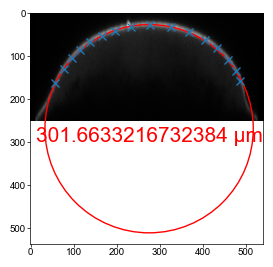

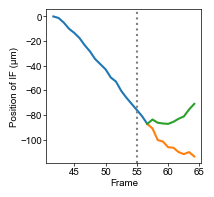

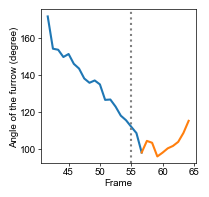

rep 2


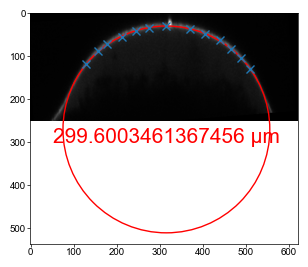

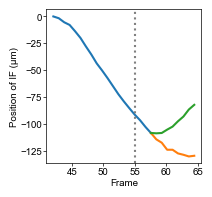

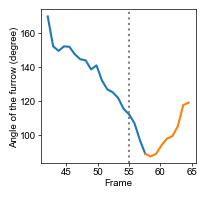

rep 3


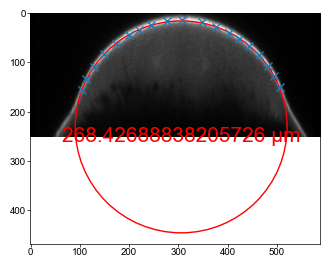

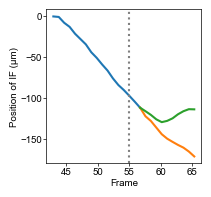

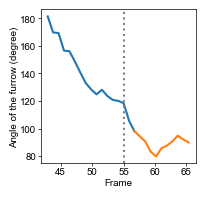

rep 4


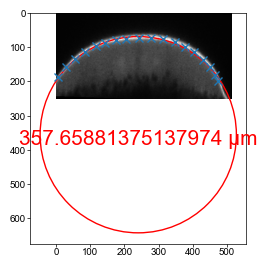

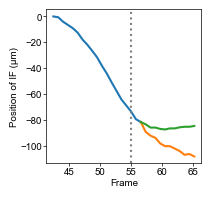

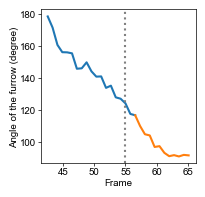

rep 5


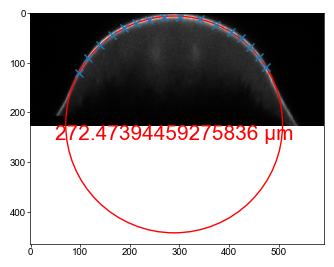

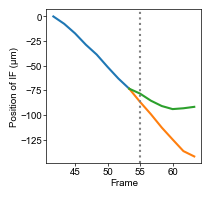

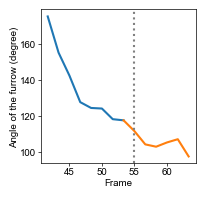

rep 6


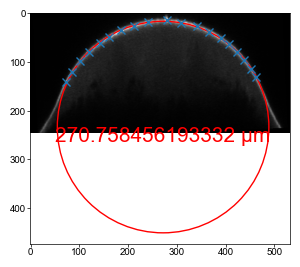

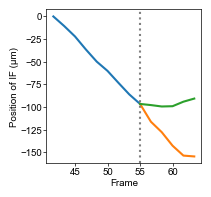

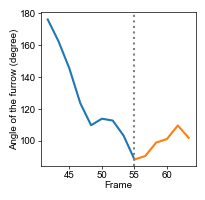

rep 7


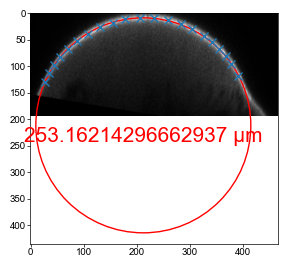

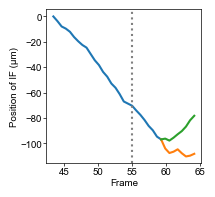

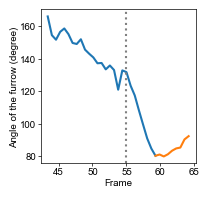

rep 8


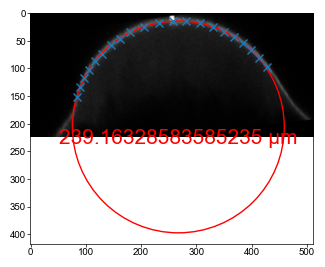

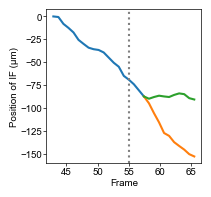

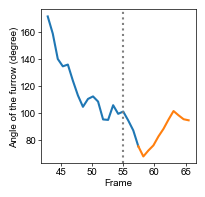

rep 9


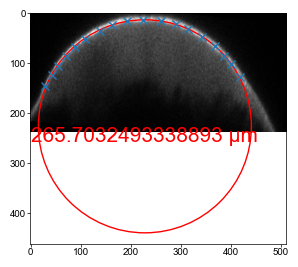

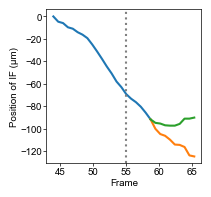

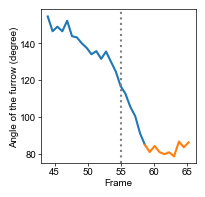

rep 11


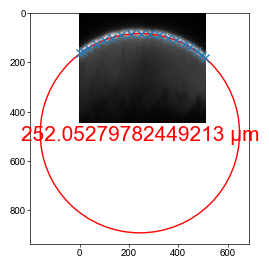

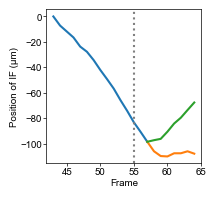

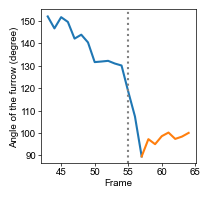

rep 12


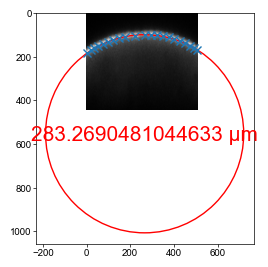

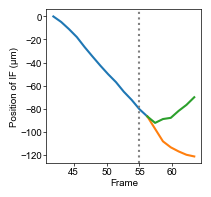

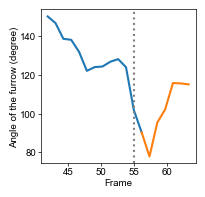

rep 26


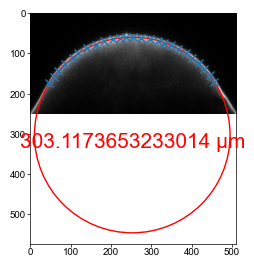

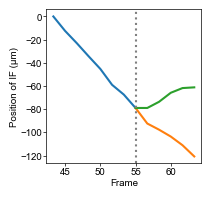

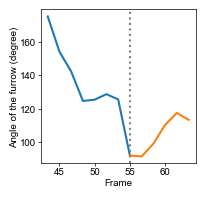

rep 27


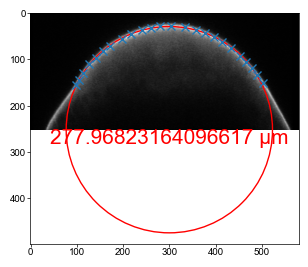

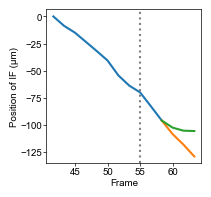

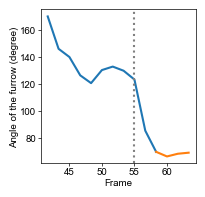

rep 36


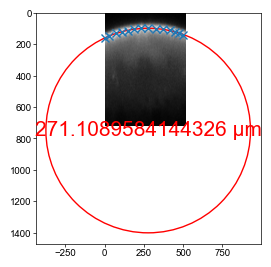

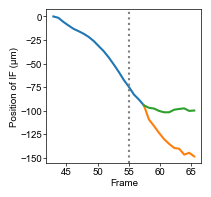

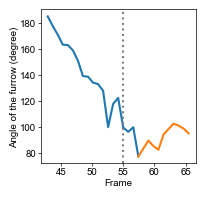

rep 37


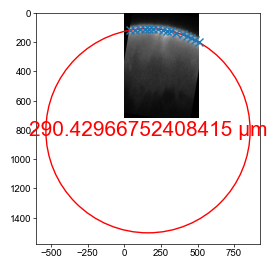

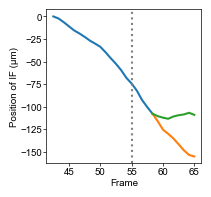

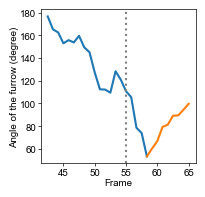

In [15]:
wt_info = []

for i in wt_replicates_info.index:

    replicate = wt_replicates_info.loc[i]
    print('rep', replicate.rep)

    # import the data
    replicate_file_name = replicate.replicate + '\\' + replicate.embryo + '\\mt_cp.csv'
    replicate_mt_cp = pd.read_csv(replicate_file_name)
    if 'Slice' in replicate_mt_cp.columns:
        replicate_mt_cp = replicate_mt_cp.rename({'Slice':'Frame'}, axis='columns')
    replicate_mt_cp = replicate_mt_cp[['X', 'Y', 'Frame']].sort_values(['Frame', 'Y']).reset_index().drop(columns='index')

    replicate_file_name_angle = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy_angle_measurement.csv'
    replicate_angle = pd.read_csv(replicate_file_name_angle)['0']

    # basic info
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    m1, i2, ck1, m2, septum1, i3 = replicate.m1, replicate.i2, replicate.ck1, replicate.m2, replicate.septum1, replicate.i3

    # r_0
    replicate_file_name_r0_fit_circle = replicate.replicate + '\\' + replicate.embryo + '\\r0_fit_circle.csv'
    replicate_r0_fit_circle = pd.read_csv(replicate_file_name_r0_fit_circle)[['X', 'Y']]
    circle_points = np.array(replicate_r0_fit_circle) / pixel_size
    fit_circle_xc, fit_circle_yc, fit_circle_r = fit_circle(circle_points)

    movie_sectionmidy = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy.tif'
    movie_sectionmidy = skimage.io.imread(movie_sectionmidy)
    if len(movie_sectionmidy.shape) == 4:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2, 1]
    elif len(movie_sectionmidy.shape) == 3:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2]

    fig,ax=plt.subplots(figsize=[4,3])
    ax.imshow(movie_frame_r0_fit_circle, cmap='Greys_r')
    ax.plot(circle_points[:,0], circle_points[:, 1], 'x')
    circle = mpl.patches.Circle(xy=(fit_circle_xc, fit_circle_yc), radius=fit_circle_r, fill=False, ec='red')
    ax.add_patch(circle)
    ax.text(fit_circle_xc, fit_circle_yc+30, str(fit_circle_r*pixel_size) + ' \u03BCm', color = 'red' , ha = 'center', fontsize=15)
    plt.show()
    r_0 = fit_circle_r*pixel_size

    # indentation and invagination
    if_position_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<septum1].Y.values)
    if_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[1::2])
    if_position_phase2 = np.insert(if_position_phase2, 0, if_position_phase1[-1])
    cp_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[0::2])
    cp_position_phase2 = np.insert(cp_position_phase2, 0, if_position_phase1[-1])

    angle_phase1 = np.array(replicate_angle[:septum1 - ck1])
    angle_phase2 = np.array(replicate_angle[septum1 - ck1-1:])

    frame_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<septum1].Frame.values)
    frame_phase2 = np.unique(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Frame.values)
    frame_phase2 = np.insert(frame_phase2, 0, frame_phase1[-1])
    frame_phase12 = np.arange(ck1, i3+1)

    time_phase1 = (frame_phase1 - m2)/(m1-m2)*(30-55) + 55
    time_phase2 = (frame_phase2 - m2)/(m1-m2)*(30-55) + 55
    time_phase12 = np.concatenate([time_phase1, time_phase2[1:]])

    # displacement
    if_displacement_phase1 = if_position_phase1[-1] - if_position_phase1[0]
    if_displacement_phase2 = if_position_phase2[-1] - if_position_phase2[0]

    # speed
    if_speed_phase1 = speed_calculator(time_phase1, if_position_phase1)
    if_speed_phase2 = speed_calculator(time_phase2, if_position_phase2)

    # export the data
    if_position_phase1_normalized = 0-(if_position_phase1 - if_position_phase1[0])
    if_position_phase2_normalized = 0-(if_position_phase2 - if_position_phase1[0])
    cp_position_phase2_normalized = 0-(cp_position_phase2 - if_position_phase1[0])

    replicate_info = {'name': replicate.rep,
                      'data': [if_position_phase1_normalized, if_position_phase2_normalized, cp_position_phase2_normalized, # 0,1,2
                               time_phase1, time_phase2, # 3,4
                               if_displacement_phase1, if_displacement_phase2, # 5,6
                               if_speed_phase1, if_speed_phase2, # 7,8
                               angle_phase1, angle_phase2, # 9,10
                               fit_circle_r*pixel_size # 11
                               ]} 
    
    wt_info.append(replicate_info)

    fig, ax = plt.subplots(figsize=[2,2])
    ax.plot(time_phase1, if_position_phase1_normalized)
    ax.plot(time_phase2, if_position_phase2_normalized)
    ax.plot(time_phase2, cp_position_phase2_normalized)
    ax.axvline(x = 55, color='grey', linestyle='dotted')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Position of IF (\u03BCm)')
    plt.show()

    fig, ax1 = plt.subplots(figsize=[2,2])
    ax1.plot(time_phase1, angle_phase1, color='tab:blue')
    ax1.plot(time_phase2, angle_phase2, color='tab:orange')
    ax1.axvline(x = 55, color='grey', linestyle='dotted')
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Angle of the furrow (degree)')
    plt.show()


##### preview

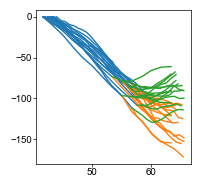

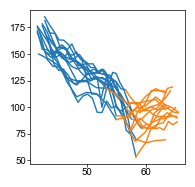

In [16]:
# preview

fig, ax = plt.subplots(figsize=[2,2])
for i in wt_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
   
    lw, alpha = 1,  1
    ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

fig, ax1 = plt.subplots(figsize=[2,2])
for i in wt_replicates_info.index:
    time_phase1, time_phase2 = wt_info[i]['data'][3:5]
    angle_phase1, angle_phase2 = wt_info[i]['data'][9:11]
   
    lw, alpha = 1,  1
    ax1.plot(time_phase1, angle_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax1.plot(time_phase2, angle_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
plt.show()

##### preview (together with r_0)

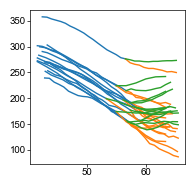

In [17]:
# preview (together with r_0)
fig, ax = plt.subplots(figsize=[2,2])
for i in wt_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
    r_0 = wt_info[i]['data'][11]

    lw, alpha = 1,  1
    ax.plot(time_phase1, r_0+if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax.plot(time_phase2, r_0+if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    ax.plot(time_phase2, r_0+cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

##### check the developmental timing

,ck,septum1,i3
count,15.000000,15.000000,15.000000
mean,42.539762,56.900897,64.348358
std,0.743964,1.570662,0.882696
min,41.666667,53.333333,63.333333
25%,41.785714,56.376488,63.333333
50%,42.500000,57.000000,64.166667
75%,42.965517,57.959770,65.225184
max,43.970588,59.268293,65.483871


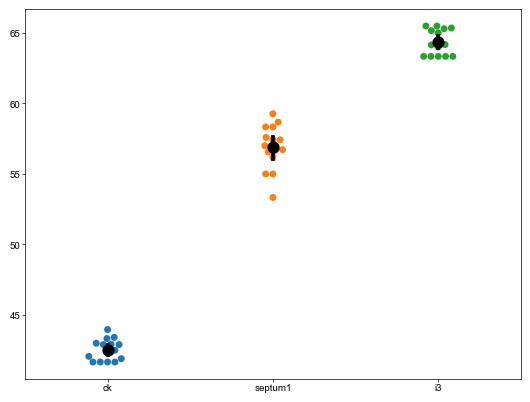

In [18]:
real_ck = [wt_info[i]['data'][3][0] for i in wt_replicates_info.index]
real_septum1 = [wt_info[i]['data'][4][0] for i in wt_replicates_info.index]
real_i3 = [wt_info[i]['data'][4][-1] for i in wt_replicates_info.index]

df = {'ck':real_ck, 'septum1':real_septum1, 'i3':real_i3}
df = pd.DataFrame(df)

sns.swarmplot(data = df)
sns.pointplot(data = df, color='black', ls='none', zorder=5)

df.describe()

In [19]:
# in conclusion
real_ck1 = 42.5
real_septum1 = 57
real_i3 = 64

##### average the wt indentation and invagination (raw, without r_0)

rep 1
rep 2
rep 3
rep 4
rep 5
rep 6
rep 7
rep 8
rep 9
rep 11
rep 12
rep 26
rep 27
rep 36
rep 37


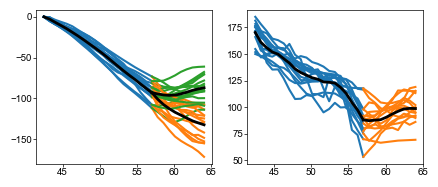

In [20]:
time_phase1_interp = np.linspace(real_ck1, real_septum1, 20)
time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp = []
if_displacement_phase2_interp = []
cp_displacement_phase2_interp = []
angle_phase1_interp = []
angle_phase2_interp = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in wt_replicates_info.index:
# for i in[0]:
    print('rep', wt_replicates_info.rep[i])

    # if interp
    if_displacement_phase1 = wt_info[i]['data'][0]
    if_displacement_phase1_newtime = np.linspace(real_ck1, real_septum1, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp.append(if_displacement_phase1_new)

    if_displacement_phase2 = wt_info[i]['data'][1]
    if_displacement_phase2_newtime = np.linspace(real_septum1, real_i3, len(if_displacement_phase2))
    if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    if_displacement_phase2_interp.append(if_displacement_phase2_new)
    
    cp_displacement_phase2 = wt_info[i]['data'][2]
    cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    cp_displacement_phase2_interp.append(cp_displacement_phase2_new)

    # angle interp
    angle_phase1 = wt_info[i]['data'][9]
    angle_phase1_newtime = np.linspace(real_ck1, real_septum1, len(angle_phase1))
    angle_phase1_new = np.interp(x=time_phase1_interp, xp=angle_phase1_newtime, fp=angle_phase1)
    angle_phase1_interp.append(angle_phase1_new)

    angle_phase2 = wt_info[i]['data'][10]
    angle_phase2_newtime = np.linspace(real_septum1, real_i3, len(angle_phase2))
    angle_phase2_new = np.interp(x=time_phase2_interp, xp=angle_phase2_newtime, fp=angle_phase2)
    angle_phase2_interp.append(angle_phase2_new)

    ax.plot(time_phase1_interp, if_displacement_phase1_new, color='tab:blue')
    ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')

    ax1.plot(time_phase1_interp, angle_phase1_new, color='tab:blue')
    ax1.plot(time_phase2_interp, angle_phase2_new, color='tab:orange')

if_displacement_phase1_interp = np.array(if_displacement_phase1_interp)
if_displacement_phase2_interp = np.array(if_displacement_phase2_interp)
cp_displacement_phase2_interp = np.array(cp_displacement_phase2_interp)

angle_phase1_interp = np.array(angle_phase1_interp)
angle_phase2_interp = np.array(angle_phase2_interp)

if_cp_averaged_wo_r0 = []
for list in [if_displacement_phase1_interp, if_displacement_phase2_interp, cp_displacement_phase2_interp, angle_phase1_interp, angle_phase2_interp]:
    if_cp_averaged_wo_r0.append(np.average(list, axis=0))
    if_cp_averaged_wo_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp, if_cp_averaged_wo_r0[0], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[2], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[4], color='black', lw=2)

ax1.plot(time_phase1_interp, if_cp_averaged_wo_r0[6], color='black', lw=2)
ax1.plot(time_phase2_interp, if_cp_averaged_wo_r0[8], color='black', lw=2)

plt.show()


##### average the wt indentation and invagination (raw, without r_0, a second strategy)

rep 1
rep 2
rep 3
rep 4
rep 5
rep 6
rep 7
rep 8
rep 9
rep 11
rep 12
rep 26
rep 27
rep 36
rep 37


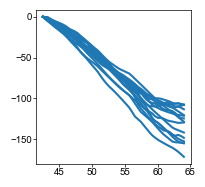

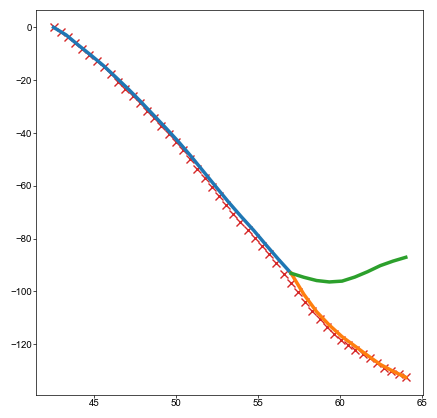

In [21]:
time_phase12_interp = np.linspace(real_ck1, real_i3, 50)

if_displacement_phase12_interp = []

fig, ax =plt.subplots(figsize=[2,2])

for i in wt_replicates_info.index:
    print('rep', wt_replicates_info.rep[i])

    # if_displacement_phase1
    if_displacement_phase1 = wt_info[i]['data'][0]
    if_displacement_phase2 = wt_info[i]['data'][1]

    if_displacement_phase12 = np.concatenate([if_displacement_phase1[:-1], if_displacement_phase2])
    if_displacement_phase12_new = np.interp(x=time_phase12_interp, xp=np.linspace(real_ck1, real_i3, len(if_displacement_phase12)), fp=if_displacement_phase12)
    if_displacement_phase12_interp.append(if_displacement_phase12_new)

    ax.plot(time_phase12_interp, if_displacement_phase12_new, color='tab:blue')
plt.show()

if_cp_averaged_wo_r0_2 = []
for list in [if_displacement_phase12_interp]:
    if_cp_averaged_wo_r0_2.append(np.average(list, axis=0))
    if_cp_averaged_wo_r0_2.append(np.std(list, axis=0))

# compare it with the first strategy

fig, ax = plt.subplots(figsize=[5,5])
lw=2.5
ax.plot(time_phase1_interp, if_cp_averaged_wo_r0[0], color='tab:blue', lw=lw, zorder=1, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[2], color='tab:orange', lw=lw, zorder=1, label='phase 2 - membrane tip')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[4], color='tab:green', lw=lw, zorder=1, label='phase 2 - contact point')
ax.plot(time_phase12_interp, if_cp_averaged_wo_r0_2[0], 'x', color='tab:red', lw=lw, zorder=-1, label='phase 2 - contact point')
plt.show()

##### average the wt indentation and invagination (with r_0, but not normalized with r_0)

rep 1
rep 2
rep 3
rep 4
rep 5
rep 6
rep 7
rep 8
rep 9
rep 11
rep 12
rep 26
rep 27
rep 36
rep 37


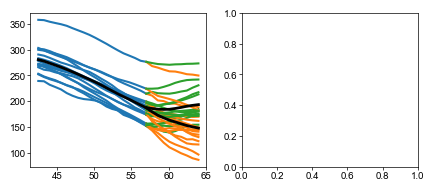

In [22]:
time_phase1_interp = np.linspace(real_ck1, real_septum1, 20)
time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0 = []
if_displacement_phase2_interp_wr0 = []
cp_displacement_phase2_interp_wr0 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in wt_replicates_info.index:
# for i in[0]:
    print('rep', wt_replicates_info.rep[i])
    r_0 = wt_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = wt_info[i]['data'][0] + r_0
    if_displacement_phase1_newtime = np.linspace(real_ck1, real_septum1, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0.append(if_displacement_phase1_new)

    if_displacement_phase2 = wt_info[i]['data'][1] + r_0
    if_displacement_phase2_newtime = np.linspace(real_septum1, real_i3, len(if_displacement_phase2))
    if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    if_displacement_phase2_interp_wr0.append(if_displacement_phase2_new)
    
    cp_displacement_phase2 = wt_info[i]['data'][2] + r_0
    cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    cp_displacement_phase2_interp_wr0.append(cp_displacement_phase2_new)


    ax.plot(time_phase1_interp, if_displacement_phase1_new, color='tab:blue')
    ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0 = np.array(if_displacement_phase1_interp_wr0)
if_displacement_phase2_interp_wr0 = np.array(if_displacement_phase2_interp_wr0)
cp_displacement_phase2_interp_wr0 = np.array(cp_displacement_phase2_interp_wr0)


if_cp_averaged_w_r0 = []
for list in [if_displacement_phase1_interp_wr0, if_displacement_phase2_interp_wr0, cp_displacement_phase2_interp_wr0]:
    if_cp_averaged_w_r0.append(np.average(list, axis=0))
    if_cp_averaged_w_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp, if_cp_averaged_w_r0[0], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_w_r0[2], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_w_r0[4], color='black', lw=2)

plt.show()

##### average the wt indentation and invagination (with r_0 and normalized with r_0)

rep 1
rep 2
rep 3
rep 4
rep 5
rep 6
rep 7
rep 8
rep 9
rep 11
rep 12
rep 26
rep 27
rep 36
rep 37


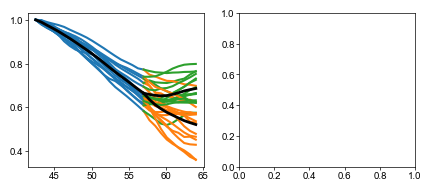

In [23]:
time_phase1_interp = np.linspace(real_ck1, real_septum1, 20)
time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0_2 = []
if_displacement_phase2_interp_wr0_2 = []
cp_displacement_phase2_interp_wr0_2 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in wt_replicates_info.index:
# for i in[0]:
    print('rep', wt_replicates_info.rep[i])
    r_0 = wt_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = wt_info[i]['data'][0] / r_0 +1
    if_displacement_phase1_newtime = np.linspace(real_ck1, real_septum1, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0_2.append(if_displacement_phase1_new)

    if_displacement_phase2 = wt_info[i]['data'][1] / r_0 +1
    if_displacement_phase2_newtime = np.linspace(real_septum1, real_i3, len(if_displacement_phase2))
    if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    if_displacement_phase2_interp_wr0_2.append(if_displacement_phase2_new)
    
    cp_displacement_phase2 = wt_info[i]['data'][2] / r_0 +1
    cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    cp_displacement_phase2_interp_wr0_2.append(cp_displacement_phase2_new)


    ax.plot(time_phase1_interp, if_displacement_phase1_new, color='tab:blue')
    ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0_2 = np.array(if_displacement_phase1_interp_wr0_2)
if_displacement_phase2_interp_wr0_2 = np.array(if_displacement_phase2_interp_wr0_2)
cp_displacement_phase2_interp_wr0_2 = np.array(cp_displacement_phase2_interp_wr0_2)


if_cp_averaged_w_r0_2 = []
for list in [if_displacement_phase1_interp_wr0_2, if_displacement_phase2_interp_wr0_2, cp_displacement_phase2_interp_wr0_2]:
    if_cp_averaged_w_r0_2.append(np.average(list, axis=0))
    if_cp_averaged_w_r0_2.append(np.std(list, axis=0))

ax.plot(time_phase1_interp, if_cp_averaged_w_r0_2[0], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[2], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[4], color='black', lw=2)


plt.show()

##### plot for the paper (fig. 1F')

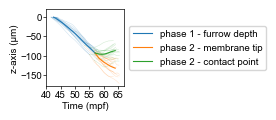

In [24]:
fig, ax = plt.subplots(figsize=[1, 1])

# plot each individual replicate
for i in wt_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
    
    lw, alpha = 0.4,  0.2
    ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)

# plot the averaged
lw=0.8
ax.plot(time_phase1_interp, if_cp_averaged_wo_r0[0], color='tab:blue', lw=lw, zorder=1, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[2], color='tab:orange', lw=lw, zorder=1, label='phase 2 - membrane tip')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[4], color='tab:green', lw=lw, zorder=2, label='phase 2 - contact point')

ax.set_ylim(-180, 20)
ax.set_yticks(np.arange(0, -151, -50)) 
ax.set_xlim(40, 67)
ax.set_xticks(np.arange(40, 70, 5)) 
ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('z-axis (\u03BCm)', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)

plt.savefig('wt_furrow_position_1.svg')
plt.show()

In [25]:
# export for excel
dfs = []

list1 = np.hstack([time_phase1_interp, time_phase2_interp, time_phase2_interp])
list2 = np.hstack([if_cp_averaged_wo_r0[0], if_cp_averaged_wo_r0[2], if_cp_averaged_wo_r0[4]])
list3 = np.hstack([['blue'] * len(time_phase1_interp), ['orange'] * len(time_phase2_interp), ['green'] * len(time_phase2_interp)])
list4 = ['Mean'] * len(list3)

df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'z-axis (micron)': list2, 'Color illustration':list3})
dfs.append(df)

for i in wt_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]

    list1 = np.hstack([time_phase1, time_phase2, time_phase2])
    list2 = np.hstack([if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2])
    list3 = np.hstack([['blue'] * len(time_phase1), ['orange'] * len(time_phase2), ['green'] * len(time_phase2)])
    list4 = [wt_info[i]['name']] * len(list3)

    df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'z-axis (micron)': list2, 'Color illustration':list3})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all
df_all.to_excel('wt_furrow_position_1_excel_fig1fprime.xlsx', index=False)

##### make two colormaps to illustrate the time of phase1 and phase2

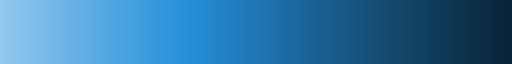

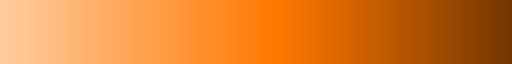

In [26]:
def shaded_cmap(color="tab:blue", shade_range=[.2, .8]):
    import colorsys
    num = 1024
    color_rgb = mpl.colors.to_rgb(color)
    color_hls = colorsys.rgb_to_hls(color_rgb[0], color_rgb[1], color_rgb[2])
    shading = np.linspace(shade_range[0], shade_range[1], num)
    gamma = math.log(0.5) / math.log(color_hls[1])
    shading_conversion = np.exp(np.log(shading)/gamma)
    shaded_cmap = []
    for i in range(num):
        shaded_color = colorsys.hls_to_rgb(color_hls[0], shading_conversion[i], color_hls[2])
        shaded_cmap.append(shaded_color)
    
    # _,ax=plt.subplots(figsize=(3,2))
    # ax.scatter(range(num), shading_conversion, color=shaded_cmap)
    # ax.scatter((num-1)/2, color_hls[1], color=color, s=200)
    # ax.set_ylim(0,1)
    # ax.set_ylabel('Lightness')
    # plt.show()

    shaded_cmap = mpl.colors.ListedColormap(shaded_cmap)
    return shaded_cmap

def colored_line(x,y,c,ax, vmin='auto', vmax='auto', **lc_kwargs):
    
    from matplotlib.collections import LineCollection
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # c = (c-np.nanmin(c)) / (np.nanmax(c) - np.nanmin(c))
    # c = (c-vmin) / (vmax-vmin)
    # colors = plt.colormaps[cmap](c)

    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    if vmin == 'auto':
        vmin = c.min()
    if vmax == 'auto':
        vmax = c.max()

    lc = LineCollection(segments, **default_kwargs)
    if (vmin==0) and (vmax ==1):
        lc.set_array(c)
    else:
        lc.set_array(c)
        lc.set(clim=(vmin, vmax))

    return ax.add_collection(lc)

shaded_tab_blue = shaded_cmap("tab:blue", [0.8, 0.2])
shaded_tab_orange = shaded_cmap("tab:orange", [0.8, 0.2])

display(shaded_tab_blue)
display(shaded_tab_orange)

##### export h1 h2

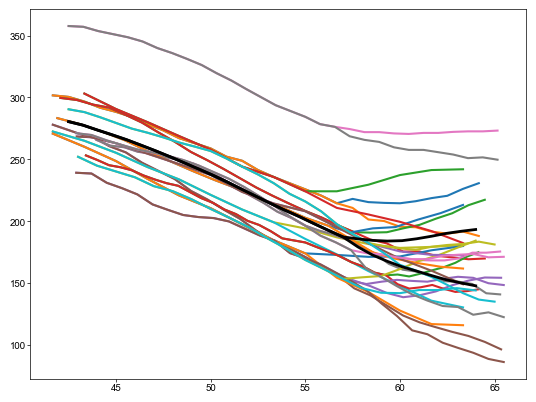

In [27]:
folder = 'furrow_position_wt_h1h2'
create_folder(folder)

# individual h1 and h2
for i in wt_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
    r_0 = wt_info[i]['data'][11]

    time_phase12 = np.concatenate([time_phase1[:-1], time_phase2])
    h_1 = np.concatenate([if_displacement_phase1[:-1], cp_displacement_phase2]) + r_0
    h_2 = np.concatenate([if_displacement_phase1[:-1], if_displacement_phase2]) + r_0
    np.save(folder + "\\" + "rep" + str(wt_info[i]['name']) + "_time_h1_h2.npy", [time_phase12, h_1, h_2])

    plt.plot(time_phase12, h_1)
    plt.plot(time_phase12, h_2)

# averaged h1 and h2
time_phase12 = np.concatenate([time_phase1_interp[:-1], time_phase2_interp])
h_1 = np.concatenate([if_cp_averaged_w_r0[0][:-1], if_cp_averaged_w_r0[2]])
h_2 = np.concatenate([if_cp_averaged_w_r0[0][:-1], if_cp_averaged_w_r0[4]])
np.save(folder + "\\wt_avg_time_h1_h2.npy", [time_phase12, h_1, h_2])

plt.plot(time_phase12, h_1, color='black', lw=2)
plt.plot(time_phase12, h_2, color='black', lw=2)

##### plot for the paper (fig. 6D)

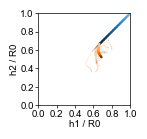

0.6642035154628515 0.6859223158596038 0.5212070027698842


In [28]:
fig, ax = plt.subplots(figsize=[1.2, 1.2])

# plot individual replicates
for i in wt_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
    r_0 = wt_info[i]['data'][11]

    lw, alpha = 0.8,  0.2
    colored_line(x=if_displacement_phase1/r_0+1, y=if_displacement_phase1/r_0+1, c=time_phase1, cmap=shaded_tab_blue, lw=lw, zorder=-2, alpha=alpha, ax=ax)#, capstyle='round')
    colored_line(x=cp_displacement_phase2/r_0+1, y=if_displacement_phase2/r_0+1, c=time_phase2, cmap=shaded_tab_orange, lw=lw, zorder=-1, alpha=alpha, ax=ax)#, capstyle='round')

# plot the averaged
lw=1.6
colored_line(x=if_cp_averaged_w_r0_2[0], y=if_cp_averaged_w_r0_2[0], c=time_phase1_interp, vmin=42.5, vmax=57, cmap=shaded_tab_blue, lw=lw, zorder=1, ax=ax, label='phase 1 - furrow depth', capstyle='round')
colored_line(x=if_cp_averaged_w_r0_2[4], y=if_cp_averaged_w_r0_2[2], c=time_phase2_interp, vmin=57, vmax=64, cmap=shaded_tab_orange, lw=lw, zorder=1, ax=ax, label='phase 2 - membrane tip', capstyle='round')

ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.2)) 
ax.set_xlim(0, 1)
ax.set_xticks(np.arange(0, 1.1, 0.2)) 

ax.set_xlabel('h1 / R0', fontsize=7)
ax.set_ylabel('h2 / R0', fontsize=7)
ax.set_aspect('equal')
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('wt_furrow_position_2.svg')
plt.show()

print(if_cp_averaged_w_r0_2[0][-1],
      if_cp_averaged_w_r0_2[4][-1],
      if_cp_averaged_w_r0_2[2][-1])

In [29]:
# export for excel Fig, 6D
dfs = []

list1 = np.hstack([time_phase1_interp, time_phase2_interp])
list2 = np.hstack([if_cp_averaged_w_r0_2[0], if_cp_averaged_w_r0_2[4]])
list22 = np.hstack([if_cp_averaged_w_r0_2[0], if_cp_averaged_w_r0_2[2]])
list3 = np.hstack([['blue'] * len(time_phase1_interp), ['orange'] * len(time_phase2_interp)])

list4 = ['Mean'] * len(list3)

df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'h1 / R0': list2, 'h2 / R0': list22, 'Color illustration (as in the schematics)':list3})
dfs.append(df)

for i in wt_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]

    list1 = np.hstack([time_phase1, time_phase2])
    list2 = np.hstack([if_displacement_phase1/r_0+1, cp_displacement_phase2/r_0+1])
    list22 = np.hstack([if_displacement_phase1/r_0+1, if_displacement_phase2/r_0+1])
    list3 = np.hstack([['blue'] * len(time_phase1), ['orange'] * len(time_phase2)])

    list4 = [wt_info[i]['name']] * len(list3)

    df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'h1 / R0': list2, 'h2 / R0': list22, 'Color illustration (as in the schematics)':list3})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all
df_all.to_excel('wt_furrow_position_1_excel_fig6d.xlsx', index=False)

In [30]:
# export for excel Fig, 6E
df_to_export = []

for i in wt_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]

    df_to_export.append([wt_info[i]['name'], (cp_displacement_phase2/r_0+1)[-1], (if_displacement_phase2/r_0+1)[-1]])

df_to_export = pd.DataFrame(df_to_export, columns = ['Replicate #', 'h1 / R0', 'h2 / R0'])
df_to_export.to_excel('wt_furrow_position_1_excel_fig6e.xlsx', index=False)


##### plot for the paper (fig. 6E)

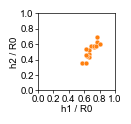

In [31]:
fig, ax = plt.subplots(figsize=[1, 1])

for i in wt_replicates_info.index:

    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
    r_0 = wt_info[i]['data'][11]

    lw, alpha = 0.8,  1
    ax.plot(cp_displacement_phase2[-1]/r_0+1, if_displacement_phase2[-1]/r_0+1, marker='o', mfc='tab:orange', mec='white', mew=0.3, markersize=3.5, alpha=1, zorder=5)
    
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.2)) 
ax.set_xlim(0, 1)
ax.set_xticks(np.arange(0, 1.1, 0.2)) 

ax.set_xlabel('h1 / R0', fontsize=7)
ax.set_ylabel('h2 / R0', fontsize=7)
ax.set_aspect('equal')
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('wt_furrow_position_3.svg')
plt.show()

##### plot the colorbar (fig. 6D)

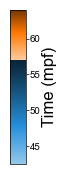

In [32]:
fig, ax = plt.subplots(figsize=(0.2, 2), layout='constrained')

phase1_color_num = int((real_septum1-real_ck1) / (real_i3-real_ck1) * 1024)
phase2_color_num = 1024 - phase1_color_num
colors = np.vstack([shaded_tab_blue(np.linspace(0, 1, phase1_color_num)),
                    shaded_tab_orange(np.linspace(0, 1, phase2_color_num))])
custom_cmap = mpl.colors.ListedColormap(colors)

fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=42.5, vmax=64),
                                   cmap=custom_cmap),
                                   cax=ax, orientation='vertical')

ax.set_ylabel('Time (mpf)', fontsize=12)
ax.set_yticks(np.arange(45,61,5))
plt.savefig('wt_furrow_position_2_colorbar.svg')

##### Compare the furrow progression speed of phase 1 and phase 2

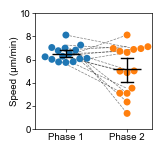

6.503449485225885
5.171160638383841
TtestResult(statistic=np.float64(2.4665066002162885), pvalue=np.float64(0.027166620616633493), df=np.int64(14))


In [33]:
wt_speeds = np.array([wt_info[i]['data'][7:9] for i in wt_replicates_info.index])

fig, ax = plt.subplots(figsize=[1.5, 1.5])
wt_speeds_plot = sns.swarmplot(wt_speeds, ax=ax, size=5)
swarmplot_pair_lines(wt_speeds_plot, ax)

sns.pointplot(data = wt_speeds, color='black', ax=ax,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1, zorder=10,
              capsize=0.2, err_kws={'linewidth': 1})

ax.set_xticks([0,1])
ax.set_xticklabels(['Phase 1', 'Phase 2'])
ax.set_xlim(-0.5, 1.4)
ax.set_ylim(0, 10)
ax.set_yticks(np.arange(0,11,2))
ax.set_ylabel('Speed (\u03BCm/min)')
plt.savefig('wt_furrow_speed.svg')
plt.show()

# statistics
group1 = wt_speeds[:, 0]
group2 = wt_speeds[:, 1]
print(np.mean(group1))
print(np.mean(group2))
print(scipy.stats.ttest_rel(group1, group2))

##### plot for the paper (fig. S6A)

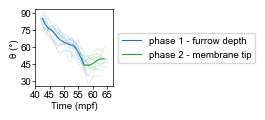

In [34]:
fig, ax = plt.subplots(figsize=[1, 1])

# plot each individual replicate
for i in wt_replicates_info.index:

    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
    angle_phase1, angle_phase2 = wt_info[i]['data'][9:11]
    
    lw, alpha = 0.4,  0.2
    ax.plot(time_phase1, angle_phase1/2, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax.plot(time_phase2, angle_phase2/2, color='tab:green', lw=lw, zorder=-1, alpha=alpha)

# plot the averaged
lw=0.8
ax.plot(time_phase1_interp, if_cp_averaged_wo_r0[6]/2, color='tab:blue', lw=lw, zorder=1, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[8]/2, color='tab:green', lw=lw, zorder=1, label='phase 2 - membrane tip')

ax.set_ylim(25, 93)
ax.set_yticks(np.arange(30, 91, 15)) 
ax.set_xlim(40, 67)
ax.set_xticks(np.arange(40, 70, 5)) 
ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('θ (°)', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('wt_furrow_angle.svg')
plt.show()

In [35]:
# export for excel
dfs = []

list1 = np.hstack([time_phase1_interp, time_phase2_interp])
list2 = np.hstack([if_cp_averaged_wo_r0[6]/2, if_cp_averaged_wo_r0[8]/2])
list3 = np.hstack([['blue'] * len(time_phase1_interp), ['green'] * len(time_phase2_interp)])
list4 = ['Mean'] * len(list3)

df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'Angle (degree)': list2, 'Color illustration (as in the schematics)':list3})
dfs.append(df)

for i in wt_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
    angle_phase1, angle_phase2 = wt_info[i]['data'][9:11]

    list1 = np.hstack([time_phase1, time_phase2])
    list2 = np.hstack([angle_phase1/2, angle_phase2/2])
    list3 = np.hstack([['blue'] * len(time_phase1), ['green'] * len(time_phase2)])
    list4 = [wt_info[i]['name']] * len(list3)

    df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'Angle (degree)': list2, 'Color illustration (as in the schematics)':list3})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all
df_all.to_excel('wt_furrow_angle_excel_figs7c.xlsx', index=False)
df_all

,Replicate #,Time (mpf),Angle (degree),Color illustration (as in the schematics)
0,Mean,42.500000,85.146862,blue
1,Mean,43.263158,80.474220,blue
2,Mean,44.026316,77.981815,blue
3,Mean,44.789474,75.946927,blue
4,Mean,45.552632,74.942857,blue
...,...,...,...,...
399,37,61.666667,40.610758,green
400,37,62.500000,44.561410,green
401,37,63.333333,44.706070,green
402,37,64.166667,47.202190,green


# Calcium-free

##### process the raw data

In [36]:
cafree_replicates_info = data_info[data_info['furrow_indentation']=='cafree'].reset_index()
display(cafree_replicates_info)

,index,rep,experiment,replicate,embryo,type,Unnamed: 5,time_interval,pixel_size,voxel_depth,...,cortical_actin_intensity_quanti1,cortical_actin_intensity_quanti2,geometry,astral_mt_growth,real_i2,real_m2,real_time_interval,real_ck1,real_i3,real_m1
0,70,71,furrow_indentation_and_invagination,cafree\JO220802_LSM9001_UtrnGFP_Ca-free,e1,NaN,NaN,46.93,1.2479,NaN,...,NaN,NaN,NaN,NaN,40.294118,55,0.735294,42.5,62.352941,30.0
1,72,73,furrow_indentation_and_invagination,cafree\JO220802_LSM9001_UtrnGFP_Ca-free,e3,NaN,NaN,46.82,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,0.645833,42.729167,63.395833,NaN
2,73,74,furrow_indentation_and_invagination,cafree\JO220730_LSM9001_UtrnGFP_Ca-free,e3,NaN,NaN,46.82,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,0.775,43.375,63.525,NaN
3,78,79,furrow_indentation_and_invagination,cafree\xin250409_lsm9001_utr_dclk_cafree,e1,NaN,maybe okay,94.27,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.291667,42.083333,62.75,NaN
4,80,81,furrow_indentation_and_invagination,cafree\xin250409_lsm9001_utr_dclk_cafree,e3,NaN,ok,95.73,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.291667,42.083333,64.041667,NaN
5,84,85,furrow_indentation_and_invagination,cafree\xin250410_lsm9001_utr_dclk_cafree,e1,NaN,NaN,94.14,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.722222,41.222222,65.333333,NaN
6,86,87,furrow_indentation_and_invagination,cafree\xin250410_lsm9001_utr_dclk_cafree,e3,NaN,NaN,94.34,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.409091,40.909091,63.454545,NaN
7,87,88,furrow_indentation_and_invagination,cafree\xin250410_lsm9001_utr_dclk_cafree,e4,NaN,NaN,95.04,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.409091,40.909091,63.454545,NaN
8,88,89,furrow_indentation_and_invagination,cafree\xin250410_lsm9001_utr_dclk_cafree,e5,NaN,NaN,94.59,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.291667,42.083333,62.75,NaN
9,89,90,furrow_indentation_and_invagination,cafree\xin250410_lsm9001_utr_dclk_cafree,e6,NaN,NaN,95.15,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.409091,43.727273,63.454545,NaN


rep 71


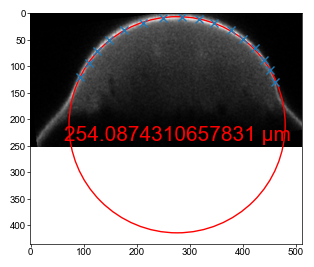

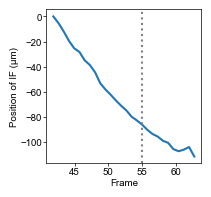

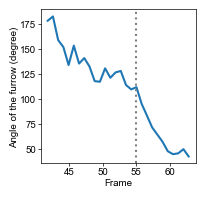

rep 73


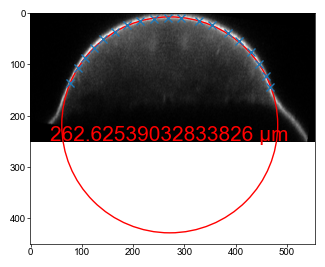

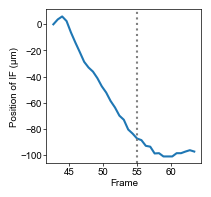

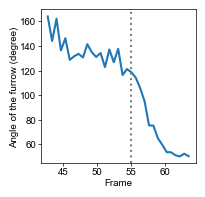

rep 74


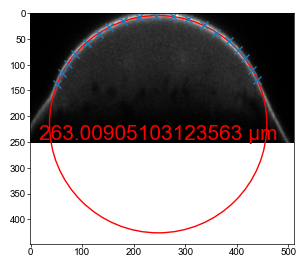

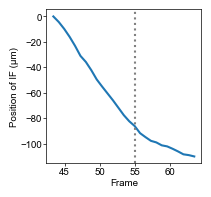

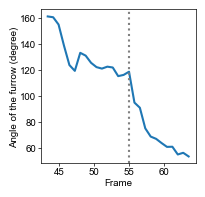

rep 79


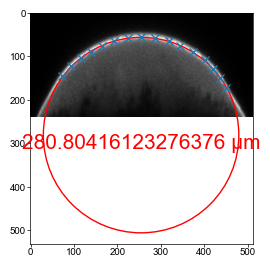

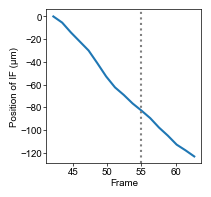

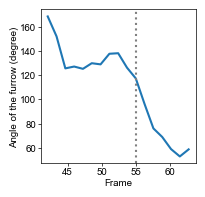

rep 81


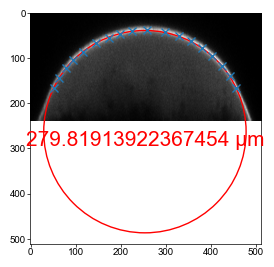

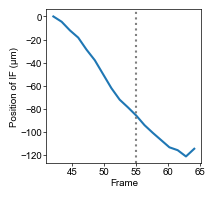

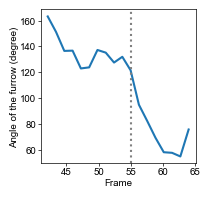

rep 85


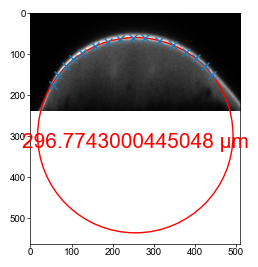

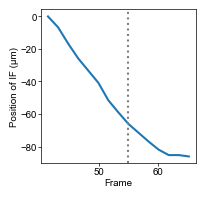

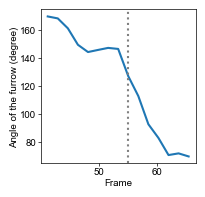

rep 87


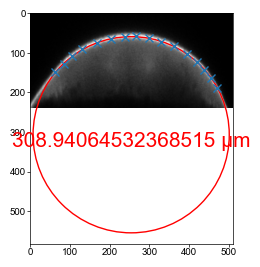

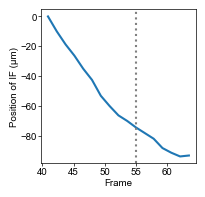

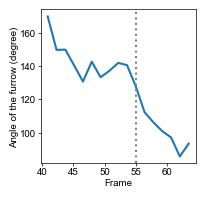

rep 88


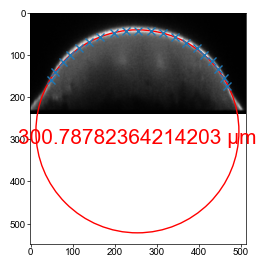

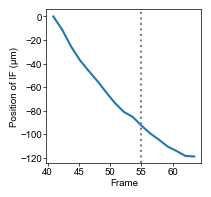

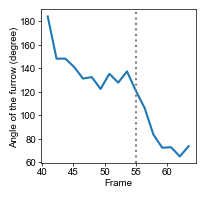

rep 89


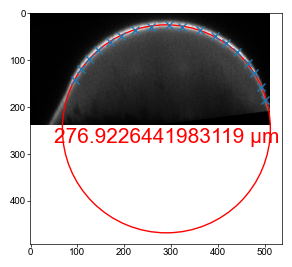

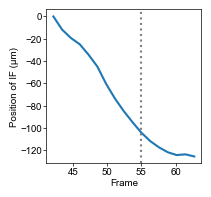

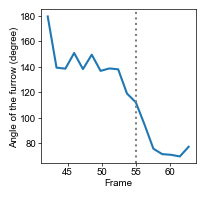

rep 90


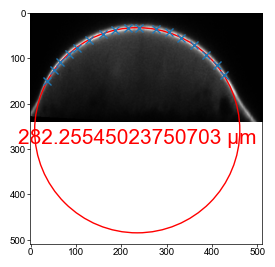

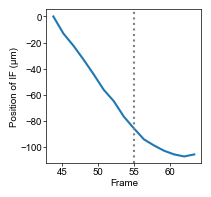

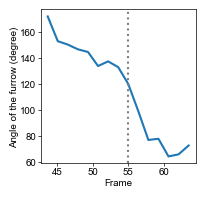

rep 91


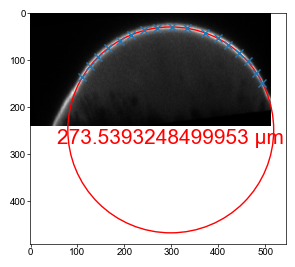

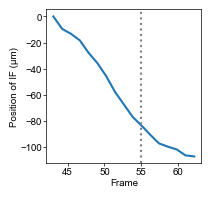

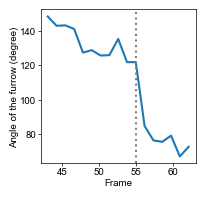

rep 92


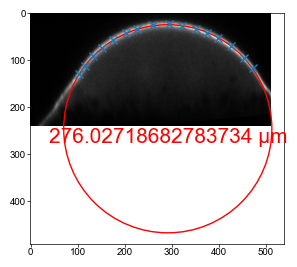

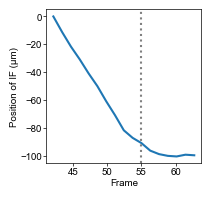

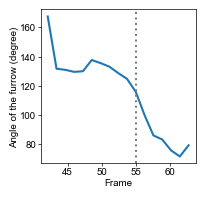

In [37]:
cafree_info = []

for i in cafree_replicates_info.index:

    replicate = cafree_replicates_info.loc[i]
    print('rep', replicate.rep)

    # import the data
    replicate_file_name = replicate.replicate + '\\' + replicate.embryo + '\\furrowtip.csv'
    replicate_mt_cp = pd.read_csv(replicate_file_name)
    if 'Slice' in replicate_mt_cp.columns:
        replicate_mt_cp = replicate_mt_cp.rename({'Slice':'Frame'}, axis='columns')
    replicate_mt_cp = replicate_mt_cp[['X', 'Y', 'Frame']].sort_values(['Frame', 'Y']).reset_index().drop(columns='index')

    replicate_file_name_angle = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy_angle_measurement.csv'
    replicate_angle = pd.read_csv(replicate_file_name_angle)['0']

    # basic info
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    m1, i2, ck1, m2, septum1, i3 = replicate.m1, replicate.i2, replicate.ck1, replicate.m2, replicate.septum1, replicate.i3

    # r_0
    replicate_file_name_r0_fit_circle = replicate.replicate + '\\' + replicate.embryo + '\\r0_fit_circle.csv'
    replicate_r0_fit_circle = pd.read_csv(replicate_file_name_r0_fit_circle)[['X', 'Y']]
    circle_points = np.array(replicate_r0_fit_circle) / pixel_size
    fit_circle_xc, fit_circle_yc, fit_circle_r = fit_circle(circle_points)

    movie_sectionmidy = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy.tif'
    movie_sectionmidy = skimage.io.imread(movie_sectionmidy)
    if len(movie_sectionmidy.shape) == 4:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2, 1]
    elif len(movie_sectionmidy.shape) == 3:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2]

    fig,ax=plt.subplots(figsize=[4,3])
    ax.imshow(movie_frame_r0_fit_circle, cmap='Greys_r')
    ax.plot(circle_points[:,0], circle_points[:, 1], 'x')
    circle = mpl.patches.Circle(xy=(fit_circle_xc, fit_circle_yc), radius=fit_circle_r, fill=False, ec='red')
    ax.add_patch(circle)
    ax.text(fit_circle_xc, fit_circle_yc+30, str(fit_circle_r*pixel_size) + ' \u03BCm', color = 'red' , ha = 'center', fontsize=15)
    plt.show()
    r_0 = fit_circle_r*pixel_size

    # indentation and invagination
    if_position_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<500].Y.values)
    # if_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[1::2])
    # if_position_phase2 = np.insert(if_position_phase2, 0, if_position_phase1[-1])
    # cp_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[0::2])
    # cp_position_phase2 = np.insert(cp_position_phase2, 0, if_position_phase1[-1])

    angle_phase1 = np.array(replicate_angle[:])
    # angle_phase2 = np.array(replicate_angle[septum1 - ck1-1:])

    frame_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<500].Frame.values)
    # frame_phase2 = np.unique(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Frame.values)
    # frame_phase2 = np.insert(frame_phase2, 0, frame_phase1[-1])
    # frame_phase12 = np.arange(ck1, i3+1)

    time_phase1 = (frame_phase1 - m2)/(i2-m2)*(39.5-55) + 55
    # time_phase2 = (frame_phase2 - m2)/(m1-m2)*(30-55) + 55
    # time_phase12 = np.concatenate([time_phase1, time_phase2[1:]])

    # displacement
    if_displacement_phase1 = if_position_phase1[-1] - if_position_phase1[0]
    # if_displacement_phase2 = if_position_phase2[-1] - if_position_phase2[0]

    # # speed
    # if_speed_phase1 = speed_calculator(time_phase1, if_position_phase1)
    # if_speed_phase2 = speed_calculator(time_phase2, if_position_phase2)

    # export the data
    if_position_phase1_normalized = 0-(if_position_phase1 - if_position_phase1[0])
    # if_position_phase2_normalized = 0-(if_position_phase2 - if_position_phase1[0])
    # cp_position_phase2_normalized = 0-(cp_position_phase2 - if_position_phase1[0])

    replicate_info = {'name': replicate.rep,
                      'data': [if_position_phase1_normalized, _, _, # 0,1,2
                               time_phase1, _, # 3,4
                               if_displacement_phase1, _, # 5,6
                               _, _, # 7,8
                               angle_phase1, _, # 9,10
                               fit_circle_r*pixel_size # 11
                               ]} 
    
    cafree_info.append(replicate_info)

    fig, ax = plt.subplots(figsize=[2,2])
    ax.plot(time_phase1, if_position_phase1_normalized)
    # ax.plot(time_phase2, if_position_phase2_normalized)
    # ax.plot(time_phase2, cp_position_phase2_normalized)
    ax.axvline(x = 55, color='grey', linestyle='dotted')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Position of IF (\u03BCm)')
    plt.show()

    fig, ax1 = plt.subplots(figsize=[2,2])
    ax1.plot(time_phase1, angle_phase1, color='tab:blue')
    # ax1.plot(time_phase2, angle_phase2, color='tab:orange')
    ax1.axvline(x = 55, color='grey', linestyle='dotted')
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Angle of the furrow (degree)')
    plt.show()


##### preview

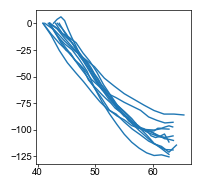

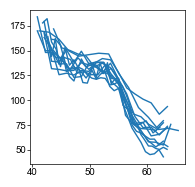

In [38]:
fig, ax = plt.subplots(figsize=[2,2])
for i in cafree_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = cafree_info[i]['data'][:5]
   
    lw, alpha = 1,  1
    ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    # ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

fig, ax1 = plt.subplots(figsize=[2,2])
for i in cafree_replicates_info.index:
    time_phase1, time_phase2 = cafree_info[i]['data'][3:5]
    angle_phase1, angle_phase2 = cafree_info[i]['data'][9:11]
   
    lw, alpha = 1,  1
    ax1.plot(time_phase1, angle_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax1.plot(time_phase2, angle_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
plt.show()

##### preview (together with r_0)

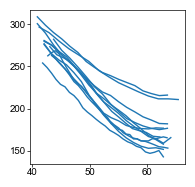

In [39]:
fig, ax = plt.subplots(figsize=[2,2])
for i in cafree_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = cafree_info[i]['data'][:5]
    r_0 = cafree_info[i]['data'][11]

    lw, alpha = 1,  1
    ax.plot(time_phase1, r_0+if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax.plot(time_phase2, r_0+if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    # ax.plot(time_phase2, r_0+cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

##### average the cafree indentation (raw, without r_0)

rep 71
rep 73
rep 74
rep 79
rep 81
rep 85
rep 87
rep 88
rep 89
rep 90
rep 91
rep 92


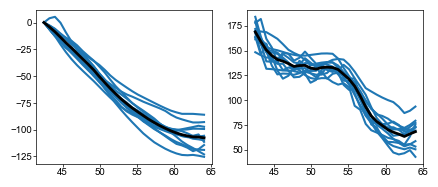

In [40]:
time_phase1_interp_cafree = np.linspace(real_ck1, real_i3, 30)
# time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp = []
# if_displacement_phase2_interp = []
# cp_displacement_phase2_interp = []
angle_phase1_interp = []
# angle_phase2_interp = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in cafree_replicates_info.index:
# for i in[0]:
    print('rep', cafree_replicates_info.rep[i])

    # if interp
    if_displacement_phase1 = cafree_info[i]['data'][0]
    if_displacement_phase1_newtime = np.linspace(42.5, 64, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp_cafree, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp.append(if_displacement_phase1_new)

    # if_displacement_phase2 = wt_info[i]['data'][1]
    # if_displacement_phase2_newtime = np.linspace(57, 64, len(if_displacement_phase2))
    # if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    # if_displacement_phase2_interp.append(if_displacement_phase2_new)
    
    # cp_displacement_phase2 = wt_info[i]['data'][2]
    # cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    # cp_displacement_phase2_interp.append(cp_displacement_phase2_new)

    # angle interp
    angle_phase1 = cafree_info[i]['data'][9]
    angle_phase1_newtime = np.linspace(42.5, 64, len(angle_phase1))
    angle_phase1_new = np.interp(x=time_phase1_interp_cafree, xp=angle_phase1_newtime, fp=angle_phase1)
    angle_phase1_interp.append(angle_phase1_new)

    # angle_phase2 = wt_info[i]['data'][10]
    # angle_phase2_newtime = np.linspace(57, 64, len(angle_phase2))
    # angle_phase2_new = np.interp(x=time_phase2_interp, xp=angle_phase2_newtime, fp=angle_phase2)
    # angle_phase2_interp.append(angle_phase2_new)

    ax.plot(time_phase1_interp_cafree, if_displacement_phase1_new, color='tab:blue')
    # ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    # ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')

    ax1.plot(time_phase1_interp_cafree, angle_phase1_new, color='tab:blue')
    # ax1.plot(time_phase2_interp, angle_phase2_new, color='tab:orange')

if_displacement_phase1_interp = np.array(if_displacement_phase1_interp)
# if_displacement_phase2_interp = np.array(if_displacement_phase2_interp)
# cp_displacement_phase2_interp = np.array(cp_displacement_phase2_interp)

angle_phase1_interp = np.array(angle_phase1_interp)
# angle_phase2_interp = np.array(angle_phase2_interp)

if_cp_averaged_cafree_wo_r0 = []
for list in [if_displacement_phase1_interp, angle_phase1_interp]:
    if_cp_averaged_cafree_wo_r0.append(np.average(list, axis=0))
    if_cp_averaged_cafree_wo_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp_cafree, if_cp_averaged_cafree_wo_r0[0], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[2], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[4], color='black', lw=2)

ax1.plot(time_phase1_interp_cafree, if_cp_averaged_cafree_wo_r0[2], color='black', lw=2)
# ax1.plot(time_phase2_interp, if_cp_averaged_wo_r0[8], color='black', lw=2)

plt.show()

##### average the cafree indentation and invagination (with r_0, but not normalized with r_0)

rep 71
rep 73
rep 74
rep 79
rep 81
rep 85
rep 87
rep 88
rep 89
rep 90
rep 91
rep 92


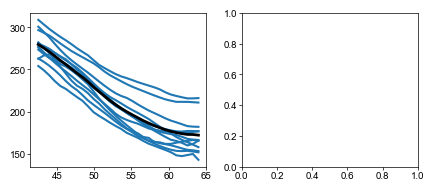

In [41]:
time_phase1_interp_cafree = np.linspace(real_ck1, real_i3, 30)
# time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0 = []
# if_displacement_phase2_interp_wr0 = []
# cp_displacement_phase2_interp_wr0 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in cafree_replicates_info.index:
# for i in[0]:
    print('rep', cafree_replicates_info.rep[i])
    r_0 = cafree_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = cafree_info[i]['data'][0] + r_0
    if_displacement_phase1_newtime = np.linspace(42.5, 64, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp_cafree, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0.append(if_displacement_phase1_new)

    # if_displacement_phase2 = wt_info[i]['data'][1] + r_0
    # if_displacement_phase2_newtime = np.linspace(57, 64, len(if_displacement_phase2))
    # if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    # if_displacement_phase2_interp_wr0.append(if_displacement_phase2_new)
    
    # cp_displacement_phase2 = wt_info[i]['data'][2] + r_0
    # cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    # cp_displacement_phase2_interp_wr0.append(cp_displacement_phase2_new)

    ax.plot(time_phase1_interp_cafree, if_displacement_phase1_new, color='tab:blue')
    # ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    # ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0 = np.array(if_displacement_phase1_interp_wr0)
# if_displacement_phase2_interp_wr0 = np.array(if_displacement_phase2_interp_wr0)
# cp_displacement_phase2_interp_wr0 = np.array(cp_displacement_phase2_interp_wr0)


if_cp_averaged_cafree_w_r0 = []
for list in [if_displacement_phase1_interp_wr0]:
    if_cp_averaged_cafree_w_r0.append(np.average(list, axis=0))
    if_cp_averaged_cafree_w_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp_cafree, if_cp_averaged_cafree_w_r0[0], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0[2], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0[4], color='black', lw=2)

plt.show()

##### average the cafree indentation and invagination (with r_0 and normalized with r_0)

rep 71
rep 73
rep 74
rep 79
rep 81
rep 85
rep 87
rep 88
rep 89
rep 90
rep 91
rep 92


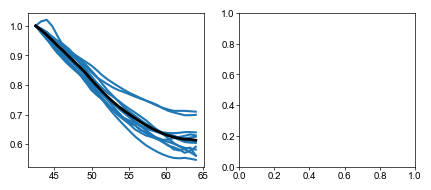

In [42]:
time_phase1_interp_cafree = np.linspace(real_ck1, real_i3, 30)
# time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0_2 = []
# if_displacement_phase2_interp_wr0_2 = []
# cp_displacement_phase2_interp_wr0_2 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in cafree_replicates_info.index:
# for i in[0]:
    print('rep', cafree_replicates_info.rep[i])
    r_0 = cafree_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = cafree_info[i]['data'][0] / r_0 +1
    if_displacement_phase1_newtime = np.linspace(42.5, 64, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp_cafree, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0_2.append(if_displacement_phase1_new)

    # if_displacement_phase2 = wt_info[i]['data'][1] / r_0 +1
    # if_displacement_phase2_newtime = np.linspace(57, 64, len(if_displacement_phase2))
    # if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    # if_displacement_phase2_interp_wr0_2.append(if_displacement_phase2_new)
    
    # cp_displacement_phase2 = wt_info[i]['data'][2] / r_0 +1
    # cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    # cp_displacement_phase2_interp_wr0_2.append(cp_displacement_phase2_new)


    ax.plot(time_phase1_interp_cafree, if_displacement_phase1_new, color='tab:blue')
    # ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    # ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0_2 = np.array(if_displacement_phase1_interp_wr0_2)
# if_displacement_phase2_interp_wr0_2 = np.array(if_displacement_phase2_interp_wr0_2)
# cp_displacement_phase2_interp_wr0_2 = np.array(cp_displacement_phase2_interp_wr0_2)


if_cp_averaged_cafree_w_r0_2 = []
for list in [if_displacement_phase1_interp_wr0_2]:
    if_cp_averaged_cafree_w_r0_2.append(np.average(list, axis=0))
    if_cp_averaged_cafree_w_r0_2.append(np.std(list, axis=0))

ax.plot(time_phase1_interp_cafree, if_cp_averaged_cafree_w_r0_2[0], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[2], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[4], color='black', lw=2)


plt.show()

##### plot for the paper

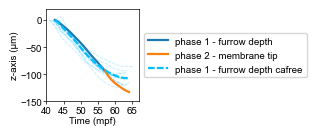

In [43]:
fig, ax = plt.subplots(figsize=[1.2, 1.2])

# plot each individual replicate
for i in wt_replicates_info.index:

    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
    
    lw, alpha = 1,  0.2
    # ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    # ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)

for i in cafree_replicates_info.index:
    # print('rep', replicates_info.rep[i])

    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = cafree_info[i]['data'][:5]
    
    lw, alpha = 0.8,  0.2
    ax.plot(time_phase1, if_displacement_phase1, color='deepskyblue',lw=lw, ls=(0,(3,1)), zorder=-2, alpha=alpha)

# plot the averaged
lw=1.6
ax.plot(time_phase1_interp, if_cp_averaged_wo_r0[0], color='tab:blue', lw=lw, zorder=5, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[2], color='tab:orange', lw=lw, zorder=5, label='phase 2 - membrane tip')
# ax.plot(time_phase2_interp, if_cp_averaged[4], color='tab:green', lw=lw, zorder=2, label='phase 2 - contact point')
# ax.vlines(x=time_phase2_interp, ymin=if_cp_averaged[2], ymax=if_cp_averaged[4], color='tab:orange', lw=lw*0.3, zorder=1, label='phase 2 - contact point')

# plot the averaged cafree
lw=1.6
ax.plot(time_phase1_interp_cafree, if_cp_averaged_cafree_wo_r0[0], color='deepskyblue', lw=lw, ls=(0,(3,1)), zorder=10, label='phase 1 - furrow depth cafree')

# ax.axvline(x = 55, color='r', linestyle='dotted')

# ax.invert_yaxis()
ax.set_ylim(-150, 20)
# ax.set_yticks(np.arange(0, 181, 30)) 
ax.set_xlim(40, 67)
ax.set_xticks(np.arange(40, 70, 5)) 
ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('z-axis (\u03BCm)', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('cafree_furrow_position_1.svg')
plt.show()

##### export h1 h2

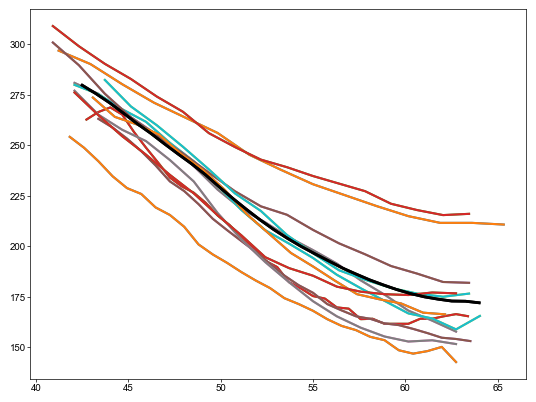

In [44]:
folder = 'furrow_position_cafree_h1h2'
create_folder(folder)

# individual h1 and h2
for i in cafree_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = cafree_info[i]['data'][:5]
    r_0 = cafree_info[i]['data'][11]

    time_phase12 = time_phase1
    h_1 = if_displacement_phase1 + r_0
    h_2 = h_1
    np.save(folder + "\\" + "rep" + str(cafree_info[i]['name']) + "_time_h1_h2.npy", [time_phase12, h_1, h_2])

    plt.plot(time_phase12, h_1)
    plt.plot(time_phase12, h_2)

# averaged h1 and h2
time_phase12 =  time_phase1_interp_cafree
h_1 = if_cp_averaged_cafree_w_r0[0]
h_2 = h_1
np.save(folder + "\\cafree_avg_time_h1_h2.npy", [time_phase12, h_1, h_2])

plt.plot(time_phase12, h_1, color='black', lw=2)
plt.plot(time_phase12, h_2, color='black', lw=2)

##### plot for the paper (fig. 6F')

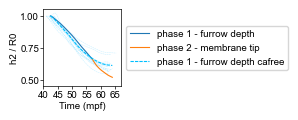

In [45]:

fig, ax = plt.subplots(figsize=[1, 1])

# plot each individual replicate
for i in cafree_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = cafree_info[i]['data'][:5]
    r_0 = cafree_info[i]['data'][11]

    time_phase12 = time_phase1
    h_1 = if_displacement_phase1 + r_0
    h_2 = h_1
    
    lw, alpha = 0.4,  0.2
    ax.plot(time_phase1, h_1/r_0, color='deepskyblue',lw=lw, ls=(0,(3,1)), zorder=-2, alpha=alpha)

# plot the averaged
lw=.8
ax.plot(time_phase1_interp, if_cp_averaged_w_r0_2[0], color='tab:blue', lw=lw, zorder=5, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[2], color='tab:orange', lw=lw, zorder=5, label='phase 2 - membrane tip')
ax.plot(time_phase1_interp_cafree, if_cp_averaged_cafree_w_r0_2[0], color='deepskyblue', lw=lw, ls=(0,(3,1)), zorder=10, label='phase 1 - furrow depth cafree')

ax.set_ylim(0.45, 1.05)
ax.set_xlim(40, 67)
ax.set_xticks(np.arange(40, 70, 5)) 
ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('h2 / R0', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('cafree_furrow_position_2.svg')
plt.show()


In [46]:
# statistics 
from xint_toolbox import find_closest
#cafree at 57mpf
group5 = [(cafree_info[i]['data'][0][find_closest(array=cafree_info[i]['data'][3], target=57)[1]]/cafree_info[i]['data'][11]+1) for i in cafree_replicates_info.index]
#wt phase 1 only
group6 = np.array([wt_info[i]['data'][0][-1]/wt_info[i]['data'][11]+1 for i in wt_replicates_info.index])


testgroup1, testgroup2 = group5, group6
print('--Shapiro-Wilk test for normality--')
stat, p = scipy.stats.shapiro(testgroup1)
print("Control: W=%.3f, p=%.3f" % (stat, p))
stat, p = scipy.stats.shapiro(testgroup2)
print("Control: W=%.3f, p=%.3f" % (stat, p))
# Levene’s test (center='median' is more robust to non-normal data)
stat, p_val = scipy.stats.levene(testgroup1, testgroup2, center='mean')
print('--Levene’s test for variance equity--')
print("Levene’s test statistic =", stat)
print("p-value =", p_val)
# Mann–Whitney U test (two-sided)
u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
print('--Mann-Whitney U test (two-sided)--')
print("Mann–Whitney U statistic =", u_stat)
print("p-value =", p_val)
print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.3f}.")
print(" ")

--Shapiro-Wilk test for normality--
Control: W=0.863, p=0.054
Control: W=0.939, p=0.365
--Levene’s test for variance equity--
Levene’s test statistic = 0.46728116853392
p-value = 0.5005278180638707
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 89.0
p-value = 0.9805355409897708
Statistical test, Mann-Whitney test: p = 0.981.
 


In [47]:
from xint_toolbox import find_closest
# iaa ends
group7 = [(cafree_info[i]['data'][0][-1]/cafree_info[i]['data'][11]+1) for i in cafree_replicates_info.index]
# wt phase 2 ends
group6 = np.array([wt_info[i]['data'][1][-1]/wt_info[i]['data'][11]+1 for i in wt_replicates_info.index])

testgroup1, testgroup2 = group7, group6
print('--Shapiro-Wilk test for normality--')
stat, p = scipy.stats.shapiro(testgroup1)
print("Control: W=%.3f, p=%.3f" % (stat, p))
stat, p = scipy.stats.shapiro(testgroup2)
print("Control: W=%.3f, p=%.3f" % (stat, p))
# Levene’s test (center='median' is more robust to non-normal data)
stat, p_val = scipy.stats.levene(testgroup1, testgroup2, center='mean')
print('--Levene’s test for variance equity--')
print("Levene’s test statistic =", stat)
print("p-value =", p_val)
# Mann–Whitney U test (two-sided)
u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
print('--Mann-Whitney U test (two-sided)--')
print("Mann–Whitney U statistic =", u_stat)
print("p-value =", p_val)
print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.3f}.")
print(" ")

--Shapiro-Wilk test for normality--
Control: W=0.924, p=0.319
Control: W=0.960, p=0.689
--Levene’s test for variance equity--
Levene’s test statistic = 4.9861914283515825
p-value = 0.03474014826742584
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 146.0
p-value = 0.006766500035059635
Statistical test, Mann-Whitney test: p = 0.007.
 


In [48]:
# export for excel fig. 6F'
dfs = []

list1 = time_phase1_interp_cafree
list2 = if_cp_averaged_cafree_w_r0_2[0]
list3 = ['light blue']* len(time_phase1_interp_cafree)
list4 = ['Mean'] * len(list3)
list5 = ['Ca2+-free'] * len(list3)

df = pd.DataFrame({'Type':list5, 'Replicate #': list4, 'Time (mpf)': list1, 'h2 / R0': list2, 'Color illustration (as in the schematics)':list3})
dfs.append(df)

for i in cafree_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = cafree_info[i]['data'][:5]
    r_0 = cafree_info[i]['data'][11]

    time_phase12 = time_phase1
    h_1 = if_displacement_phase1 + r_0
    h_2 = h_1

    list1 = time_phase12
    list2 = h_1/r_0
    list3 = ['light blue']* len(time_phase12)
    list4 = [cafree_info[i]['name']] * len(list3)
    list5 = ['Ca2+-free'] * len(list3)

    df = pd.DataFrame({'Type':list5, 'Replicate #': list4, 'Time (mpf)': list1, 'h2 / R0': list2, 'Color illustration (as in the schematics)':list3})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all
df_all.to_excel('wt_furrow_position_1_excel_fig6fprime.xlsx', index=False)

##### plot for the paper (fig. S6A)

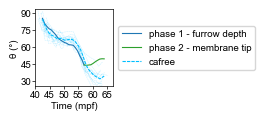

In [49]:
fig, ax = plt.subplots(figsize=[1, 1])

# plot each individual replicate
for i in cafree_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = cafree_info[i]['data'][:5]
    angle_phase1, angle_phase2 = cafree_info[i]['data'][9:11]

    lw, alpha = .4,  0.2
    ax.plot(time_phase1, angle_phase1/2, color='deepskyblue', lw=lw, ls=(0,(3,1)), zorder=-1, alpha=alpha)

# plot the averaged
lw=.8
ax.plot(time_phase1_interp, if_cp_averaged_wo_r0[6]/2, color='tab:blue', lw=lw, zorder=1, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[8]/2, color='tab:green', lw=lw, zorder=1, label='phase 2 - membrane tip')
ax.plot(time_phase1_interp_cafree, if_cp_averaged_cafree_wo_r0[2]/2, color='deepskyblue', ls=(0,(3,1)),lw=lw, zorder=1, label='cafree')

ax.set_ylim(25, 93)
ax.set_yticks(np.arange(30, 91, 15)) 
ax.set_xlim(40, 67)
ax.set_xticks(np.arange(40, 70, 5)) 
ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('θ (°)', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('cafree_furrow_angle.svg')
plt.show()

In [50]:
# export for excel
dfs = []

list1 = time_phase1_interp_cafree
list2 = if_cp_averaged_cafree_wo_r0[2]/2
list3 = ['light blue'] * len(time_phase1_interp_cafree)
list4 = ['Mean'] * len(list3)

df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'Angle (degree)': list2, 'Color illustration (as in the schematics)':list3})
dfs.append(df)

for i in cafree_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = cafree_info[i]['data'][:5]
    angle_phase1, angle_phase2 = cafree_info[i]['data'][9:11]

    list1 = time_phase1
    list2 = angle_phase1/2
    list3 = ['light blue'] * len(time_phase1)
    list4 = [cafree_info[i]['name']] * len(list3)

    df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'Angle (degree)': list2, 'Color illustration (as in the schematics)':list3})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all
df_all.to_excel('cafree_furrow_angle_excel_figs7c.xlsx', index=False)
df_all

,Replicate #,Time (mpf),Angle (degree),Color illustration (as in the schematics)
0,Mean,42.500000,84.381651,light blue
1,Mean,43.241379,79.528372,light blue
2,Mean,43.982759,75.247450,light blue
3,Mean,44.724138,72.434879,light blue
4,Mean,45.465517,70.450426,light blue
...,...,...,...,...
263,92,57.583333,42.980645,light blue
264,92,58.875000,41.594326,light blue
265,92,60.166667,37.856256,light blue
266,92,61.458333,35.776807,light blue


# WT_dmso

##### process the raw data

In [51]:
wtdmso_replicates_info = data_info[data_info['furrow_indentation']=='wtdmso'].reset_index()
display(wtdmso_replicates_info)

,index,rep,experiment,replicate,embryo,type,Unnamed: 5,time_interval,pixel_size,voxel_depth,...,cortical_actin_intensity_quanti1,cortical_actin_intensity_quanti2,geometry,astral_mt_growth,real_i2,real_m2,real_time_interval,real_ck1,real_i3,real_m1
0,150,151,furrow_indentation_and_invagination,wtdmso\xin260303_lsm900up_utrmch_2percentdmso,e1,NaN,NaN,115.75,1.2479,NaN,...,NaN,NaN,NaN,NaN,40.937500,55,1.5625,42.5,64.375,30.0
1,151,152,furrow_indentation_and_invagination,wtdmso\xin260303_lsm900up_utrmch_2percentdmso,e2,NaN,NaN,115.75,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.722222,42.944444,65.333333,NaN
2,152,153,furrow_indentation_and_invagination,wtdmso\xin260303_lsm900up_utrmch_2percentdmso,e3,NaN,NaN,115.89,1.2479,NaN,...,NaN,NaN,NaN,NaN,38.928571,55,1.785714,42.5,65.714286,30.0
3,154,155,furrow_indentation_and_invagination,wtdmso\xin260303_lsm900up_utrmch_2percentdmso,e5,NaN,NaN,116.09,1.2479,NaN,...,NaN,NaN,NaN,NaN,40.714286,55,1.785714,42.5,63.928571,30.0
4,155,156,furrow_indentation_and_invagination,wtdmso\xin260303_lsm900up_utrmch_2percentdmso,e6,NaN,NaN,116.07,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.615385,55,1.923077,43.461538,66.538462,30.0
5,158,159,furrow_indentation_and_invagination,wtdmso\xin260305_lsm900up_utrmch_2percentdmso,e1,NaN,NaN,116.82,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.9375,41.4375,66.625,NaN
6,159,160,furrow_indentation_and_invagination,wtdmso\xin260305_lsm900up_utrmch_2percentdmso,e2,NaN,NaN,116.83,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.722222,42.944444,65.333333,NaN


rep 151


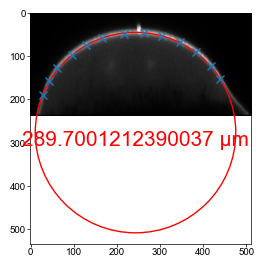

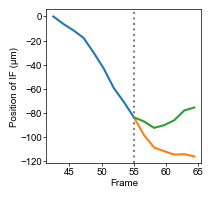

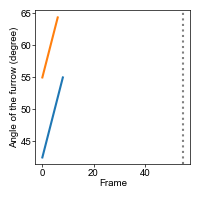

rep 152


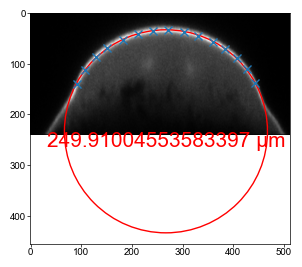

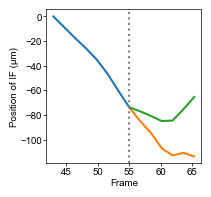

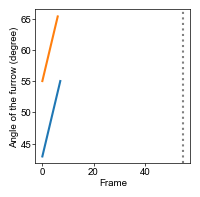

rep 153


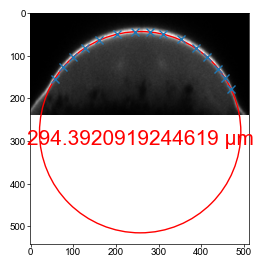

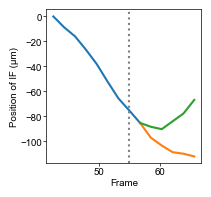

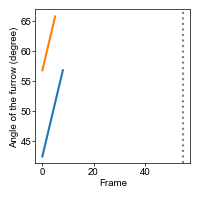

rep 155


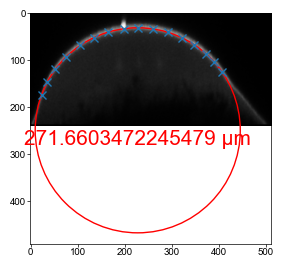

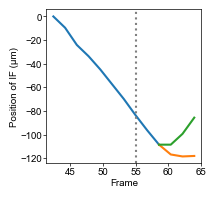

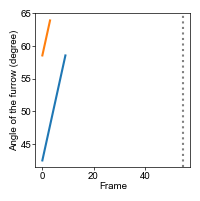

rep 156


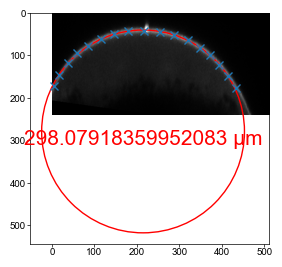

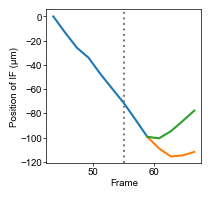

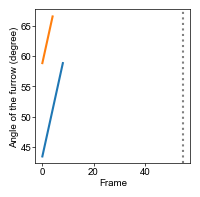

rep 159


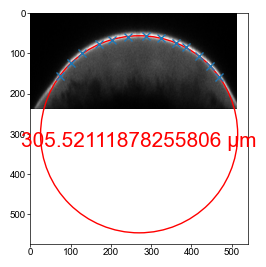

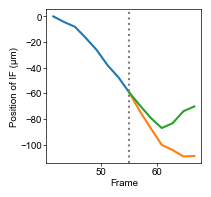

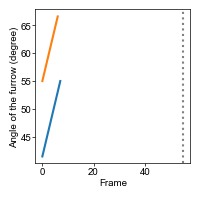

rep 160


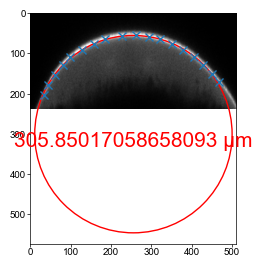

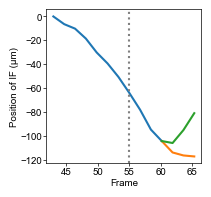

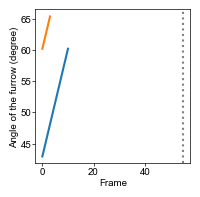

In [52]:
wtdmso_info = []

for i in wtdmso_replicates_info.index[:]:

    replicate = wtdmso_replicates_info.loc[i]
    print('rep', replicate.rep)

    # import the data
    replicate_file_name = replicate.replicate + '\\' + replicate.embryo + '\\mt_cp.csv'
    replicate_mt_cp = pd.read_csv(replicate_file_name)
    if 'Slice' in replicate_mt_cp.columns:
        replicate_mt_cp = replicate_mt_cp.rename({'Slice':'Frame'}, axis='columns')
    replicate_mt_cp = replicate_mt_cp[['X', 'Y', 'Frame']].sort_values(['Frame', 'Y']).reset_index().drop(columns='index')

    # replicate_file_name_angle = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy_angle_measurement.csv'
    # replicate_angle = pd.read_csv(replicate_file_name_angle)['0']

    # basic info
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    m1, i2, ck1, m2, septum1, i3 = replicate.m1, replicate.i2, replicate.ck1, replicate.m2, replicate.septum1, replicate.i3

    # r_0
    replicate_file_name_r0_fit_circle = replicate.replicate + '\\' + replicate.embryo + '\\r0_fit_circle.csv'
    replicate_r0_fit_circle = pd.read_csv(replicate_file_name_r0_fit_circle)[['X', 'Y']]
    circle_points = np.array(replicate_r0_fit_circle) / pixel_size
    fit_circle_xc, fit_circle_yc, fit_circle_r = fit_circle(circle_points)

    movie_sectionmidy = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy.tif'
    movie_sectionmidy = skimage.io.imread(movie_sectionmidy)
    if len(movie_sectionmidy.shape) == 4:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2, 1]
    elif len(movie_sectionmidy.shape) == 3:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2]

    fig,ax=plt.subplots(figsize=[4,3])
    ax.imshow(movie_frame_r0_fit_circle, cmap='Greys_r')
    ax.plot(circle_points[:,0], circle_points[:, 1], 'x')
    circle = mpl.patches.Circle(xy=(fit_circle_xc, fit_circle_yc), radius=fit_circle_r, fill=False, ec='red')
    ax.add_patch(circle)
    ax.text(fit_circle_xc, fit_circle_yc+30, str(fit_circle_r*pixel_size) + ' \u03BCm', color = 'red' , ha = 'center', fontsize=15)
    plt.show()
    r_0 = fit_circle_r*pixel_size

    # indentation and invagination
    if_position_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<septum1].Y.values)
    if_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[1::2])
    if_position_phase2 = np.insert(if_position_phase2, 0, if_position_phase1[-1])
    cp_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[0::2])
    cp_position_phase2 = np.insert(cp_position_phase2, 0, if_position_phase1[-1])

    # angle_phase1 = np.array(replicate_angle[:septum1 - ck1])
    # angle_phase2 = np.array(replicate_angle[septum1 - ck1-1:])
    angle_phase1, angle_phase2 = '', ''

    frame_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<septum1].Frame.values)
    frame_phase2 = np.unique(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Frame.values)
    frame_phase2 = np.insert(frame_phase2, 0, frame_phase1[-1])
    frame_phase12 = np.arange(ck1, i3+1)

    if pd.notna(m1):
        time_phase1 = (frame_phase1 - m2)/(m1-m2)*(30-55) + 55
        time_phase2 = (frame_phase2 - m2)/(m1-m2)*(30-55) + 55
    else:
        time_phase1 = (frame_phase1 - m2)/(i2-m2)*(39.5-55) + 55
        time_phase2 = (frame_phase2 - m2)/(i2-m2)*(39.5-55) + 55
    time_phase12 = np.concatenate([time_phase1, time_phase2[1:]])

    # displacement
    if_displacement_phase1 = if_position_phase1[-1] - if_position_phase1[0]
    if_displacement_phase2 = if_position_phase2[-1] - if_position_phase2[0]

    # speed
    if_speed_phase1 = speed_calculator(time_phase1, if_position_phase1)
    if_speed_phase2 = speed_calculator(time_phase2, if_position_phase2)

    # export the data
    if_position_phase1_normalized = 0-(if_position_phase1 - if_position_phase1[0])
    if_position_phase2_normalized = 0-(if_position_phase2 - if_position_phase1[0])
    cp_position_phase2_normalized = 0-(cp_position_phase2 - if_position_phase1[0])

    replicate_info = {'name': replicate.rep,
                      'data': [if_position_phase1_normalized, if_position_phase2_normalized, cp_position_phase2_normalized, # 0,1,2
                               time_phase1, time_phase2, # 3,4
                               if_displacement_phase1, if_displacement_phase2, # 5,6
                               if_speed_phase1, if_speed_phase2, # 7,8
                               angle_phase1, angle_phase2, # 9,10
                               fit_circle_r*pixel_size # 11
                               ]} 
    
    wtdmso_info.append(replicate_info)

    fig, ax = plt.subplots(figsize=[2,2])
    ax.plot(time_phase1, if_position_phase1_normalized)
    ax.plot(time_phase2, if_position_phase2_normalized)
    ax.plot(time_phase2, cp_position_phase2_normalized)
    ax.axvline(x = 55, color='grey', linestyle='dotted')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Position of IF (\u03BCm)')
    plt.show()

    fig, ax1 = plt.subplots(figsize=[2,2])
    ax1.plot(time_phase1, angle_phase1, color='tab:blue')
    ax1.plot(time_phase2, angle_phase2, color='tab:orange')
    ax1.axvline(x = 55, color='grey', linestyle='dotted')
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Angle of the furrow (degree)')
    plt.show()


##### preview

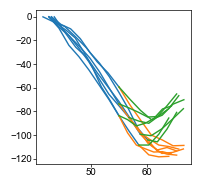

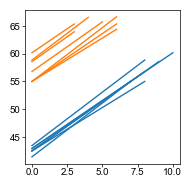

In [53]:
# preview

fig, ax = plt.subplots(figsize=[2,2])
for i in wtdmso_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wtdmso_info[i]['data'][:5]
   
    lw, alpha = 1,  1
    ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

fig, ax1 = plt.subplots(figsize=[2,2])
for i in wtdmso_replicates_info.index:
    time_phase1, time_phase2 = wtdmso_info[i]['data'][3:5]
    angle_phase1, angle_phase2 = wtdmso_info[i]['data'][9:11]
   
    lw, alpha = 1,  1
    ax1.plot(time_phase1, angle_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax1.plot(time_phase2, angle_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
plt.show()

##### preview (together with r_0)

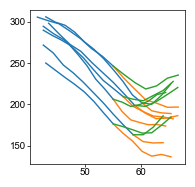

In [54]:
# preview (together with r_0)
fig, ax = plt.subplots(figsize=[2,2])
for i in wtdmso_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wtdmso_info[i]['data'][:5]
    r_0 = wtdmso_info[i]['data'][11]

    lw, alpha = 1,  1
    ax.plot(time_phase1, r_0+if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax.plot(time_phase2, r_0+if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    ax.plot(time_phase2, r_0+cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

##### average the wt indentation and invagination (raw, without r_0)

rep 151
rep 152
rep 153
rep 155
rep 156
rep 159
rep 160


c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\lib\_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


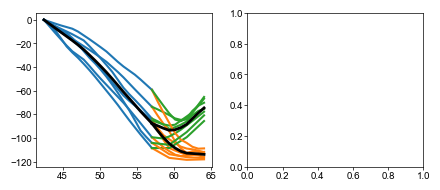

In [55]:
time_phase1_interp = np.linspace(real_ck1, real_septum1, 20)
time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp = []
if_displacement_phase2_interp = []
cp_displacement_phase2_interp = []
angle_phase1_interp = []
angle_phase2_interp = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in wtdmso_replicates_info.index:
# for i in[0]:
    print('rep', wtdmso_replicates_info.rep[i])

    # if interp
    if_displacement_phase1 = wtdmso_info[i]['data'][0]
    if_displacement_phase1_newtime = np.linspace(real_ck1, real_septum1, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp.append(if_displacement_phase1_new)

    if_displacement_phase2 = wtdmso_info[i]['data'][1]
    if_displacement_phase2_newtime = np.linspace(real_septum1, real_i3, len(if_displacement_phase2))
    if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    if_displacement_phase2_interp.append(if_displacement_phase2_new)
    
    cp_displacement_phase2 = wtdmso_info[i]['data'][2]
    cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    cp_displacement_phase2_interp.append(cp_displacement_phase2_new)

    # angle interp
    # angle_phase1 = wtdmso_info[i]['data'][9]
    # angle_phase1_newtime = np.linspace(real_ck1, real_septum1, len(angle_phase1))
    # angle_phase1_new = np.interp(x=time_phase1_interp, xp=angle_phase1_newtime, fp=angle_phase1)
    # angle_phase1_interp.append(angle_phase1_new)

    # angle_phase2 = wtdmso_info[i]['data'][10]
    # angle_phase2_newtime = np.linspace(real_septum1, real_i3, len(angle_phase2))
    # angle_phase2_new = np.interp(x=time_phase2_interp, xp=angle_phase2_newtime, fp=angle_phase2)
    # angle_phase2_interp.append(angle_phase2_new)

    ax.plot(time_phase1_interp, if_displacement_phase1_new, color='tab:blue')
    ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')

    # ax1.plot(time_phase1_interp, angle_phase1_new, color='tab:blue')
    # ax1.plot(time_phase2_interp, angle_phase2_new, color='tab:orange')

if_displacement_phase1_interp = np.array(if_displacement_phase1_interp)
if_displacement_phase2_interp = np.array(if_displacement_phase2_interp)
cp_displacement_phase2_interp = np.array(cp_displacement_phase2_interp)

angle_phase1_interp = np.array(angle_phase1_interp)
angle_phase2_interp = np.array(angle_phase2_interp)

if_cp_averaged_wtdmso_wo_r0 = []
for list in [if_displacement_phase1_interp, if_displacement_phase2_interp, cp_displacement_phase2_interp, angle_phase1_interp, angle_phase2_interp]:
    if_cp_averaged_wtdmso_wo_r0.append(np.average(list, axis=0))
    if_cp_averaged_wtdmso_wo_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp, if_cp_averaged_wtdmso_wo_r0[0], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[2], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[4], color='black', lw=2)

# ax1.plot(time_phase1_interp, if_cp_averaged_wtdmso_wo_r0[6], color='black', lw=2)
# ax1.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[8], color='black', lw=2)

plt.show()


##### average the wt indentation and invagination (raw, without r_0, a second strategy)

rep 151
rep 152
rep 153
rep 155
rep 156
rep 159
rep 160


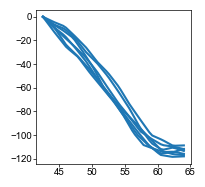

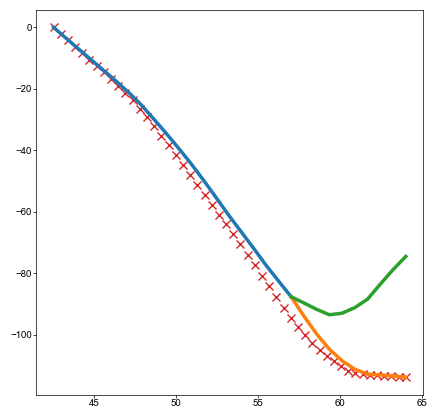

In [56]:
time_phase12_interp = np.linspace(real_ck1, real_i3, 50)

if_displacement_phase12_interp = []

fig, ax =plt.subplots(figsize=[2,2])

for i in wtdmso_replicates_info.index:
    print('rep', wtdmso_replicates_info.rep[i])

    # if_displacement_phase1
    if_displacement_phase1 = wtdmso_info[i]['data'][0]
    if_displacement_phase2 = wtdmso_info[i]['data'][1]

    if_displacement_phase12 = np.concatenate([if_displacement_phase1[:-1], if_displacement_phase2])
    if_displacement_phase12_new = np.interp(x=time_phase12_interp, xp=np.linspace(real_ck1, real_i3, len(if_displacement_phase12)), fp=if_displacement_phase12)
    if_displacement_phase12_interp.append(if_displacement_phase12_new)

    ax.plot(time_phase12_interp, if_displacement_phase12_new, color='tab:blue')
plt.show()

if_cp_averaged_wtdmso_wo_r0_2 = []
for list in [if_displacement_phase12_interp]:
    if_cp_averaged_wtdmso_wo_r0_2.append(np.average(list, axis=0))
    if_cp_averaged_wtdmso_wo_r0_2.append(np.std(list, axis=0))

# compare it with the first strategy

fig, ax = plt.subplots(figsize=[5,5])
lw=2.5
ax.plot(time_phase1_interp, if_cp_averaged_wtdmso_wo_r0[0], color='tab:blue', lw=lw, zorder=1, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[2], color='tab:orange', lw=lw, zorder=1, label='phase 2 - membrane tip')
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[4], color='tab:green', lw=lw, zorder=1, label='phase 2 - contact point')
ax.plot(time_phase12_interp, if_cp_averaged_wtdmso_wo_r0_2[0], 'x', color='tab:red', lw=lw, zorder=-1, label='phase 2 - contact point')
plt.show()

##### average the wt indentation and invagination (with r_0, but not normalized with r_0)

rep 151
rep 152
rep 153
rep 155
rep 156
rep 159
rep 160


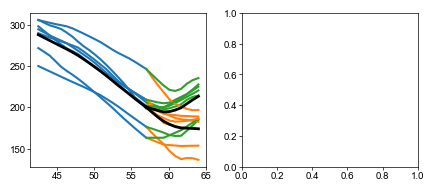

In [57]:
time_phase1_interp = np.linspace(real_ck1, real_septum1, 20)
time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0 = []
if_displacement_phase2_interp_wr0 = []
cp_displacement_phase2_interp_wr0 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in wtdmso_replicates_info.index:
# for i in[0]:
    print('rep', wtdmso_replicates_info.rep[i])
    r_0 = wtdmso_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = wtdmso_info[i]['data'][0] + r_0
    if_displacement_phase1_newtime = np.linspace(real_ck1, real_septum1, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0.append(if_displacement_phase1_new)

    if_displacement_phase2 = wtdmso_info[i]['data'][1] + r_0
    if_displacement_phase2_newtime = np.linspace(real_septum1, real_i3, len(if_displacement_phase2))
    if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    if_displacement_phase2_interp_wr0.append(if_displacement_phase2_new)
    
    cp_displacement_phase2 = wtdmso_info[i]['data'][2] + r_0
    cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    cp_displacement_phase2_interp_wr0.append(cp_displacement_phase2_new)


    ax.plot(time_phase1_interp, if_displacement_phase1_new, color='tab:blue')
    ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0 = np.array(if_displacement_phase1_interp_wr0)
if_displacement_phase2_interp_wr0 = np.array(if_displacement_phase2_interp_wr0)
cp_displacement_phase2_interp_wr0 = np.array(cp_displacement_phase2_interp_wr0)


if_cp_averaged_wtdmso_w_r0 = []
for list in [if_displacement_phase1_interp_wr0, if_displacement_phase2_interp_wr0, cp_displacement_phase2_interp_wr0]:
    if_cp_averaged_wtdmso_w_r0.append(np.average(list, axis=0))
    if_cp_averaged_wtdmso_w_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp, if_cp_averaged_wtdmso_w_r0[0], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_w_r0[2], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_w_r0[4], color='black', lw=2)

plt.show()

##### average the wt indentation and invagination (with r_0 and normalized with r_0)

rep 151
rep 152
rep 153
rep 155
rep 156
rep 159
rep 160


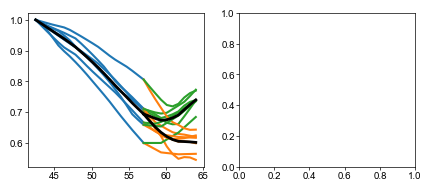

In [58]:
time_phase1_interp = np.linspace(real_ck1, real_septum1, 20)
time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0_2 = []
if_displacement_phase2_interp_wr0_2 = []
cp_displacement_phase2_interp_wr0_2 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in wtdmso_replicates_info.index:
# for i in[0]:
    print('rep', wtdmso_replicates_info.rep[i])
    r_0 = wtdmso_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = wtdmso_info[i]['data'][0] / r_0 +1
    if_displacement_phase1_newtime = np.linspace(real_ck1, real_septum1, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0_2.append(if_displacement_phase1_new)

    if_displacement_phase2 = wtdmso_info[i]['data'][1] / r_0 +1
    if_displacement_phase2_newtime = np.linspace(real_septum1, real_i3, len(if_displacement_phase2))
    if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    if_displacement_phase2_interp_wr0_2.append(if_displacement_phase2_new)
    
    cp_displacement_phase2 = wtdmso_info[i]['data'][2] / r_0 +1
    cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    cp_displacement_phase2_interp_wr0_2.append(cp_displacement_phase2_new)


    ax.plot(time_phase1_interp, if_displacement_phase1_new, color='tab:blue')
    ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0_2 = np.array(if_displacement_phase1_interp_wr0_2)
if_displacement_phase2_interp_wr0_2 = np.array(if_displacement_phase2_interp_wr0_2)
cp_displacement_phase2_interp_wr0_2 = np.array(cp_displacement_phase2_interp_wr0_2)


if_cp_averaged_w_wtdmso_r0_2 = []
for list in [if_displacement_phase1_interp_wr0_2, if_displacement_phase2_interp_wr0_2, cp_displacement_phase2_interp_wr0_2]:
    if_cp_averaged_w_wtdmso_r0_2.append(np.average(list, axis=0))
    if_cp_averaged_w_wtdmso_r0_2.append(np.std(list, axis=0))

ax.plot(time_phase1_interp, if_cp_averaged_w_wtdmso_r0_2[0], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_w_wtdmso_r0_2[2], color='black', lw=2)
ax.plot(time_phase2_interp, if_cp_averaged_w_wtdmso_r0_2[4], color='black', lw=2)


plt.show()

##### plot for the paper (fig. X)

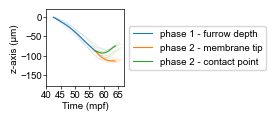

In [59]:
fig, ax = plt.subplots(figsize=[1, 1])

# plot each individual replicate
for i in wtdmso_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wtdmso_info[i]['data'][:5]
    
    lw, alpha = 0.4,  0.2
    ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)

# plot the averaged
lw=0.8
ax.plot(time_phase1_interp, if_cp_averaged_wtdmso_wo_r0[0], color='tab:blue', lw=lw, zorder=1, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[2], color='tab:orange', lw=lw, zorder=1, label='phase 2 - membrane tip')
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[4], color='tab:green', lw=lw, zorder=2, label='phase 2 - contact point')

ax.set_ylim(-180, 20)
ax.set_yticks(np.arange(0, -151, -50)) 
ax.set_xlim(40, 67)
ax.set_xticks(np.arange(40, 70, 5)) 
ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('z-axis (\u03BCm)', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)

# plt.savefig('wt_furrow_position_1.svg')
plt.show()

# Indole 3-acetic acid

##### process the raw data

In [60]:
iaa_replicates_info = data_info[data_info['furrow_indentation']=='iaa'].reset_index()
display(iaa_replicates_info)

,index,rep,experiment,replicate,embryo,type,Unnamed: 5,time_interval,pixel_size,voxel_depth,...,cortical_actin_intensity_quanti1,cortical_actin_intensity_quanti2,geometry,astral_mt_growth,real_i2,real_m2,real_time_interval,real_ck1,real_i3,real_m1
0,94,95,furrow_indentation_and_invagination,iaa\xin260212_lsm900up_utrmch_iaa,e1,NaN,NaN,116.48,1.2479,NaN,...,NaN,NaN,NaN,NaN,40.937500,55,1.5625,42.5,65.9375,30.0
1,95,96,furrow_indentation_and_invagination,iaa\xin260212_lsm900up_utrmch_iaa,e2,NaN,NaN,116.48,1.2479,NaN,...,NaN,NaN,NaN,NaN,40.294118,55,1.470588,41.764706,66.764706,30.0
2,99,100,furrow_indentation_and_invagination,iaa\xin260224_lsm900up_utrmch_iaa,e2,NaN,NaN,116.07,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.55,42.6,67.4,NaN
3,102,103,furrow_indentation_and_invagination,iaa\xin260225_lsm900up_utrmch_iaa,e1,NaN,NaN,115.98,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.722222,42.944444,68.777778,NaN
4,103,104,furrow_indentation_and_invagination,iaa\xin260225_lsm900up_utrmch_iaa,e2,NaN,NaN,115.98,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,1.55,42.6,68.95,NaN
5,104,105,furrow_indentation_and_invagination,iaa\xin260225_lsm900up_utrmch_iaa,e3,NaN,NaN,115.62,1.2479,NaN,...,NaN,NaN,NaN,NaN,40.937500,55,1.5625,44.0625,67.5,30.0
6,105,106,furrow_indentation_and_invagination,iaa\xin260225_lsm900up_utrmch_iaa,e4,NaN,NaN,115.62,1.2479,NaN,...,NaN,NaN,NaN,NaN,40.000000,55,1.666667,43.333333,68.333333,30.0
7,106,107,furrow_indentation_and_invagination,iaa\xin260311_lsm900up_utrmch_iaa,e1,NaN,NaN,116.25,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.375000,55,1.5625,42.5,65.9375,30.0
8,107,108,furrow_indentation_and_invagination,iaa\xin260311_lsm900up_utrmch_iaa,e2,NaN,NaN,116.26,1.2479,NaN,...,NaN,NaN,NaN,NaN,38.823529,55,1.470588,41.764706,65.294118,30.0
9,108,109,furrow_indentation_and_invagination,iaa\xin260311_lsm900up_utrmch_iaa,e3,NaN,NaN,116.30,1.2479,NaN,...,NaN,NaN,NaN,NaN,40.000000,55,1.666667,43.333333,65.0,30.0


rep 95


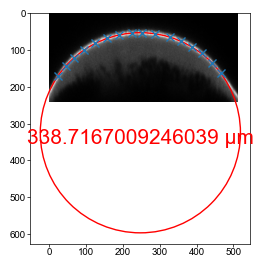

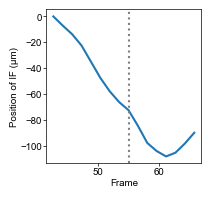

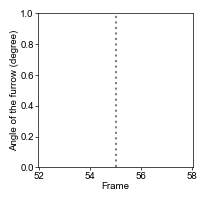

rep 96


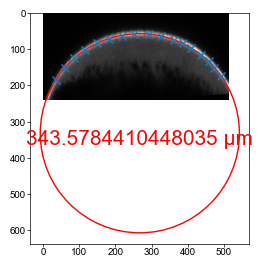

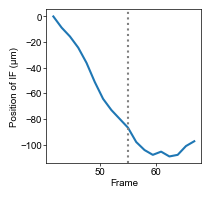

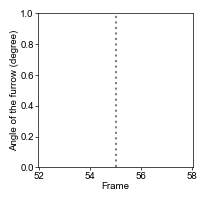

rep 100


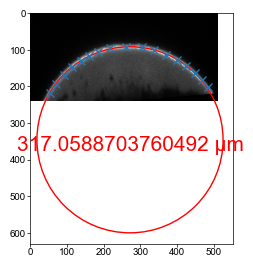

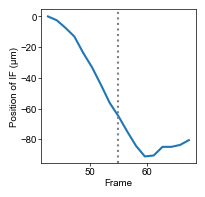

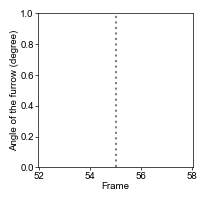

rep 103


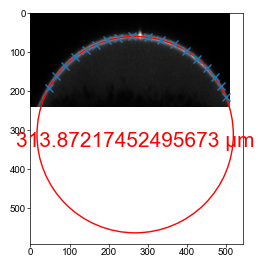

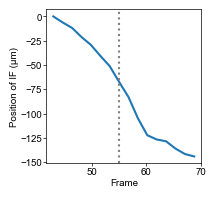

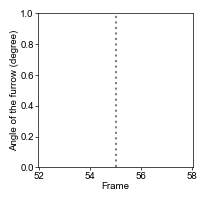

rep 104


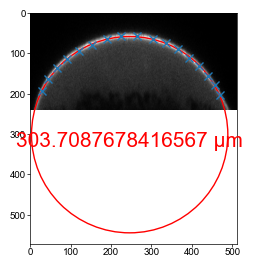

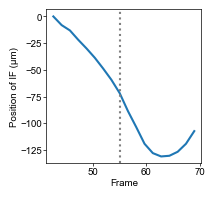

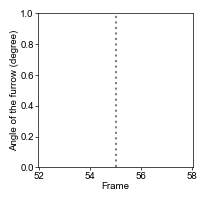

rep 105


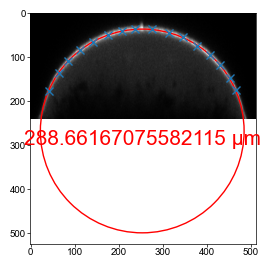

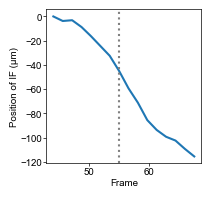

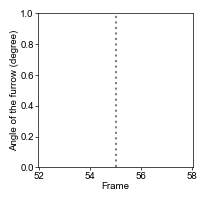

rep 106


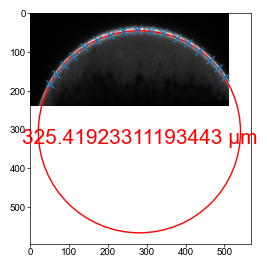

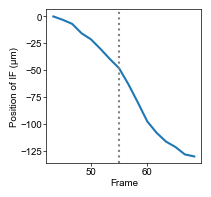

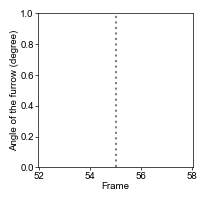

rep 107


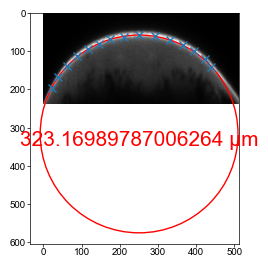

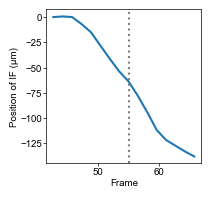

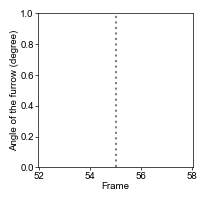

rep 108


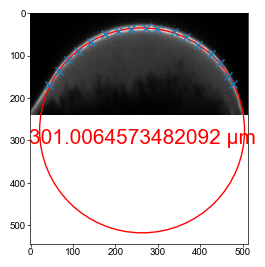

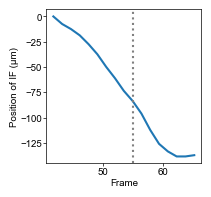

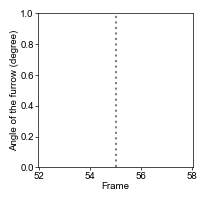

rep 109


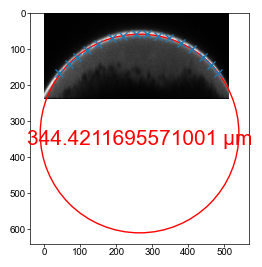

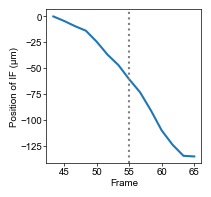

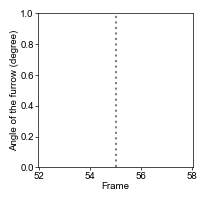

rep 110


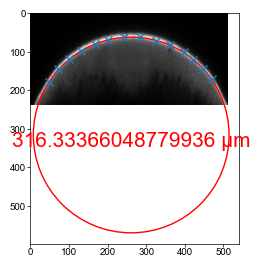

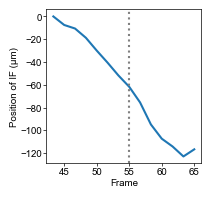

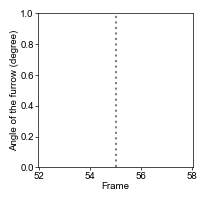

rep 127


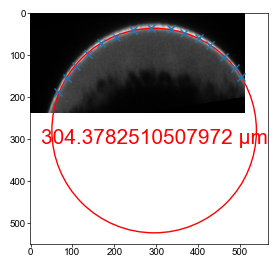

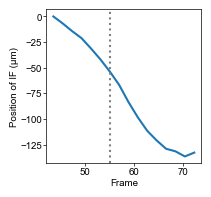

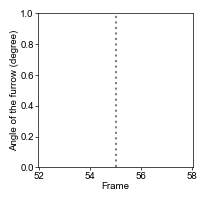

rep 128


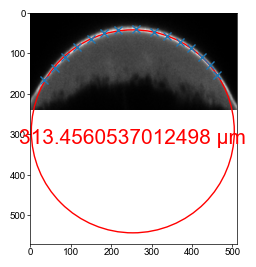

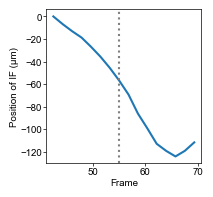

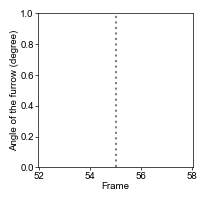

In [61]:
iaa_info = []

for i in iaa_replicates_info.index:

    replicate = iaa_replicates_info.loc[i]
    print('rep', replicate.rep)

    # import the data
    replicate_file_name = replicate.replicate + '\\' + replicate.embryo + '\\furrowtip.csv'
    replicate_mt_cp = pd.read_csv(replicate_file_name)
    if 'Slice' in replicate_mt_cp.columns:
        replicate_mt_cp = replicate_mt_cp.rename({'Slice':'Frame'}, axis='columns')
    replicate_mt_cp = replicate_mt_cp[['X', 'Y', 'Frame']].sort_values(['Frame', 'Y']).reset_index().drop(columns='index')

    replicate_file_name_angle = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy_angle_measurement.csv'
    # replicate_angle = pd.read_csv(replicate_file_name_angle)['0']

    # basic info
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    m1, i2, ck1, m2, septum1, i3 = replicate.m1, replicate.i2, replicate.ck1, replicate.m2, replicate.septum1, replicate.i3

    # r_0
    replicate_file_name_r0_fit_circle = replicate.replicate + '\\' + replicate.embryo + '\\r0_fit_circle.csv'
    replicate_r0_fit_circle = pd.read_csv(replicate_file_name_r0_fit_circle)[['X', 'Y']]
    circle_points = np.array(replicate_r0_fit_circle) / pixel_size
    fit_circle_xc, fit_circle_yc, fit_circle_r = fit_circle(circle_points)

    movie_sectionmidy = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy.tif'
    movie_sectionmidy = skimage.io.imread(movie_sectionmidy)
    if len(movie_sectionmidy.shape) == 4:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2, 1]
    elif len(movie_sectionmidy.shape) == 3:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2]

    fig,ax=plt.subplots(figsize=[4,3])
    ax.imshow(movie_frame_r0_fit_circle, cmap='Greys_r')
    ax.plot(circle_points[:,0], circle_points[:, 1], 'x')
    circle = mpl.patches.Circle(xy=(fit_circle_xc, fit_circle_yc), radius=fit_circle_r, fill=False, ec='red')
    ax.add_patch(circle)
    ax.text(fit_circle_xc, fit_circle_yc+30, str(fit_circle_r*pixel_size) + ' \u03BCm', color = 'red' , ha = 'center', fontsize=15)
    plt.show()
    r_0 = fit_circle_r*pixel_size

    # indentation and invagination
    if_position_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<500].Y.values)
    # if_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[1::2])
    # if_position_phase2 = np.insert(if_position_phase2, 0, if_position_phase1[-1])
    # cp_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[0::2])
    # cp_position_phase2 = np.insert(cp_position_phase2, 0, if_position_phase1[-1])

    # angle_phase1 = np.array(replicate_angle[:])
    # angle_phase2 = np.array(replicate_angle[septum1 - ck1-1:])

    frame_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<500].Frame.values)
    # frame_phase2 = np.unique(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Frame.values)
    # frame_phase2 = np.insert(frame_phase2, 0, frame_phase1[-1])
    # frame_phase12 = np.arange(ck1, i3+1)
    if pd.isna(m1):
        time_phase1 = (frame_phase1 - m2)/(i2-m2)*(39.5-55) + 55
    else:
        time_phase1 = (frame_phase1 - m2)/(m1-m2)*(30-55) + 55
    # time_phase2 = (frame_phase2 - m2)/(m1-m2)*(30-55) + 55
    # time_phase12 = np.concatenate([time_phase1, time_phase2[1:]])

    # displacement
    if_displacement_phase1 = if_position_phase1[-1] - if_position_phase1[0]
    # if_displacement_phase2 = if_position_phase2[-1] - if_position_phase2[0]

    # # speed
    # if_speed_phase1 = speed_calculator(time_phase1, if_position_phase1)
    # if_speed_phase2 = speed_calculator(time_phase2, if_position_phase2)

    # export the data
    if_position_phase1_normalized = 0-(if_position_phase1 - if_position_phase1[0])
    # if_position_phase2_normalized = 0-(if_position_phase2 - if_position_phase1[0])
    # cp_position_phase2_normalized = 0-(cp_position_phase2 - if_position_phase1[0])

    replicate_info = {'name': replicate.rep,
                      'data': [if_position_phase1_normalized, _, _, # 0,1,2
                               time_phase1, _, # 3,4
                               if_displacement_phase1, _, # 5,6
                               _, _, # 7,8
                               _, _, # 9,10
                               fit_circle_r*pixel_size # 11
                               ]} 
    
    iaa_info.append(replicate_info)

    fig, ax = plt.subplots(figsize=[2,2])
    ax.plot(time_phase1, if_position_phase1_normalized)
    # ax.plot(time_phase2, if_position_phase2_normalized)
    # ax.plot(time_phase2, cp_position_phase2_normalized)
    ax.axvline(x = 55, color='grey', linestyle='dotted')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Position of IF (\u03BCm)')
    plt.show()

    fig, ax1 = plt.subplots(figsize=[2,2])
    # ax1.plot(time_phase1, angle_phase1, color='tab:blue')
    # ax1.plot(time_phase2, angle_phase2, color='tab:orange')
    ax1.axvline(x = 55, color='grey', linestyle='dotted')
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Angle of the furrow (degree)')
    plt.show()


##### preview

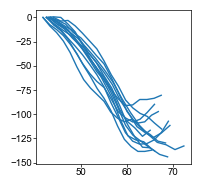

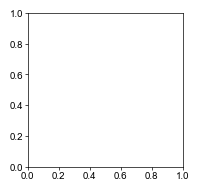

In [62]:
fig, ax = plt.subplots(figsize=[2,2])
for i in iaa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = iaa_info[i]['data'][:5]
   
    lw, alpha = 1,  1
    ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    # ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

fig, ax1 = plt.subplots(figsize=[2,2])
for i in iaa_replicates_info.index:
    time_phase1, time_phase2 = iaa_info[i]['data'][3:5]
    angle_phase1, angle_phase2 = iaa_info[i]['data'][9:11]
   
    lw, alpha = 1,  1
    # ax1.plot(time_phase1, angle_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax1.plot(time_phase2, angle_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
plt.show()

##### preview (together with r_0)

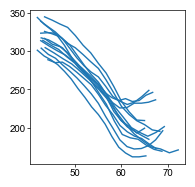

In [63]:
fig, ax = plt.subplots(figsize=[2,2])
for i in iaa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = iaa_info[i]['data'][:5]
    r_0 = iaa_info[i]['data'][11]

    lw, alpha = 1,  1
    ax.plot(time_phase1, r_0+if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax.plot(time_phase2, r_0+if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    # ax.plot(time_phase2, r_0+cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

##### average the iaa indentation (raw, without r_0)

rep 95
rep 96
rep 100
rep 103
rep 104
rep 105
rep 106
rep 107
rep 108
rep 109
rep 110
rep 127
rep 128


c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\lib\_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


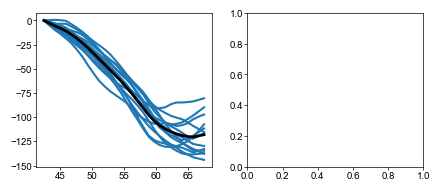

In [64]:
real_i3_iaa = 67.5

time_phase1_interp_iaa = np.linspace(real_ck1, real_i3_iaa, 30)
# time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp = []
# if_displacement_phase2_interp = []
# cp_displacement_phase2_interp = []
angle_phase1_interp = []
# angle_phase2_interp = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in iaa_replicates_info.index:
# for i in[0]:
    print('rep', iaa_replicates_info.rep[i])

    # if interp
    if_displacement_phase1 = iaa_info[i]['data'][0]
    if_displacement_phase1_newtime = np.linspace(42.5, real_i3_iaa, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp_iaa, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp.append(if_displacement_phase1_new)

    # if_displacement_phase2 = wt_info[i]['data'][1]
    # if_displacement_phase2_newtime = np.linspace(57, 64, len(if_displacement_phase2))
    # if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    # if_displacement_phase2_interp.append(if_displacement_phase2_new)
    
    # cp_displacement_phase2 = wt_info[i]['data'][2]
    # cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    # cp_displacement_phase2_interp.append(cp_displacement_phase2_new)

    # angle interp
    # angle_phase1 = iaa_info[i]['data'][9]
    # angle_phase1_newtime = np.linspace(42.5, real_i3_iaa, len(angle_phase1))
    # angle_phase1_new = np.interp(x=time_phase1_interp_iaa, xp=angle_phase1_newtime, fp=angle_phase1)
    # angle_phase1_interp.append(angle_phase1_new)

    # angle_phase2 = wt_info[i]['data'][10]
    # angle_phase2_newtime = np.linspace(57, 64, len(angle_phase2))
    # angle_phase2_new = np.interp(x=time_phase2_interp, xp=angle_phase2_newtime, fp=angle_phase2)
    # angle_phase2_interp.append(angle_phase2_new)

    ax.plot(time_phase1_interp_iaa, if_displacement_phase1_new, color='tab:blue')
    # ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    # ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')

    # ax1.plot(time_phase1_interp_iaa, angle_phase1_new, color='tab:blue')
    # ax1.plot(time_phase2_interp, angle_phase2_new, color='tab:orange')

if_displacement_phase1_interp = np.array(if_displacement_phase1_interp)
# if_displacement_phase2_interp = np.array(if_displacement_phase2_interp)
# cp_displacement_phase2_interp = np.array(cp_displacement_phase2_interp)

angle_phase1_interp = np.array(angle_phase1_interp)
# angle_phase2_interp = np.array(angle_phase2_interp)

if_cp_averaged_iaa_wo_r0 = []
for list in [if_displacement_phase1_interp, angle_phase1_interp]:
    if_cp_averaged_iaa_wo_r0.append(np.average(list, axis=0))
    if_cp_averaged_iaa_wo_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp_iaa, if_cp_averaged_iaa_wo_r0[0], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[2], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[4], color='black', lw=2)

# ax1.plot(time_phase1_interp_iaa, if_cp_averaged_iaa_wo_r0[2], color='black', lw=2)
# ax1.plot(time_phase2_interp, if_cp_averaged_wo_r0[8], color='black', lw=2)

plt.show()

##### average the iaa indentation and invagination (with r_0, but not normalized with r_0)

rep 95
rep 96
rep 100
rep 103
rep 104
rep 105
rep 106
rep 107
rep 108
rep 109
rep 110
rep 127
rep 128


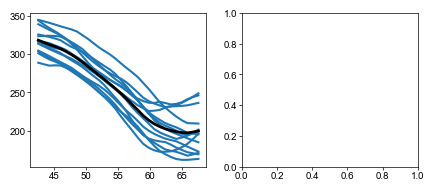

In [65]:
time_phase1_interp_iaa = np.linspace(real_ck1, real_i3_iaa, 30)
# time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0 = []
# if_displacement_phase2_interp_wr0 = []
# cp_displacement_phase2_interp_wr0 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in iaa_replicates_info.index:
# for i in[0]:
    print('rep', iaa_replicates_info.rep[i])
    r_0 = iaa_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = iaa_info[i]['data'][0] + r_0
    if_displacement_phase1_newtime = np.linspace(42.5, real_i3_iaa, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp_iaa, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0.append(if_displacement_phase1_new)

    # if_displacement_phase2 = wt_info[i]['data'][1] + r_0
    # if_displacement_phase2_newtime = np.linspace(57, 64, len(if_displacement_phase2))
    # if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    # if_displacement_phase2_interp_wr0.append(if_displacement_phase2_new)
    
    # cp_displacement_phase2 = wt_info[i]['data'][2] + r_0
    # cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    # cp_displacement_phase2_interp_wr0.append(cp_displacement_phase2_new)

    ax.plot(time_phase1_interp_iaa, if_displacement_phase1_new, color='tab:blue')
    # ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    # ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0 = np.array(if_displacement_phase1_interp_wr0)
# if_displacement_phase2_interp_wr0 = np.array(if_displacement_phase2_interp_wr0)
# cp_displacement_phase2_interp_wr0 = np.array(cp_displacement_phase2_interp_wr0)


if_cp_averaged_iaa_w_r0 = []
for list in [if_displacement_phase1_interp_wr0]:
    if_cp_averaged_iaa_w_r0.append(np.average(list, axis=0))
    if_cp_averaged_iaa_w_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp_iaa, if_cp_averaged_iaa_w_r0[0], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0[2], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0[4], color='black', lw=2)

plt.show()

##### average the iaa indentation and invagination (with r_0 and normalized with r_0)

rep 95
rep 96
rep 100
rep 103
rep 104
rep 105
rep 106
rep 107
rep 108
rep 109
rep 110
rep 127
rep 128


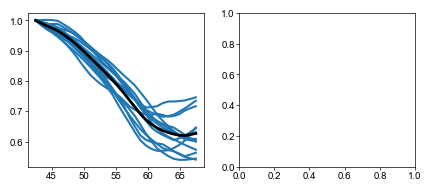

In [66]:
time_phase1_interp_iaa = np.linspace(real_ck1, real_i3_iaa, 30)
# time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0_2 = []
# if_displacement_phase2_interp_wr0_2 = []
# cp_displacement_phase2_interp_wr0_2 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in iaa_replicates_info.index:
# for i in[0]:
    print('rep', iaa_replicates_info.rep[i])
    r_0 = iaa_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = iaa_info[i]['data'][0] / r_0 +1
    if_displacement_phase1_newtime = np.linspace(42.5, real_i3_iaa, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp_iaa, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0_2.append(if_displacement_phase1_new)

    # if_displacement_phase2 = wt_info[i]['data'][1] / r_0 +1
    # if_displacement_phase2_newtime = np.linspace(57, 64, len(if_displacement_phase2))
    # if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    # if_displacement_phase2_interp_wr0_2.append(if_displacement_phase2_new)
    
    # cp_displacement_phase2 = wt_info[i]['data'][2] / r_0 +1
    # cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    # cp_displacement_phase2_interp_wr0_2.append(cp_displacement_phase2_new)


    ax.plot(time_phase1_interp_iaa, if_displacement_phase1_new, color='tab:blue')
    # ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    # ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0_2 = np.array(if_displacement_phase1_interp_wr0_2)
# if_displacement_phase2_interp_wr0_2 = np.array(if_displacement_phase2_interp_wr0_2)
# cp_displacement_phase2_interp_wr0_2 = np.array(cp_displacement_phase2_interp_wr0_2)


if_cp_averaged_iaa_w_r0_2 = []
for list in [if_displacement_phase1_interp_wr0_2]:
    if_cp_averaged_iaa_w_r0_2.append(np.average(list, axis=0))
    if_cp_averaged_iaa_w_r0_2.append(np.std(list, axis=0))

ax.plot(time_phase1_interp_iaa, if_cp_averaged_iaa_w_r0_2[0], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[2], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[4], color='black', lw=2)


plt.show()

##### plot for the paper

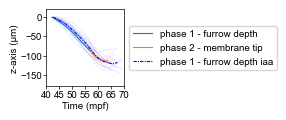

In [67]:
fig, ax = plt.subplots(figsize=[1,1])

# plot each individual replicate
for i in wtdmso_replicates_info.index:

    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wtdmso_info[i]['data'][:5]
    
    lw, alpha = 0.4, 0.2
    ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    # ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)

for i in iaa_replicates_info.index:
    # print('rep', replicates_info.rep[i])

    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = iaa_info[i]['data'][:5]
    
    lw, alpha = 0.4,  0.2
    ax.plot(time_phase1, if_displacement_phase1, color='blue',lw=lw, ls=(0,(3,1,1,1)), zorder=-2, alpha=alpha)

# plot the averaged
lw=.8
ax.plot(time_phase1_interp, if_cp_averaged_wtdmso_wo_r0[0], color='tab:blue', lw=lw, zorder=5, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[2], color='tab:orange', lw=lw, zorder=5, label='phase 2 - membrane tip')
# ax.plot(time_phase2_interp, if_cp_averaged[4], color='tab:green', lw=lw, zorder=2, label='phase 2 - contact point')
# ax.vlines(x=time_phase2_interp, ymin=if_cp_averaged[2], ymax=if_cp_averaged[4], color='tab:orange', lw=lw*0.3, zorder=1, label='phase 2 - contact point')

# plot the averaged iaa
lw=.8
ax.plot(time_phase1_interp_iaa, if_cp_averaged_iaa_wo_r0[0], color='blue', lw=lw, ls=(0,(3,1,1,1)), zorder=10, label='phase 1 - furrow depth iaa')

# ax.axvline(x = 55, color='r', linestyle='dotted')

ax.set_ylim(-180, 20)
ax.set_yticks(np.arange(0, -151, -50)) 
ax.set_xlim(40, 70)
ax.set_xticks(np.arange(40, 71, 5)) 

ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('z-axis (\u03BCm)', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('iaa_furrow_position_1.svg')
plt.show()

In [68]:
# u_stat, p_val = scipy.stats.mannwhitneyu(wt_final, iaa_final, alternative='two-sided')
# print('--Mann-Whitney U test (two-sided)--')
# print("Mann–Whitney U statistic =", u_stat)
# print("p-value =", p_val)
# print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.3f}.")
# print(" ")

##### export h1 h2

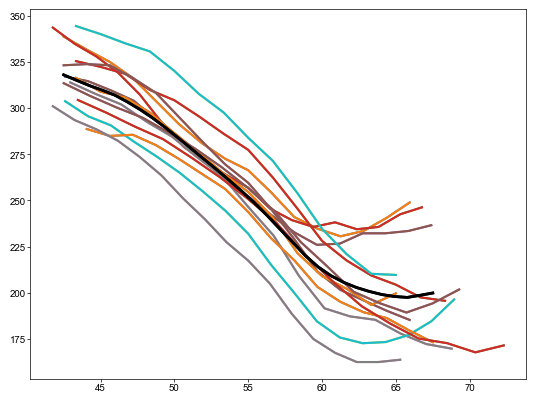

In [69]:
folder = 'furrow_position_iaa_h1h2'
create_folder(folder)

# individual h1 and h2
for i in iaa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = iaa_info[i]['data'][:5]
    r_0 = iaa_info[i]['data'][11]

    time_phase12 = time_phase1
    h_1 = if_displacement_phase1 + r_0
    h_2 = h_1
    np.save(folder + "\\" + "rep" + str(iaa_info[i]['name']) + "_time_h1_h2.npy", [time_phase12, h_1, h_2])

    plt.plot(time_phase12, h_1)
    plt.plot(time_phase12, h_2)

# averaged h1 and h2
time_phase12 =  time_phase1_interp_iaa
h_1 = if_cp_averaged_iaa_w_r0[0]
h_2 = h_1
np.save(folder + "\\iaa_avg_time_h1_h2.npy", [time_phase12, h_1, h_2])

plt.plot(time_phase12, h_1, color='black', lw=2)
plt.plot(time_phase12, h_2, color='black', lw=2)

# Plot wt, wtdmso, cafree, iaa

## h2/R0 of wt, wtdmso, cafree, iaa

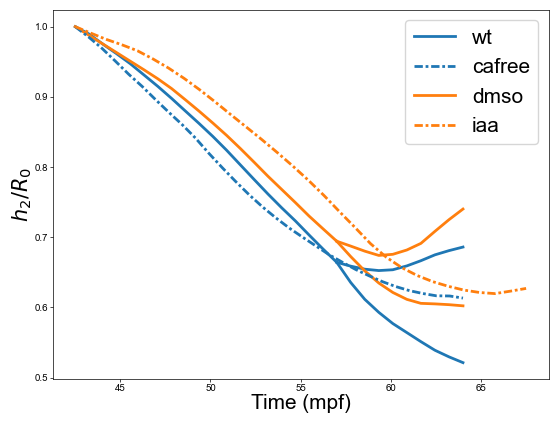

In [70]:
fig, ax = plt.subplots()
lw=2
#wt
ax.plot(time_phase1_interp, if_cp_averaged_w_r0_2[0], color='tab:blue', lw=lw, zorder=5, label='wt')
ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[2], color='tab:blue', lw=lw, zorder=5,)
ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[4], color='tab:blue', lw=lw, zorder=5)

#cafree
ax.plot(time_phase1_interp_cafree, if_cp_averaged_cafree_w_r0_2[0], color='tab:blue', lw=lw, ls=(0,(3,1,1,1)), zorder=10, label='cafree')

#dmso
ax.plot(time_phase1_interp, if_cp_averaged_w_wtdmso_r0_2[0], color='tab:orange', lw=lw, zorder=5, label='dmso')
ax.plot(time_phase2_interp, if_cp_averaged_w_wtdmso_r0_2[2], color='tab:orange', lw=lw, zorder=5)
ax.plot(time_phase2_interp, if_cp_averaged_w_wtdmso_r0_2[4], color='tab:orange', lw=lw, zorder=5)

#iaa
ax.plot(time_phase1_interp_iaa, if_cp_averaged_iaa_w_r0_2[0], color='tab:orange', lw=lw, ls=(0,(3,1,1,1)), zorder=10, label='iaa')
ax.set_xlabel('Time (mpf)', fontsize=15)
ax.set_ylabel('$h_2 / R_0$', fontsize=15)
plt.legend(fontsize=15)
plt.show()

## absolute ingression of wt, wtdmso, cafree, iaa

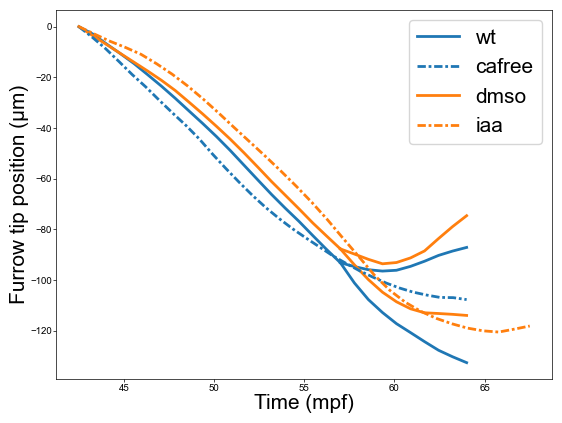

In [71]:
fig, ax = plt.subplots()
lw = 2
#wt
ax.plot(time_phase1_interp, if_cp_averaged_wo_r0[0], color='tab:blue', lw=lw, zorder=5, label='wt')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[2], color='tab:blue', lw=lw, zorder=5,)
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[4], color='tab:blue', lw=lw, zorder=5)

#cafree
ax.plot(time_phase1_interp_cafree, if_cp_averaged_cafree_wo_r0[0], color='tab:blue', lw=lw, ls=(0,(3,1,1,1)), zorder=10, label='cafree')

#dmso
ax.plot(time_phase1_interp, if_cp_averaged_wtdmso_wo_r0[0], color='tab:orange', lw=lw, zorder=5, label='dmso')
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[2], color='tab:orange', lw=lw, zorder=5)
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[4], color='tab:orange', lw=lw, zorder=5)

#iaa
ax.plot(time_phase1_interp_iaa, if_cp_averaged_iaa_wo_r0[0], color='tab:orange', lw=lw, ls=(0,(3,1,1,1)), zorder=10, label='iaa')
ax.set_xlabel('Time (mpf)', fontsize=15)
ax.set_ylabel('Furrow tip position (\u03BCm)', fontsize=15)
plt.legend(fontsize=15)
plt.show()

## h2/R0 of dmso vs iaa

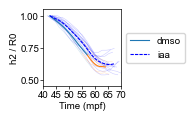

In [72]:
fig, ax = plt.subplots(figsize=[1,1])

for i in wtdmso_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wtdmso_info[i]['data'][:5]
    r_0 = wtdmso_info[i]['data'][11]

    lw, alpha = 0.4, 0.2
    ax.plot(time_phase1, if_displacement_phase1/r_0+1, color='tab:blue', lw=lw, zorder=3, alpha=alpha)
    ax.plot(time_phase2, if_displacement_phase2/r_0+1, color='tab:orange', lw=lw, zorder=3, alpha=alpha)

for i in iaa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = iaa_info[i]['data'][:5]
    r_0 = iaa_info[i]['data'][11]

    lw, alpha = 0.4, 0.2
    ax.plot(time_phase1, if_displacement_phase1/r_0+1, color='blue', lw=lw, zorder=3, alpha=alpha)

lw=0.8
#dmso
ax.plot(time_phase1_interp, if_cp_averaged_w_wtdmso_r0_2[0], color='tab:blue', lw=lw, zorder=5, label='dmso')
ax.plot(time_phase2_interp, if_cp_averaged_w_wtdmso_r0_2[2], color='tab:orange', lw=lw, zorder=5)
# ax.plot(time_phase2_interp, if_cp_averaged_w_wtdmso_r0_2[4], color='tab:green', lw=lw, zorder=5)

#iaa
ax.plot(time_phase1_interp_iaa, if_cp_averaged_iaa_w_r0_2[0], color='blue', lw=lw, ls=(0,(3,1)), zorder=10, label='iaa')

ax.set_xlim(40, 70)
ax.set_xticks(np.arange(40, 75, 5)) 
ax.set_ylim(0.45, 1.05)

ax.set_xlabel('Time (mpf)')
ax.set_ylabel('h2 / R0')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('iaa_dmso_furrow_position_2.svg')
plt.show()

## absolute ingression of dmso vs iaa

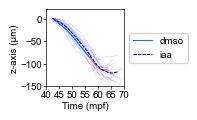

In [73]:
fig, ax = plt.subplots(figsize=[1,1])

for i in wtdmso_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wtdmso_info[i]['data'][:5]
    r_0 = wtdmso_info[i]['data'][11]

    lw, alpha = 0.4, 0.2
    ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=3, alpha=alpha)
    ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=3, alpha=alpha)

for i in iaa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = iaa_info[i]['data'][:5]
    r_0 = iaa_info[i]['data'][11]

    lw, alpha = 0.4, 0.2
    ax.plot(time_phase1, if_displacement_phase1, color='blue', lw=lw, zorder=3, alpha=alpha)

lw=0.8
#dmso
ax.plot(time_phase1_interp, if_cp_averaged_wtdmso_wo_r0[0], color='tab:blue', lw=lw, zorder=5, label='dmso')
ax.plot(time_phase2_interp, if_cp_averaged_wtdmso_wo_r0[2], color='tab:orange', lw=lw, zorder=5)
# ax.plot(time_phase2_interp, if_cp_averaged_w_wtdmso_r0_2[4], color='tab:green', lw=lw, zorder=5)

#iaa
ax.plot(time_phase1_interp_iaa, if_cp_averaged_iaa_wo_r0[0], color='blue', lw=lw, ls=(0,(3,1)), zorder=10, label='iaa')

ax.set_xlim(40, 70)
ax.set_xticks(np.arange(40, 75, 5))

ax.set_ylim(-150, 20)
ax.set_yticks(np.arange(0, -151, -50)) 

ax.set_xlabel('Time (mpf)')
ax.set_ylabel('z-axis (\u03BCm)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('iaa_dmso_furrow_position_1.svg')
plt.show()

## compare embryo radius

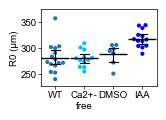

In [74]:
# compare radius
groupc = [wt_info[i]['data'][11] for i in wt_replicates_info.index]
groupd = [cafree_info[i]['data'][11] for i in cafree_replicates_info.index]
groupa = [wtdmso_info[i]['data'][11] for i in wtdmso_replicates_info.index]
groupb = [iaa_info[i]['data'][11] for i in iaa_replicates_info.index]

df = {'radius': groupc + groupd + groupa + groupb,
      'type': ['wt'] * len(wt_info) + ['cafree']* len(cafree_info) + ['dmso'] * len(wtdmso_info) + ['iaa'] * len(iaa_info)}
df = pd.DataFrame(df)

fig, ax = plt.subplots(figsize=[1.5,1])
sns.swarmplot(data=df, x='type', y='radius', 
              ax=ax, hue='type',
              legend=False, palette = ['tab:blue', 'deepskyblue', 'tab:blue', 'blue'],
              size=3, zorder=5)

sns.pointplot(data=df, x='type', y='radius',
             color='black', ax=ax, zorder=100,
             estimator='mean', errorbar=('ci', 95),
             linestyle='none', marker="_", markersize=20, markeredgewidth=1,
             capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylabel('R0 (\u03BCm)')
ax.set_xlabel('')
ax.set_xticklabels(['WT', 'Ca2+-\nfree', 'DMSO', 'IAA'])

ax.set_ylim(225, 375)
plt.savefig('wt_cafree_dmso_iaa_embryo_radius_1.svg')
plt.show()

In [75]:
from scipy import stats

groups = [df['radius'].dropna().values for _, df in df.groupby('type')]

# 1. Normality (Shapiro-Wilk on each group)
p_norms = [stats.shapiro(g).pvalue for g in groups]
normal = all(p > 0.05 for p in p_norms)
print(f"Shapiro p-values: {[f'{p:.3f}' for p in p_norms]} → {'normal' if normal else 'not normal'}")

# 2. Equal variance (Levene)
_, p_var = stats.levene(*groups)
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal and equal_var:
    stat, p = stats.f_oneway(*groups)
    test_name = "One-way ANOVA"
elif normal and not equal_var:
    stat, p = stats.alexandergovern(*groups)  # Welch-style ANOVA for unequal variances
    test_name = "Alexander-Govern (Welch ANOVA)"
else:
    stat, p = stats.kruskal(*groups)
    test_name = "Kruskal-Wallis"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.4f}")

Shapiro p-values: ['0.749', '0.156', '0.653', '0.098'] → normal
Levene p-value: 0.573 → equal variance

One-way ANOVA: stat=9.087, p=0.0001


In [76]:
from itertools import combinations

group_names = [name for name, _ in df.groupby('type')]

# Post-hoc pairwise tests
rows = []
print("Using:", "t-test" if normal else "Mann-Whitney U")

for (n1, g1), (n2, g2) in combinations(zip(group_names, groups), 2):
    if normal:
        stat, p = stats.ttest_ind(g1, g2, equal_var=equal_var)
        test = "Student's t-test" if equal_var else "Welch's t-test"
    else:
        stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        test = "Mann-Whitney"
    rows.append({'group1': n1, 'group2': n2, 'stat': stat, 'p': p, 'test':test})

posthoc = pd.DataFrame(rows)

# Multiple testing correction (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
reject, p_corrected, _, _ = multipletests(posthoc['p'], method='fdr_bh')
posthoc['p_corrected'] = np.round(p_corrected, 4)
posthoc['significant'] = reject

print(posthoc)

Using: t-test
   group1 group2      stat         p              test  p_corrected  \
0  cafree   dmso -0.974631  0.343409  Student's t-test       0.5151   
1  cafree    iaa -5.775468  0.000007  Student's t-test       0.0000   
2  cafree     wt -0.087293  0.931134  Student's t-test       0.9311   
3    dmso    iaa -3.537756  0.002351  Student's t-test       0.0047   
4    dmso     wt  0.619433  0.542624  Student's t-test       0.6511   
5     iaa     wt  4.165395  0.000303  Student's t-test       0.0009   

   significant  
0        False  
1         True  
2        False  
3         True  
4        False  
5         True  


# CARhoA

##### process the raw data

In [77]:
carhoa_replicates_info = data_info[data_info['furrow_indentation']=='carhoa'].reset_index()
display(carhoa_replicates_info)

,index,rep,experiment,replicate,embryo,type,Unnamed: 5,time_interval,pixel_size,voxel_depth,...,cortical_actin_intensity_quanti1,cortical_actin_intensity_quanti2,geometry,astral_mt_growth,real_i2,real_m2,real_time_interval,real_ck1,real_i3,real_m1
0,110,111,furrow_indentation_and_invagination,carhoa\XIN230823_LSM9001_dclk_utr_300pgcaRhoA,e1,beside,"one side affected, beside",47.29,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.482759,55,0.862069,41.206897,62.758621,30.0
1,111,112,furrow_indentation_and_invagination,carhoa\XIN230823_LSM9001_dclk_utr_300pgcaRhoA,e2,through,kinda through,47.33,1.2479,NaN,...,NaN,NaN,NaN,NaN,38.333333,55,0.925926,42.037037,64.259259,30.0
2,112,113,furrow_indentation_and_invagination,carhoa\XIN230823_LSM9001_dclk_utr_300pgcaRhoA,e3,beside,"one side affected, beside, far away",47.34,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,0.738095,42.452381,62.380952,NaN
3,113,114,furrow_indentation_and_invagination,carhoa\xin240418_lsm9001_egfp_300pgcarhoa,e1,no,not affecting too much at 1-cell stage,46.25,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,0.738095,43.190476,63.119048,NaN
4,114,115,furrow_indentation_and_invagination,carhoa\xin240418_lsm9001_egfp_300pgcarhoa,e2,all,universally increasing,46.57,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.259259,55,0.925926,42.962963,67.962963,30.0
5,115,116,furrow_indentation_and_invagination,carhoa\xin240418_lsm9001_egfp_300pgcarhoa,e3,through,"one side affected, through",46.23,1.2479,NaN,...,NaN,NaN,NaN,NaN,37.500000,55,0.833333,42.5,65.0,30.0
6,116,117,furrow_indentation_and_invagination,carhoa\xin240419_lsm9001_utregfp_carhoa300pg,e1,all,"looks like affected, but maybe universal",46.28,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,0.815789,42.763158,64.789474,NaN
7,117,118,furrow_indentation_and_invagination,carhoa\xin240419_lsm9001_utregfp_carhoa300pg,e2,beside,"one side affected, beside",46.52,1.2479,NaN,...,NaN,NaN,NaN,NaN,38.593750,55,0.78125,42.5,64.375,30.0
8,118,119,furrow_indentation_and_invagination,carhoa\xin240502_lsm9001_utregfp_carhoa300pg,e1,through,"one side affected, through",46.06,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,0.775,42.6,63.525,NaN
9,120,121,furrow_indentation_and_invagination,carhoa\xin240502_lsm9001_utregfp_carhoa300pg,e3,beside,"one side affected, beside",46.09,1.2479,NaN,...,NaN,NaN,NaN,NaN,39.500000,55,0.815789,42.763158,64.789474,NaN


rep 111


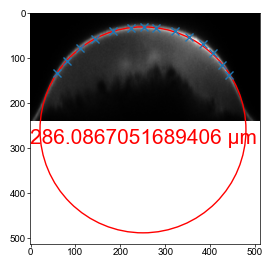

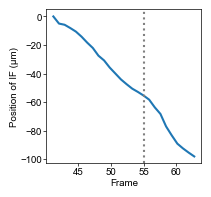

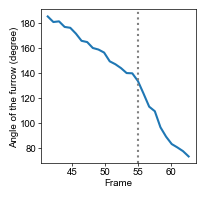

rep 112


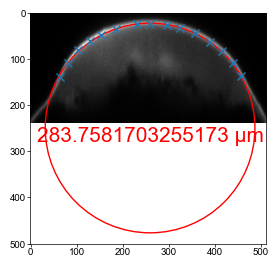

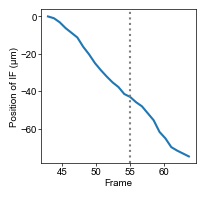

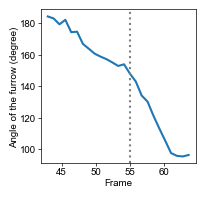

rep 113


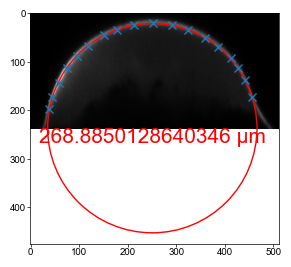

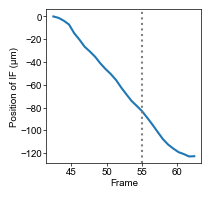

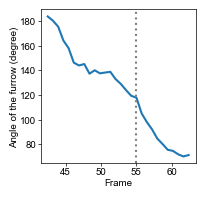

rep 114


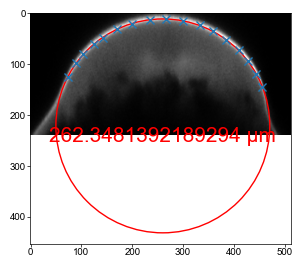

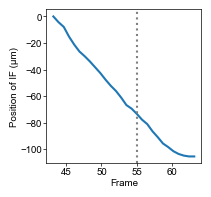

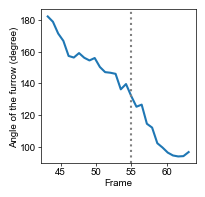

rep 115


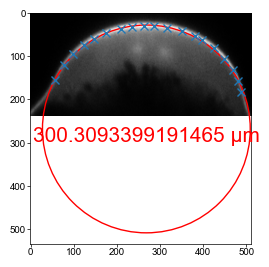

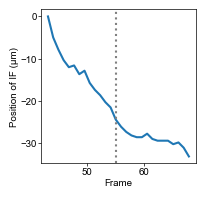

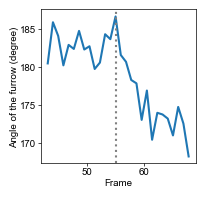

rep 116


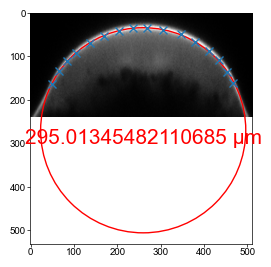

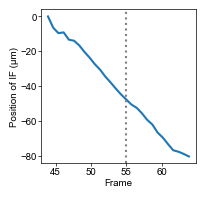

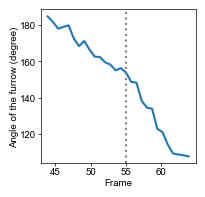

rep 117


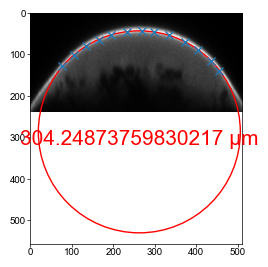

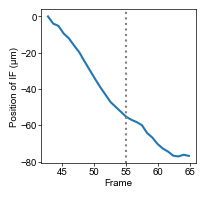

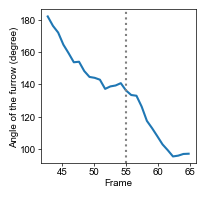

rep 118


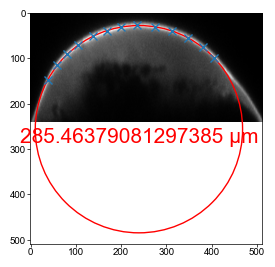

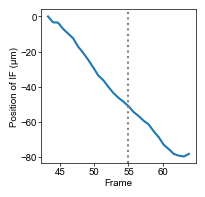

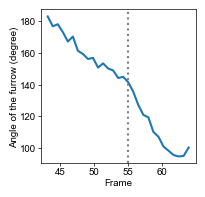

rep 119


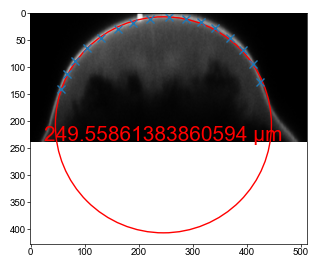

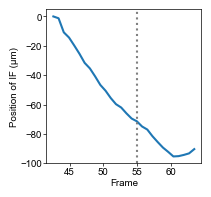

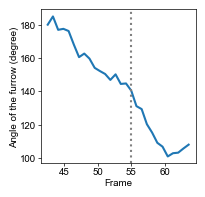

rep 121


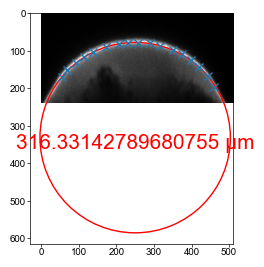

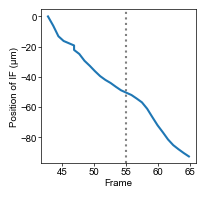

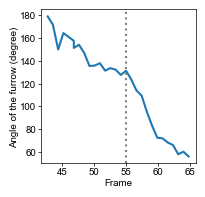

rep 122


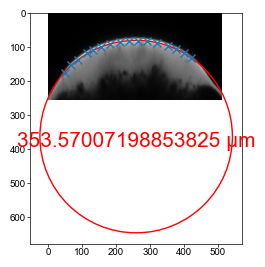

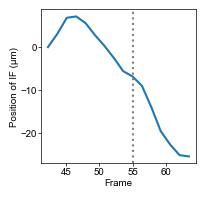

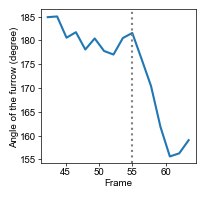

In [78]:
carhoa_info = []

for i in carhoa_replicates_info.index:

    replicate = carhoa_replicates_info.loc[i]
    print('rep', replicate.rep)

    # import the data
    replicate_file_name = replicate.replicate + '\\' + replicate.embryo + '\\furrowtip.csv'
    replicate_mt_cp = pd.read_csv(replicate_file_name)
    if 'Slice' in replicate_mt_cp.columns:
        replicate_mt_cp = replicate_mt_cp.rename({'Slice':'Frame'}, axis='columns')
    replicate_mt_cp = replicate_mt_cp[['X', 'Y', 'Frame']].sort_values(['Frame', 'Y']).reset_index().drop(columns='index')

    replicate_file_name_angle = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy_angle_measurement.csv'
    replicate_angle = pd.read_csv(replicate_file_name_angle)['0']

    # basic info
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    m1, i2, ck1, m2, septum1, i3 = replicate.m1, replicate.i2, replicate.ck1, replicate.m2, replicate.septum1, replicate.i3

    # r_0
    replicate_file_name_r0_fit_circle = replicate.replicate + '\\' + replicate.embryo + '\\r0_fit_circle.csv'
    replicate_r0_fit_circle = pd.read_csv(replicate_file_name_r0_fit_circle)[['X', 'Y']]
    circle_points = np.array(replicate_r0_fit_circle) / pixel_size
    fit_circle_xc, fit_circle_yc, fit_circle_r = fit_circle(circle_points)

    movie_sectionmidy = replicate.replicate + '\\' + replicate.embryo + '\\sectionmidy.tif'
    movie_sectionmidy = skimage.io.imread(movie_sectionmidy)
    if len(movie_sectionmidy.shape) == 4:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2, 1]
    elif len(movie_sectionmidy.shape) == 3:
        movie_frame_r0_fit_circle = movie_sectionmidy[ck1-2]

    fig,ax=plt.subplots(figsize=[4,3])
    ax.imshow(movie_frame_r0_fit_circle, cmap='Greys_r')
    ax.plot(circle_points[:,0], circle_points[:, 1], 'x')
    circle = mpl.patches.Circle(xy=(fit_circle_xc, fit_circle_yc), radius=fit_circle_r, fill=False, ec='red')
    ax.add_patch(circle)
    ax.text(fit_circle_xc, fit_circle_yc+30, str(fit_circle_r*pixel_size) + ' \u03BCm', color = 'red' , ha = 'center', fontsize=15)
    plt.show()
    r_0 = fit_circle_r*pixel_size

    # indentation and invagination
    if_position_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<500].Y.values)
    # if_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[1::2])
    # if_position_phase2 = np.insert(if_position_phase2, 0, if_position_phase1[-1])
    # cp_position_phase2 = np.array(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Y.values[0::2])
    # cp_position_phase2 = np.insert(cp_position_phase2, 0, if_position_phase1[-1])

    angle_phase1 = np.array(replicate_angle[:])
    # angle_phase2 = np.array(replicate_angle[septum1 - ck1-1:])

    frame_phase1 = np.array(replicate_mt_cp[replicate_mt_cp.Frame<500].Frame.values)
    # frame_phase2 = np.unique(replicate_mt_cp[replicate_mt_cp.Frame>=septum1].Frame.values)
    # frame_phase2 = np.insert(frame_phase2, 0, frame_phase1[-1])
    # frame_phase12 = np.arange(ck1, i3+1)

    time_phase1 = (frame_phase1 - m2)/(i2-m2)*(39.5-55) + 55
    # time_phase2 = (frame_phase2 - m2)/(m1-m2)*(30-55) + 55
    # time_phase12 = np.concatenate([time_phase1, time_phase2[1:]])

    # displacement
    if_displacement_phase1 = if_position_phase1[-1] - if_position_phase1[0]
    # if_displacement_phase2 = if_position_phase2[-1] - if_position_phase2[0]

    # # speed
    # if_speed_phase1 = speed_calculator(time_phase1, if_position_phase1)
    # if_speed_phase2 = speed_calculator(time_phase2, if_position_phase2)

    # export the data
    if_position_phase1_normalized = 0-(if_position_phase1 - if_position_phase1[0])
    # if_position_phase2_normalized = 0-(if_position_phase2 - if_position_phase1[0])
    # cp_position_phase2_normalized = 0-(cp_position_phase2 - if_position_phase1[0])

    replicate_info = {'name': replicate.rep,
                      'data': [if_position_phase1_normalized, _, _, # 0,1,2
                               time_phase1, _, # 3,4
                               if_displacement_phase1, _, # 5,6
                               _, _, # 7,8
                               angle_phase1, _, # 9,10
                               fit_circle_r*pixel_size # 11
                               ]} 
    
    carhoa_info.append(replicate_info)

    fig, ax = plt.subplots(figsize=[2,2])
    ax.plot(time_phase1, if_position_phase1_normalized)
    # ax.plot(time_phase2, if_position_phase2_normalized)
    # ax.plot(time_phase2, cp_position_phase2_normalized)
    ax.axvline(x = 55, color='grey', linestyle='dotted')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Position of IF (\u03BCm)')
    plt.show()

    fig, ax1 = plt.subplots(figsize=[2,2])
    ax1.plot(time_phase1, angle_phase1, color='tab:blue')
    # ax1.plot(time_phase2, angle_phase2, color='tab:orange')
    ax1.axvline(x = 55, color='grey', linestyle='dotted')
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Angle of the furrow (degree)')
    plt.show()


##### preview

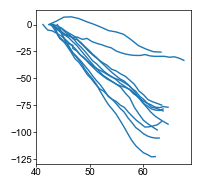

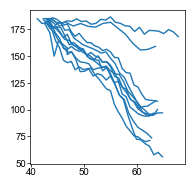

In [79]:
fig, ax = plt.subplots(figsize=[2,2])
for i in carhoa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = carhoa_info[i]['data'][:5]
   
    lw, alpha = 1,  1
    ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    # ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

fig, ax1 = plt.subplots(figsize=[2,2])
for i in carhoa_replicates_info.index:
    time_phase1, time_phase2 = carhoa_info[i]['data'][3:5]
    angle_phase1, angle_phase2 = carhoa_info[i]['data'][9:11]
   
    lw, alpha = 1,  1
    ax1.plot(time_phase1, angle_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax1.plot(time_phase2, angle_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
plt.show()

##### preview (together with r_0)

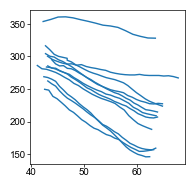

In [80]:
fig, ax = plt.subplots(figsize=[2,2])
for i in carhoa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = carhoa_info[i]['data'][:5]
    r_0 = carhoa_info[i]['data'][11]

    lw, alpha = 1,  1
    ax.plot(time_phase1, r_0+if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax.plot(time_phase2, r_0+if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    # ax.plot(time_phase2, r_0+cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)
plt.show()

##### average the carhoa indentation (raw, without r_0)

rep 111
rep 112
rep 113
rep 114
rep 115
rep 116
rep 117
rep 118
rep 119
rep 121
rep 122


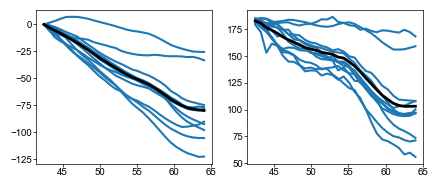

In [81]:
time_phase1_interp_carhoa = np.linspace(real_ck1, real_i3, 30)
# time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp = []
# if_displacement_phase2_interp = []
# cp_displacement_phase2_interp = []
angle_phase1_interp = []
# angle_phase2_interp = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in carhoa_replicates_info.index:
# for i in[0]:
    print('rep', carhoa_replicates_info.rep[i])

    # if interp
    if_displacement_phase1 = carhoa_info[i]['data'][0]
    if_displacement_phase1_newtime = np.linspace(42.5, 64, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp_carhoa, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp.append(if_displacement_phase1_new)

    # if_displacement_phase2 = wt_info[i]['data'][1]
    # if_displacement_phase2_newtime = np.linspace(57, 64, len(if_displacement_phase2))
    # if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    # if_displacement_phase2_interp.append(if_displacement_phase2_new)
    
    # cp_displacement_phase2 = wt_info[i]['data'][2]
    # cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    # cp_displacement_phase2_interp.append(cp_displacement_phase2_new)

    # angle interp
    angle_phase1 = carhoa_info[i]['data'][9]
    angle_phase1_newtime = np.linspace(42.5, 64, len(angle_phase1))
    angle_phase1_new = np.interp(x=time_phase1_interp_carhoa, xp=angle_phase1_newtime, fp=angle_phase1)
    angle_phase1_interp.append(angle_phase1_new)

    # angle_phase2 = wt_info[i]['data'][10]
    # angle_phase2_newtime = np.linspace(57, 64, len(angle_phase2))
    # angle_phase2_new = np.interp(x=time_phase2_interp, xp=angle_phase2_newtime, fp=angle_phase2)
    # angle_phase2_interp.append(angle_phase2_new)

    ax.plot(time_phase1_interp_carhoa, if_displacement_phase1_new, color='tab:blue')
    # ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    # ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')

    ax1.plot(time_phase1_interp_carhoa, angle_phase1_new, color='tab:blue')
    # ax1.plot(time_phase2_interp, angle_phase2_new, color='tab:orange')

if_displacement_phase1_interp = np.array(if_displacement_phase1_interp)
# if_displacement_phase2_interp = np.array(if_displacement_phase2_interp)
# cp_displacement_phase2_interp = np.array(cp_displacement_phase2_interp)

angle_phase1_interp = np.array(angle_phase1_interp)
# angle_phase2_interp = np.array(angle_phase2_interp)

if_cp_averaged_carhoa_wo_r0 = []
for list in [if_displacement_phase1_interp, angle_phase1_interp]:
    if_cp_averaged_carhoa_wo_r0.append(np.average(list, axis=0))
    if_cp_averaged_carhoa_wo_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp_carhoa, if_cp_averaged_carhoa_wo_r0[0], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[2], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[4], color='black', lw=2)

ax1.plot(time_phase1_interp_carhoa, if_cp_averaged_carhoa_wo_r0[2], color='black', lw=2)
# ax1.plot(time_phase2_interp, if_cp_averaged_wo_r0[8], color='black', lw=2)

plt.show()

##### average the carhoa indentation and invagination (with r_0, but not normalized with r_0)

rep 111
rep 112
rep 113
rep 114
rep 115
rep 116
rep 117
rep 118
rep 119
rep 121
rep 122


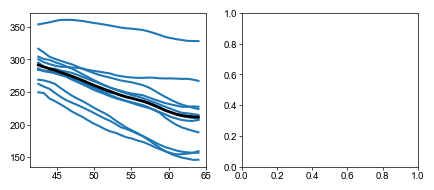

In [82]:
time_phase1_interp_carhoa = np.linspace(real_ck1, real_i3, 30)
# time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0 = []
# if_displacement_phase2_interp_wr0 = []
# cp_displacement_phase2_interp_wr0 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in carhoa_replicates_info.index:
# for i in[0]:
    print('rep', carhoa_replicates_info.rep[i])
    r_0 = carhoa_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = carhoa_info[i]['data'][0] + r_0
    if_displacement_phase1_newtime = np.linspace(42.5, 64, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp_carhoa, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0.append(if_displacement_phase1_new)

    # if_displacement_phase2 = wt_info[i]['data'][1] + r_0
    # if_displacement_phase2_newtime = np.linspace(57, 64, len(if_displacement_phase2))
    # if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    # if_displacement_phase2_interp_wr0.append(if_displacement_phase2_new)
    
    # cp_displacement_phase2 = wt_info[i]['data'][2] + r_0
    # cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    # cp_displacement_phase2_interp_wr0.append(cp_displacement_phase2_new)

    ax.plot(time_phase1_interp_carhoa, if_displacement_phase1_new, color='tab:blue')
    # ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    # ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0 = np.array(if_displacement_phase1_interp_wr0)
# if_displacement_phase2_interp_wr0 = np.array(if_displacement_phase2_interp_wr0)
# cp_displacement_phase2_interp_wr0 = np.array(cp_displacement_phase2_interp_wr0)


if_cp_averaged_carhoa_w_r0 = []
for list in [if_displacement_phase1_interp_wr0]:
    if_cp_averaged_carhoa_w_r0.append(np.average(list, axis=0))
    if_cp_averaged_carhoa_w_r0.append(np.std(list, axis=0))

ax.plot(time_phase1_interp_carhoa, if_cp_averaged_carhoa_w_r0[0], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0[2], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0[4], color='black', lw=2)

plt.show()

##### average the carhoa indentation and invagination (with r_0 and normalized with r_0)

rep 111
rep 112
rep 113
rep 114
rep 115
rep 116
rep 117
rep 118
rep 119
rep 121
rep 122


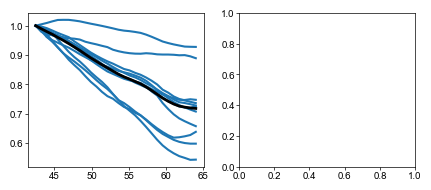

In [83]:
time_phase1_interp_carhoa = np.linspace(real_ck1, real_i3, 30)
# time_phase2_interp = np.linspace(real_septum1, real_i3, 10)

if_displacement_phase1_interp_wr0_2 = []
# if_displacement_phase2_interp_wr0_2 = []
# cp_displacement_phase2_interp_wr0_2 = []

fig, [ax, ax1] = plt.subplots(1,2,figsize=[5,2])

for i in carhoa_replicates_info.index:
# for i in[0]:
    print('rep', carhoa_replicates_info.rep[i])
    r_0 = carhoa_info[i]['data'][11]

    # if interp
    if_displacement_phase1 = carhoa_info[i]['data'][0] / r_0 +1
    if_displacement_phase1_newtime = np.linspace(42.5, 64, len(if_displacement_phase1))
    if_displacement_phase1_new = np.interp(x=time_phase1_interp_carhoa, xp=if_displacement_phase1_newtime, fp=if_displacement_phase1)
    if_displacement_phase1_interp_wr0_2.append(if_displacement_phase1_new)

    # if_displacement_phase2 = wt_info[i]['data'][1] / r_0 +1
    # if_displacement_phase2_newtime = np.linspace(57, 64, len(if_displacement_phase2))
    # if_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=if_displacement_phase2)
    # if_displacement_phase2_interp_wr0_2.append(if_displacement_phase2_new)
    
    # cp_displacement_phase2 = wt_info[i]['data'][2] / r_0 +1
    # cp_displacement_phase2_new = np.interp(x=time_phase2_interp, xp=if_displacement_phase2_newtime, fp=cp_displacement_phase2)
    # cp_displacement_phase2_interp_wr0_2.append(cp_displacement_phase2_new)


    ax.plot(time_phase1_interp_carhoa, if_displacement_phase1_new, color='tab:blue')
    # ax.plot(time_phase2_interp, if_displacement_phase2_new, color='tab:orange')
    # ax.plot(time_phase2_interp, cp_displacement_phase2_new, color='tab:green')


if_displacement_phase1_interp_wr0_2 = np.array(if_displacement_phase1_interp_wr0_2)
# if_displacement_phase2_interp_wr0_2 = np.array(if_displacement_phase2_interp_wr0_2)
# cp_displacement_phase2_interp_wr0_2 = np.array(cp_displacement_phase2_interp_wr0_2)


if_cp_averaged_carhoa_w_r0_2 = []
for list in [if_displacement_phase1_interp_wr0_2]:
    if_cp_averaged_carhoa_w_r0_2.append(np.average(list, axis=0))
    if_cp_averaged_carhoa_w_r0_2.append(np.std(list, axis=0))

ax.plot(time_phase1_interp_carhoa, if_cp_averaged_carhoa_w_r0_2[0], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[2], color='black', lw=2)
# ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[4], color='black', lw=2)


plt.show()

##### plot for the paper

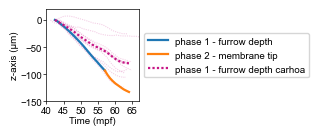

In [84]:
fig, ax = plt.subplots(figsize=[1.2, 1.2])

# plot each individual replicate
for i in wt_replicates_info.index:

    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = wt_info[i]['data'][:5]
    
    lw, alpha = 1,  0.2
    # ax.plot(time_phase1, if_displacement_phase1, color='tab:blue', lw=lw, zorder=-2, alpha=alpha)
    # ax.plot(time_phase2, if_displacement_phase2, color='tab:orange', lw=lw, zorder=-1, alpha=alpha)
    # ax.plot(time_phase2, cp_displacement_phase2, color='tab:green', lw=lw, zorder=0, alpha=alpha)

for i in carhoa_replicates_info.index:
    # print('rep', replicates_info.rep[i])

    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = carhoa_info[i]['data'][:5]
    
    lw, alpha = 0.8,  0.2
    ax.plot(time_phase1, if_displacement_phase1, color='mediumvioletred',lw=lw, ls=(0,(1,1)), zorder=-2, alpha=alpha)

# plot the averaged
lw=1.6
ax.plot(time_phase1_interp, if_cp_averaged_wo_r0[0], color='tab:blue', lw=lw, zorder=5, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[2], color='tab:orange', lw=lw, zorder=5, label='phase 2 - membrane tip')
# ax.plot(time_phase2_interp, if_cp_averaged[4], color='tab:green', lw=lw, zorder=2, label='phase 2 - contact point')
# ax.vlines(x=time_phase2_interp, ymin=if_cp_averaged[2], ymax=if_cp_averaged[4], color='tab:orange', lw=lw*0.3, zorder=1, label='phase 2 - contact point')

# plot the averaged carhoa
lw=1.6
ax.plot(time_phase1_interp_carhoa, if_cp_averaged_carhoa_wo_r0[0], color='mediumvioletred', lw=lw, ls=(0,(1,1)), zorder=10, label='phase 1 - furrow depth carhoa')

# ax.axvline(x = 55, color='r', linestyle='dotted')

# ax.invert_yaxis()
ax.set_ylim(-150, 20)
# ax.set_yticks(np.arange(0, 181, 30)) 
ax.set_xlim(40, 67)
ax.set_xticks(np.arange(40, 70, 5)) 
ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('z-axis (\u03BCm)', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('carhoa_furrow_position_1.svg')
plt.show()

##### export h1 h2

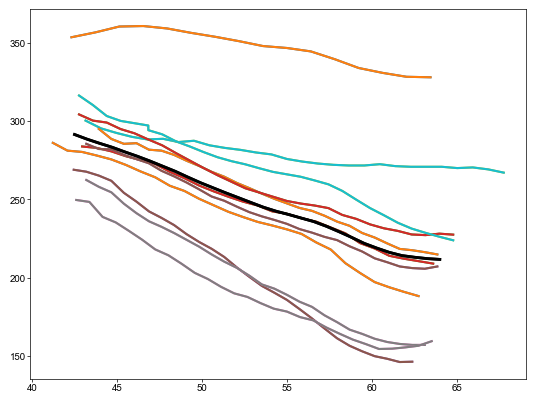

In [85]:
folder = 'furrow_position_carhoa_h1h2'
create_folder(folder)

# individual h1 and h2
for i in carhoa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = carhoa_info[i]['data'][:5]
    r_0 = carhoa_info[i]['data'][11]

    time_phase12 = time_phase1
    h_1 = if_displacement_phase1 + r_0
    h_2 = h_1
    np.save(folder + "\\" + "rep" + str(carhoa_info[i]['name']) + "_time_h1_h2.npy", [time_phase12, h_1, h_2])

    plt.plot(time_phase12, h_1)
    plt.plot(time_phase12, h_2)

# averaged h1 and h2
time_phase12 =  time_phase1_interp_carhoa
h_1 = if_cp_averaged_carhoa_w_r0[0]
h_2 = h_1
np.save(folder + "\\carhoa_avg_time_h1_h2.npy", [time_phase12, h_1, h_2])

plt.plot(time_phase12, h_1, color='black', lw=2)
plt.plot(time_phase12, h_2, color='black', lw=2)

##### plot for the paper (fig. 6F')

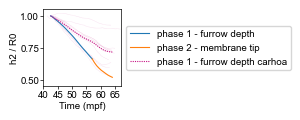

In [86]:
fig, ax = plt.subplots(figsize=[1, 1])

# plot each individual replicate
for i in carhoa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = carhoa_info[i]['data'][:5]
    r_0 = carhoa_info[i]['data'][11]

    time_phase12 = time_phase1
    h_1 = if_displacement_phase1 + r_0
    h_2 = h_1
    
    lw, alpha = 0.4,  0.2
    ax.plot(time_phase1, h_1/r_0, color='mediumvioletred',lw=lw, ls=(0,(1,1)), zorder=-2, alpha=alpha)

# plot the averaged
lw=.8
ax.plot(time_phase1_interp, if_cp_averaged_w_r0_2[0], color='tab:blue', lw=lw, zorder=5, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_w_r0_2[2], color='tab:orange', lw=lw, zorder=5, label='phase 2 - membrane tip')
ax.plot(time_phase1_interp_carhoa, if_cp_averaged_carhoa_w_r0_2[0], color='mediumvioletred', lw=lw, ls=(0,(1,1)), zorder=10, label='phase 1 - furrow depth carhoa')

ax.set_ylim(0.45, 1.05)
ax.set_xlim(40, 67)
ax.set_xticks(np.arange(40, 70, 5)) 
ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('h2 / R0', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('carhoa_furrow_position_2.svg')
plt.show()


In [87]:
from xint_toolbox import find_closest
# carhoa at 57mpf
group7 = [(carhoa_info[i]['data'][0][find_closest(array=carhoa_info[i]['data'][3], target=57)[1]]/carhoa_info[i]['data'][11]+1) for i in carhoa_replicates_info.index]
#wt phase 1 only
group6 = np.array([wt_info[i]['data'][0][-1]/wt_info[i]['data'][11]+1 for i in wt_replicates_info.index])


testgroup1, testgroup2 = group7, group6
print('--Shapiro-Wilk test for normality--')
stat, p = scipy.stats.shapiro(testgroup1)
print("Control: W=%.3f, p=%.3f" % (stat, p))
stat, p = scipy.stats.shapiro(testgroup2)
print("Control: W=%.3f, p=%.3f" % (stat, p))
# Levene’s test (center='median' is more robust to non-normal data)
stat, p_val = scipy.stats.levene(testgroup1, testgroup2, center='mean')
print('--Levene’s test for variance equity--')
print("Levene’s test statistic =", stat)
print("p-value =", p_val)
# Mann–Whitney U test (two-sided)
u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
print('--Mann-Whitney U test (two-sided)--')
print("Mann–Whitney U statistic =", u_stat)
print("p-value =", p_val)
print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.3f}.")
print(" ")

--Shapiro-Wilk test for normality--
Control: W=0.949, p=0.626
Control: W=0.939, p=0.365
--Levene’s test for variance equity--
Levene’s test statistic = 2.8866031971905595
p-value = 0.10224724635719692
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 143.0
p-value = 0.0018457213176962682
Statistical test, Mann-Whitney test: p = 0.002.
 


In [88]:
from xint_toolbox import find_closest
# carhoa ends
group7 = [(carhoa_info[i]['data'][0][-1]/carhoa_info[i]['data'][11]+1) for i in carhoa_replicates_info.index]
# wt phase 2 ends
group6 = np.array([wt_info[i]['data'][1][-1]/wt_info[i]['data'][11]+1 for i in wt_replicates_info.index])

testgroup1, testgroup2 = group7, group6
print('--Shapiro-Wilk test for normality--')
stat, p = scipy.stats.shapiro(testgroup1)
print("Control: W=%.3f, p=%.3f" % (stat, p))
stat, p = scipy.stats.shapiro(testgroup2)
print("Control: W=%.3f, p=%.3f" % (stat, p))
# Levene’s test (center='median' is more robust to non-normal data)
stat, p_val = scipy.stats.levene(testgroup1, testgroup2, center='mean')
print('--Levene’s test for variance equity--')
print("Levene’s test statistic =", stat)
print("p-value =", p_val)
# Mann–Whitney U test (two-sided)
u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
print('--Mann-Whitney U test (two-sided)--')
print("Mann–Whitney U statistic =", u_stat)
print("p-value =", p_val)
print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.3f}.")
print(" ")

--Shapiro-Wilk test for normality--
Control: W=0.940, p=0.521
Control: W=0.960, p=0.689
--Levene’s test for variance equity--
Levene’s test statistic = 0.017281731778439738
p-value = 0.8965072501785801
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 153.0
p-value = 0.0002801503699595396
Statistical test, Mann-Whitney test: ***p < 0.001.
 


In [89]:
# export for excel fig. 6G'
dfs = []

list1 = time_phase1_interp_carhoa
list2 = if_cp_averaged_carhoa_w_r0_2[0]
list3 = ['magenta']* len(time_phase1_interp_carhoa)
list4 = ['Mean'] * len(list3)
list5 = ['CARhoA'] * len(list3)

df = pd.DataFrame({'Type':list5, 'Replicate #': list4, 'Time (mpf)': list1, 'h2 / R0': list2, 'Color illustration (as in the schematics)':list3})
dfs.append(df)

for i in carhoa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = cafree_info[i]['data'][:5]
    r_0 = carhoa_info[i]['data'][11]

    time_phase12 = time_phase1
    h_1 = if_displacement_phase1 + r_0
    h_2 = h_1

    list1 = time_phase12
    list2 = h_1/r_0
    list3 = ['magenta']* len(time_phase12)
    list4 = [carhoa_info[i]['name']] * len(list3)
    list5 = ['CARhoA'] * len(list3)

    df = pd.DataFrame({'Type':list5, 'Replicate #': list4, 'Time (mpf)': list1, 'h2 / R0': list2, 'Color illustration (as in the schematics)':list3})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all
df_all.to_excel('wt_furrow_position_1_excel_fig6gprime.xlsx', index=False)

##### plot for the paper (fig. S6A)

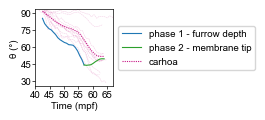

In [90]:
fig, ax = plt.subplots(figsize=[1, 1])

# plot each individual replicate
for i in carhoa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = carhoa_info[i]['data'][:5]
    angle_phase1, angle_phase2 = carhoa_info[i]['data'][9:11]

    lw, alpha = .4,  0.2
    ax.plot(time_phase1, angle_phase1/2, color='mediumvioletred', lw=lw, ls=(0,(3,1)), zorder=-1, alpha=alpha)

# plot the averaged
lw=.8
ax.plot(time_phase1_interp, if_cp_averaged_wo_r0[6]/2, color='tab:blue', lw=lw, zorder=1, label='phase 1 - furrow depth')
ax.plot(time_phase2_interp, if_cp_averaged_wo_r0[8]/2, color='tab:green', lw=lw, zorder=1, label='phase 2 - membrane tip')
ax.plot(time_phase1_interp_carhoa, if_cp_averaged_carhoa_wo_r0[2]/2, color='mediumvioletred', ls=(0,(1,1)),lw=lw, zorder=1, label='carhoa')

ax.set_ylim(25, 93)
ax.set_yticks(np.arange(30, 91, 15)) 
ax.set_xlim(40, 67)
ax.set_xticks(np.arange(40, 70, 5)) 
ax.set_xlabel('Time (mpf)', fontsize=7)
ax.set_ylabel('θ (°)', fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('carhoa_furrow_angle.svg')
plt.show()

In [91]:
# export for excel
dfs = []

list1 = time_phase1_interp_carhoa
list2 = if_cp_averaged_carhoa_wo_r0[2]/2
list3 = ['magenta'] * len(time_phase1_interp_carhoa)
list4 = ['Mean'] * len(list3)

df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'Angle (degree)': list2, 'Color illustration (as in the schematics)':list3})
dfs.append(df)

for i in carhoa_replicates_info.index:
    if_displacement_phase1, if_displacement_phase2, cp_displacement_phase2, time_phase1, time_phase2 = carhoa_info[i]['data'][:5]
    angle_phase1, angle_phase2 = carhoa_info[i]['data'][9:11]

    list1 = time_phase1
    list2 = angle_phase1/2
    list3 = ['magenta'] * len(time_phase1)
    list4 = [carhoa_info[i]['name']] * len(list3)

    df = pd.DataFrame({'Replicate #': list4, 'Time (mpf)': list1, 'Angle (degree)': list2, 'Color illustration (as in the schematics)':list3})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all
df_all.to_excel('carhoa_furrow_angle_excel_figs7c.xlsx', index=False)
df_all

,Replicate #,Time (mpf),Angle (degree),Color illustration (as in the schematics)
0,Mean,42.500000,91.317768,magenta
1,Mean,43.241379,90.295921,magenta
2,Mean,43.982759,88.141613,magenta
3,Mean,44.724138,87.001604,magenta
4,Mean,45.465517,85.567784,magenta
...,...,...,...,...
317,122,57.818182,85.183937,magenta
318,122,59.227273,80.910030,magenta
319,122,60.636364,77.799723,magenta
320,122,62.045455,78.125855,magenta


In [92]:
df1 = pd.read_excel('wt_furrow_angle_excel_figs7c.xlsx')
df1['Type'] = ['wt'] * len(df1)
df2 = pd.read_excel('cafree_furrow_angle_excel_figs7c.xlsx')
df2['Type'] = ['Ca2+-free'] * len(df2)
df3 = pd.read_excel('carhoa_furrow_angle_excel_figs7c.xlsx')
df3['Type'] = ['CARhoA'] * len(df3)


df_to_export = pd.concat([df1, df2, df3])
df_to_export.to_excel('wt_cafree_carhoa_furrow_angle_excel_figs7c.xlsx', index=False)
df_to_export

,Replicate #,Time (mpf),Angle (degree),Color illustration (as in the schematics),Type
0,Mean,42.500000,85.146862,blue,wt
1,Mean,43.263158,80.474220,blue,wt
2,Mean,44.026316,77.981815,blue,wt
3,Mean,44.789474,75.946927,blue,wt
4,Mean,45.552632,74.942857,blue,wt
...,...,...,...,...,...
317,122,57.818182,85.183937,magenta,CARhoA
318,122,59.227273,80.910030,magenta,CARhoA
319,122,60.636364,77.799723,magenta,CARhoA
320,122,62.045455,78.125855,magenta,CARhoA


# Compare the furrow indentation among WT, Calcium-free, CARhoA

##### plot for the paper - compare the original displacement

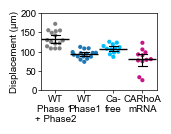

In [93]:
displacements_wt = np.array([np.sum(wt_info[i]['data'][5:7]) for i in wt_replicates_info.index])
displacements_wtphase1 = np.array([wt_info[i]['data'][5] for i in wt_replicates_info.index])
displacements_cafree = np.array([cafree_info[i]['data'][5] for i in cafree_replicates_info.index])
displacements_carhoa = np.array([carhoa_info[i]['data'][5] for i in carhoa_replicates_info.index])

df = {'displacements': np.concatenate([displacements_wt,
                                       displacements_wtphase1,
                                       displacements_cafree,
                                       displacements_carhoa]), 
      'type': np.concatenate([['wt_total'] * len(displacements_wt),
                              ['wt_phase1'] * len(displacements_wtphase1),
                              ['cafree'] * len(displacements_cafree),
                              ['carhoa'] * len(displacements_carhoa)])}
df = pd.DataFrame(df)

fig,ax = plt.subplots(figsize=[1.5, 1])
sns.swarmplot(df, x='type', y= 'displacements',
              ax=ax, hue='type',
              legend=False, palette = ['grey', 'tab:blue', 'deepskyblue' , 'mediumvioletred'],
              size=3, zorder=5)
sns.pointplot(df, x='type', y= 'displacements',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})

ax.set_xticks(range(4))
# ax.set_xlim(-0.5, 2.5)
ax.set_xticklabels(['WT\nPhase 1\n+ Phase2', 'WT\nPhase1', 'Ca-\nfree', 'CARhoA\nmRNA'])
ax.set_ylim(0, 200)
ax.set_yticks(np.arange(0, 201, 50)) 

ax.set_xlabel('', fontsize=7)
ax.set_ylabel('Displacement (\u03bcm)', fontsize=7)
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)
plt.savefig('furrow_indentation_wt_cafree_carhoa_1.svg')
plt.show()


##### plot for the paper (fig. S6B) - compare the displacement normalized by r_0

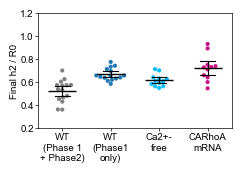

In [94]:
finalh1r0_wt = np.array([wt_info[i]['data'][1][-1]/wt_info[i]['data'][11]+1 for i in wt_replicates_info.index])
finalh1r0_wtphase1 = np.array([wt_info[i]['data'][0][-1]/wt_info[i]['data'][11]+1 for i in wt_replicates_info.index])
finalh1r0_cafree = np.array([cafree_info[i]['data'][0][-1]/cafree_info[i]['data'][11]+1 for i in cafree_replicates_info.index])
finalh1r0_carhoa = np.array([carhoa_info[i]['data'][0][-1]/carhoa_info[i]['data'][11]+1 for i in carhoa_replicates_info.index])

df = {'displacements': np.concatenate([finalh1r0_wt,
                                       finalh1r0_wtphase1,
                                       finalh1r0_cafree,
                                       finalh1r0_carhoa]),
        'type': np.concatenate([['wt_total'] * len(finalh1r0_wt),
                              ['wt_phase1'] * len(finalh1r0_wtphase1),
                              ['cafree'] * len(finalh1r0_cafree),
                              ['carhoa'] * len(finalh1r0_carhoa)]),
        'embryo': np.concatenate([[wt_info[i]['name'] for i in wt_replicates_info.index],
                                  [wt_info[i]['name'] for i in wt_replicates_info.index],
                                  [cafree_info[i]['name'] for i in cafree_replicates_info.index],
                                  [carhoa_info[i]['name'] for i in carhoa_replicates_info.index]])}
df = pd.DataFrame(df)

fig,ax = plt.subplots(figsize=[2.5, 1.5])
sns.swarmplot(df, x='type', y= 'displacements',
              ax=ax, hue='type',
              legend=False, palette = ['grey', 'tab:blue', 'deepskyblue' , 'mediumvioletred'],
              size=3, zorder=5)
sns.pointplot(df, x='type', y= 'displacements',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})

ax.set_xticks(range(4))
# ax.set_xlim(-0.5, 2.5)
ax.set_xticklabels(['WT\n(Phase 1\n+ Phase2)', 'WT\n(Phase1\nonly)', 'Ca2+-\nfree', 'CARhoA\nmRNA'])
ax.set_ylim(0.2, 1.2)
ax.set_yticks(np.arange(0.2, 1.3, 0.2)) 

ax.set_xlabel('', fontsize=7)
ax.set_ylabel('Final h2 / R0', fontsize=7)
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)
plt.savefig('furrow_indentation_wt_cafree_carhoa_2.svg')
plt.show()

In [95]:
# statistics
group1 = df.loc[df['type'] == 'wt_total'].displacements
group2 = df.loc[df['type'] == 'wt_phase1'].displacements
delta_group1group2 = np.array(group1) - np.array(group2)
group3 = df.loc[df['type'] == 'cafree'].displacements
group4 = df.loc[df['type'] == 'carhoa'].displacements

print('--Shapiro-Wilk test for normality--')
for group in [group1, group2, group3, group4]:
    stat_group1, p_group1 = scipy.stats.shapiro(group)
    print("Control: W=%.4f, p=%.4f" % (stat_group1, p_group1))
print(" ")

# Levene’s test (center='median' is more robust to non-normal data)
stat, p_val = scipy.stats.levene(group1, group3, center='mean')
print('--Levene’s test for variance equity--')
print("Levene’s test statistic =", stat)
print("p-value =", p_val)
# Mann–Whitney U test (two-sided)
u_stat, p_val13 = scipy.stats.mannwhitneyu(group1, group3, alternative='two-sided')
print('--Mann-Whitney U test (two-sided)--')
print("Mann–Whitney U statistic =", u_stat)
print("p-value =", p_val13)
print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val13<0.001 else f"p = {p_val13:.4f}.")
print(" ")

# Levene’s test (center='median' is more robust to non-normal data)
stat, p_val = scipy.stats.levene(group2, group3, center='mean')
print('--Levene’s test for variance equity--')
print("Levene’s test statistic =", stat)
print("p-value =", p_val)
# Mann–Whitney U test (two-sided)
u_stat, p_val23 = scipy.stats.mannwhitneyu(group2, group3, alternative='two-sided')
print('--Mann-Whitney U test (two-sided)--')
print("Mann–Whitney U statistic =", u_stat)
print("p-value =", p_val23)
print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val23<0.001 else f"p = {p_val23:.4f}.")
print(" ")

# Levene’s test (center='median' is more robust to non-normal data)
stat, p_val = scipy.stats.levene(group1, group4, center='mean')
print('--Levene’s test for variance equity--')
print("Levene’s test statistic =", stat)
print("p-value =", p_val)
# Mann–Whitney U test (two-sided)
u_stat, p_val14 = scipy.stats.mannwhitneyu(group1, group4, alternative='two-sided')
print('--Mann-Whitney U test (two-sided)--')
print("Mann–Whitney U statistic =", u_stat)
print("p-value =", p_val14)
print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val14<0.001 else f"p = {p_val14:.4f}.")
print(" ")

--Shapiro-Wilk test for normality--
Control: W=0.9598, p=0.6888
Control: W=0.9386, p=0.3654
Control: W=0.9238, p=0.3194
Control: W=0.9400, p=0.5207
 
--Levene’s test for variance equity--
Levene’s test statistic = 4.9861914283515825
p-value = 0.03474014826742584
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 34.0
p-value = 0.006766500035059635
Statistical test, Mann-Whitney test: p = 0.0068.
 
--Levene’s test for variance equity--
Levene’s test statistic = 0.12020615881339947
p-value = 0.7317123889273565
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 142.0
p-value = 0.011972878389045894
Statistical test, Mann-Whitney test: p = 0.0120.
 
--Levene’s test for variance equity--
Levene’s test statistic = 0.017281731778439738
p-value = 0.8965072501785801
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 12.0
p-value = 0.0002801503699595396
Statistical test, Mann-Whitney test: ***p < 0.001.
 


In [96]:
stat_group1, p_group1 = scipy.stats.shapiro(delta_group1group2)
print("Control: W=%.4f, p=%.4f" % (stat_group1, p_group1))

# If differences normal
stat, p_val12 = scipy.stats.ttest_rel(group1, group2)
print("Paired t-test:", stat, p_val12)

Control: W=0.9492, p=0.5116
Paired t-test: -7.351236874409642 3.6129955878092995e-06


In [97]:
# Your raw p-values
raw_pvals = np.array([p_val13, p_val23, p_val14, p_val12])
print("Raw:", np.round(raw_pvals,4))

from statsmodels.stats.multitest import multipletests

# Bonferroni
rej_bonf, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method='bonferroni')
print("Bonferroni corrected:", np.round(pvals_bonf,4))

# Holm–Bonferroni
rej_holm, pvals_holm, _, _ = multipletests(raw_pvals, alpha=0.05, method='holm')
print("Holm corrected:", np.round(pvals_holm,4))

# Benjamini–Hochberg (FDR)
rej_fdr, pvals_fdr, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')
print("Benjamini–Hochberg corrected:", np.round(pvals_fdr,4))

Raw: [0.0068 0.012  0.0003 0.    ]
Bonferroni corrected: [0.0271 0.0479 0.0011 0.    ]
Holm corrected: [0.0135 0.0135 0.0008 0.    ]
Benjamini–Hochberg corrected: [0.009  0.012  0.0006 0.    ]


In [98]:
df_to_export = df.copy()
df_to_export.replace('wt_total', 'WT (Phase 1 + Phase 2)', inplace=True)
df_to_export.replace('wt_phase1', 'WT (Phase 1 only)', inplace=True)
df_to_export.replace('cafree', 'Ca2+-free', inplace=True)
df_to_export.replace('carhoa', 'CARhoA', inplace=True)
df_to_export.columns = ['Final h2 / R0', 'Type', 'Embryo #']
df_to_export.to_excel('furrow_indentation_wt_cafree_carhoa_2_excel_figs7d.xlsx', index=False)
df_to_export

,Final h2 / R0,Type,Embryo #
0,0.623567,WT (Phase 1 + Phase 2),1
1,0.567173,WT (Phase 1 + Phase 2),2
2,0.359625,WT (Phase 1 + Phase 2),3
3,0.698201,WT (Phase 1 + Phase 2),4
4,0.478688,WT (Phase 1 + Phase 2),5
5,0.428535,WT (Phase 1 + Phase 2),6
6,0.572811,WT (Phase 1 + Phase 2),7
7,0.360838,WT (Phase 1 + Phase 2),8
8,0.530352,WT (Phase 1 + Phase 2),9
9,0.571764,WT (Phase 1 + Phase 2),11


MannwhitneyuResult(statistic=np.float64(66.0), pvalue=np.float64(0.1532844720368013))

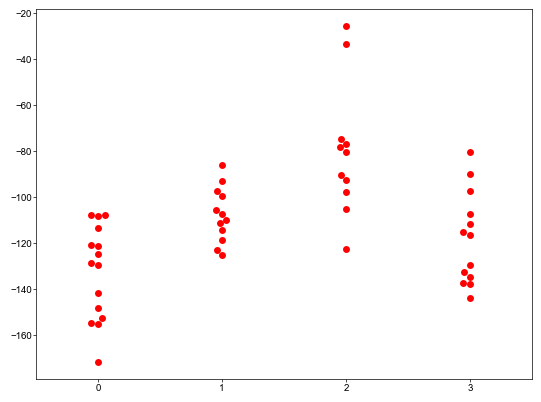

In [99]:
wt_55mpf = [wt_info[i]['data'][0][find_closest(wt_info[i]['data'][3], 55)[1]] for i in wt_replicates_info.index]
cafree_55mpf = [cafree_info[i]['data'][0][find_closest(cafree_info[i]['data'][3], 55)[1]] for i in cafree_replicates_info.index]
carhoa_55mpf = [carhoa_info[i]['data'][0][find_closest(carhoa_info[i]['data'][3], 55)[1]] for i in carhoa_replicates_info.index]
iaa_55mpf = [iaa_info[i]['data'][0][find_closest(iaa_info[i]['data'][3], 55)[1]] for i in iaa_replicates_info.index]

wt_final = [wt_info[i]['data'][1][-1] for i in wt_replicates_info.index]
cafree_final = [cafree_info[i]['data'][0][-1] for i in cafree_replicates_info.index]
carhoa_final = [carhoa_info[i]['data'][0][-1] for i in carhoa_replicates_info.index]
iaa_final = [iaa_info[i]['data'][0][-1] for i in iaa_replicates_info.index]

# wt_delta = np.array(wt_55mpf) - np.array(wt_final)
# iaa_delta = np.array(iaa_55mpf) - np.array(iaa_final)


# sns.swarmplot([wt_55mpf, cafree_55mpf, carhoa_55mpf, iaa_55mpf], color='blue')
sns.swarmplot([wt_final, cafree_final, carhoa_final, iaa_final], color='red')

# sns.swarmplot([wt_delta, iaa_delta], color='red')

scipy.stats.mannwhitneyu(wt_final, iaa_final)

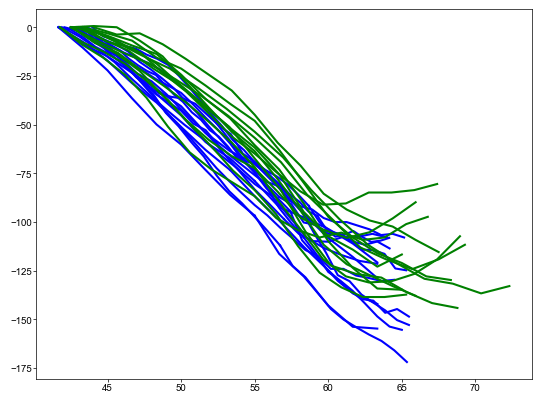

In [100]:
for i in wt_replicates_info.index:
    plt.plot(wt_info[i]['data'][3], wt_info[i]['data'][0], color='blue')
    plt.plot(wt_info[i]['data'][4], wt_info[i]['data'][1], color='blue')

# for i in cafree_replicates_info.index:
#     plt.plot(cafree_info[i]['data'][3], cafree_info[i]['data'][0], color='red')

# for i in carhoa_replicates_info.index:
#     plt.plot(carhoa_info[i]['data'][3], carhoa_info[i]['data'][0], color='orange')

for i in iaa_replicates_info.index:
    plt.plot(iaa_info[i]['data'][3], iaa_info[i]['data'][0], color='green')

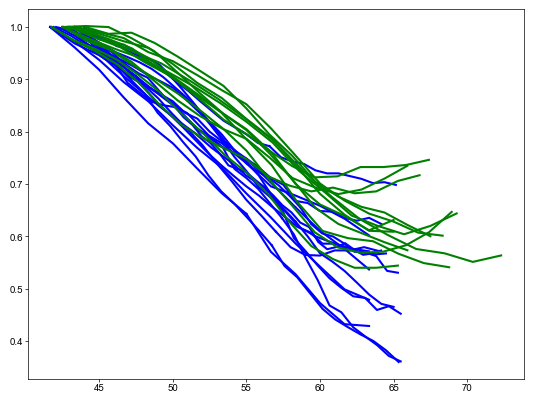

In [101]:
for i in wt_replicates_info.index:
    plt.plot(wt_info[i]['data'][3], wt_info[i]['data'][0]/wt_info[i]['data'][11]+1, color='blue')
    plt.plot(wt_info[i]['data'][4], wt_info[i]['data'][1]/wt_info[i]['data'][11]+1, color='blue')

# for i in cafree_replicates_info.index:
#     plt.plot(cafree_info[i]['data'][3], cafree_info[i]['data'][0], color='red')

# for i in carhoa_replicates_info.index:
#     plt.plot(carhoa_info[i]['data'][3], carhoa_info[i]['data'][0], color='orange')

for i in iaa_replicates_info.index:
    plt.plot(iaa_info[i]['data'][3], iaa_info[i]['data'][0]/iaa_info[i]['data'][11]+1, color='green')

<Axes: >

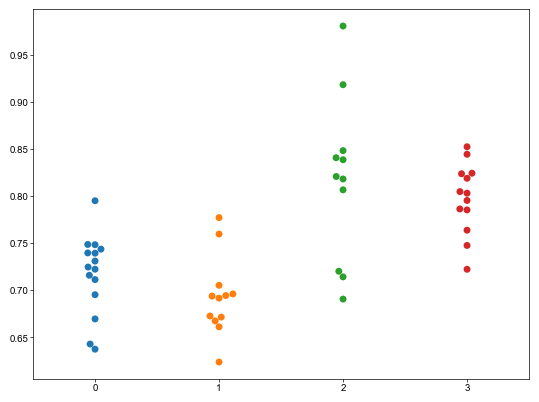

In [102]:
wt_55mpf = [wt_info[i]['data'][0][find_closest(wt_info[i]['data'][3], 55)[1]]/wt_info[i]['data'][11]+1 for i in wt_replicates_info.index]
cafree_55mpf = [cafree_info[i]['data'][0][find_closest(cafree_info[i]['data'][3], 55)[1]]/cafree_info[i]['data'][11]+1 for i in cafree_replicates_info.index]
carhoa_55mpf = [carhoa_info[i]['data'][0][find_closest(carhoa_info[i]['data'][3], 55)[1]]/carhoa_info[i]['data'][11]+1 for i in carhoa_replicates_info.index]
iaa_55mpf = [iaa_info[i]['data'][0][find_closest(iaa_info[i]['data'][3], 55)[1]]/iaa_info[i]['data'][11]+1 for i in iaa_replicates_info.index]



sns.swarmplot([wt_55mpf, cafree_55mpf, carhoa_55mpf, iaa_55mpf])

# Compare with physical modelling

##### plot for the paper (fig. 6H)

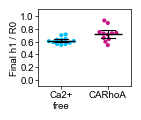

In [103]:
h1_r0_wt = np.array([wt_info[i]['data'][1][-1]/wt_info[i]['data'][11]+1 for i in wt_replicates_info.index])
h1_r0_wtphase1 = np.array([wt_info[i]['data'][0][-1]/wt_info[i]['data'][11]+1 for i in wt_replicates_info.index])
h1_r0_cafree = np.array([cafree_info[i]['data'][0][-1]/cafree_info[i]['data'][11]+1 for i in cafree_replicates_info.index])
h1_r0_carhoa = np.array([carhoa_info[i]['data'][0][-1]/carhoa_info[i]['data'][11]+1 for i in carhoa_replicates_info.index])

df = {'h_r0': np.concatenate([h1_r0_wt,
                              h1_r0_wtphase1,
                              h1_r0_cafree,
                              h1_r0_carhoa]), 
      'type': np.concatenate([['wt_total'] * len(h1_r0_wt),
                              ['wt_phase1'] * len(h1_r0_wtphase1),
                              ['cafree'] * len(h1_r0_cafree),
                              ['carhoa'] * len(h1_r0_carhoa)])}
df = pd.DataFrame(df)

fig,ax = plt.subplots(figsize=[1.2, 1])
sns.swarmplot(df.loc[df['type'].isin(['cafree', 'carhoa'])], x='type', y= 'h_r0',
              ax=ax, hue='type',
              legend=False, palette = ['deepskyblue' , 'mediumvioletred'],
              size=3, zorder=5)
sns.pointplot(df.loc[df['type'].isin(['cafree', 'carhoa'])], x='type', y= 'h_r0',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})

ax.set_xticks(range(2))
ax.set_xticklabels(['Ca2+\nfree', 'CARhoA'])
ax.set_ylim(-0.1, 1.1)
ax.set_yticks(np.arange(0, 1.1, 0.2)) 

ax.set_xlabel('', fontsize=7)
ax.set_ylabel('Final h1 / R0', fontsize=7)
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)
plt.savefig('compare cafree_and_carhoa_with_modelling_1.svg')
plt.show()

In [104]:
df_to_export = df.loc[df['type'].isin(['cafree', 'carhoa'])].copy()
df_to_export.columns = ['Phase 1 final h1 / R0', 'Type']
df_to_export.replace('cafree', 'Ca2+-free', inplace=True)
df_to_export.replace('carhoa', 'CARhoA', inplace=True)
df_to_export.to_excel('compare cafree_and_carhoa_with_modelling_1_excel_fig6h.xlsx', index=False)